# 红利低波风格池构建指南

本文定义“红利低波”时点风格股票池的构建方法。目标是生成一个无前视偏差的动态股票池，用于后续规则选股、因子验证或 ML 风格增强训练。

## 一、输出格式

输出 CSV，固定三列：

```csv
instrument,start_date,end_date
sh.600000,2011-01-01,2011-06-30
sz.000001,2011-01-01,2011-06-30
```

字段含义：

- `instrument`：股票代码，使用项目统一格式，例如 `sh.600000`、`sz.000001`。
- `start_date`：该股票进入红利低波池的生效开始日期。
- `end_date`：该股票在该期红利低波池中的生效结束日期。

每个横截面默认选取 `100` 只股票。

## 二、调池频率

当前实现按月调池，每个月月初生效，使用上一个交易日收盘后可见的数据。

示例：

```text
2010-12-31 收盘后筛选股票
2011-01-01 ~ 2011-01-31 使用该期股票池

2011-06-30 收盘后筛选股票
2011-02-01 ~ 2011-02-28 使用下一期股票池
```

实际实现时，如果 `start_date` 不是交易日，可以在回测/训练侧自然映射到下一个交易日。

## 三、基础股票池

每个调池时点，从当时可交易股票范围出发，先做基础过滤。

基础过滤条件：

```text
1. 剔除上市不满 250 天的股票
2. 剔除创业板，代码 30 开头
3. 剔除科创板，代码 68 开头
4. 剔除北交所，代码 4 或 8 开头
5. 剔除 ST / *ST 股票
6. 剔除调池时点停牌股票
7. 剔除数据缺失严重或无法计算核心指标的股票
```

本 notebook 使用调池时点可见的全 A 股票作为基础范围，再剔除创业板、科创板、北交所等普通散户通常需要额外权限或不适合直接覆盖的板块。

## 四、红利低波筛选逻辑

红利低波池分两步筛选：

```text
先筛红利
再筛低 beta
```

### 1. 股息率筛选

计算每只股票在调池日前过去一年的股息率：

```text
股息率 = 过去一年现金分红总额 / 调池时点总市值
```

其中：

- 现金分红只统计调池日前已经发生且可见的数据；
- 市值使用调池时点可见市值；
- 不得使用调池日之后才公告或发生的分红。

筛选规则：

```text
1. 按股息率从高到低排序
2. 取股息率最高的前 10%
3. 同时要求股息率 > 3%
```

对应聚宽策略中的逻辑是：

```python
get_dividend_ratio_filter_list(
    context,
    initial_list,
    False,   # 股息率降序
    0.00,
    0.10,    # 股息率最高前 10%
    0.03     # 股息率 > 3%
)
```

### 2. 低 beta 筛选

在通过股息率过滤后的股票中，计算或读取 `beta` 因子。

筛选规则：

```text
1. 按 beta 从小到大排序
2. 取 beta 最低的前 50%
```

对应聚宽策略中的逻辑是：

```python
get_factor_filter_list(
    context,
    stock_list_a,
    "beta",
    True,    # beta 升序，越小越靠前
    0.00,
    0.50     # beta 最低前 50%
)
```

### 3. 最终截面选择

在完成“股息率过滤 + 低 beta 过滤”后，按 beta 从小到大取前 `100` 只。

如果不足 100 只：

```text
保留实际满足条件的股票数量，不强行补齐。
```

如果希望每期严格 100 只，可以放宽条件，但必须记录放宽规则。例如：

```text
先保留股息率 > 3%
若数量不足，再从股息率最高前 20% 内按 beta 补齐
```

第一版建议不强行补齐，避免把风格稀释。

## 五、避免前视偏差

调池时只能使用调池日前已经可见的信息。

允许使用：

```text
调池日前价格
调池日前成交量
调池日前市值
调池日前已公告或已发生的分红
调池日前可计算的 beta
调池日前 ST / 停牌 / 上市状态
```

禁止使用：

```text
调池日之后价格
调池日之后收益
调池日之后才公告的财报
调池日之后才发生或才公告的分红
调池期内未来是否停牌、是否 ST
未来指数成分股名单
```

特别注意：如果分红数据只有报告期而没有公告日或登记日，应谨慎使用。无法确认可见时点时，应加保守滞后，或者暂时不使用该字段。

## 六、质量检查

生成 CSV 后，应做以下检查：

```text
1. 每期股票数量是否接近 100
2. 每期是否存在重复 instrument
3. start_date 是否早于 end_date
4. 同一股票的区间是否存在异常重叠
5. 是否误包含创业板、科创板、北交所、ST、停牌、上市不满 250 天股票
6. 股息率分布是否符合红利特征
7. beta 分布是否明显低于基础股票池
8. 单行业权重是否超过 20%，行业集中度是否过高
```

## 七、推荐命名

建议输出文件命名为：

```text
all_a_hldb_monthly_indcap20_pool_YYYYMMDD_YYYYMMDD.csv
```


## 八、一句话总结

红利低波池的核心定义是：

```text
先找高股息股票，再在高股息股票里找低 beta 股票。
```

所有筛选必须基于调池时点已经可见的数据，最终输出为动态区间股票池。


In [11]:
# ============================================================
# 红利低波动态股票池构建 - 聚宽研究环境
# 构建区间: 2009-01-01 ~ 2026-06-01
# 输出: all_a_hldb_monthly_indcap20_pool_20090101_20260601.csv
# ============================================================

import math
import time
from datetime import timedelta

import numpy as np
import pandas as pd

try:
    from jqdata import *
    from jqdata import finance
except ImportError:
    pass

try:
    from jqfactor import get_factor_values
except ImportError:
    pass

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

# ------------------------ 配置 ------------------------
START_DATE = '2009-01-01'
END_DATE = '2026-06-01'
OUTPUT_FILE = 'all_a_hldb_monthly_indcap20_pool_20090101_20260601.csv'
DETAIL_FILE = 'all_a_hldb_monthly_indcap20_pool_detail_20090101_20260601.csv'

MIN_LISTING_TRADE_DAYS = 250
DIVIDEND_TOP_PCT = 0.10
DIVIDEND_RELAXED_TOP_PCT = 0.30
MIN_DIVIDEND_YIELD = 0.03
LOW_BETA_TOP_PCT = 0.50
FINAL_SELECT_N = 50
INDUSTRY_CAP = 0.20
INDUSTRY_TYPE = 'sw_l1'

# 聚宽 finance.STK_XR_XD 中 bonus_amount_rmb 的单位是万元；get_valuation market_cap 的单位是亿元。
DIVIDEND_AMOUNT_TO_YIYUAN = 10000


def log(message):
    print(time.strftime('%H:%M:%S'), message, flush=True)


def progress_iter(iterable, total=None, desc=None):
    if tqdm is not None:
        return tqdm(iterable, total=total, desc=desc)
    return iterable


def jq_to_instrument(code):
    """600000.XSHG -> sh.600000; 000001.XSHE -> sz.000001"""
    num, exchange = code.split('.')
    if exchange == 'XSHG':
        return 'sh.' + num
    if exchange == 'XSHE':
        return 'sz.' + num
    return code.lower()


def previous_trade_day(date_like):
    """返回 date_like 当天或之前最近的交易日。"""
    day = pd.Timestamp(date_like).date()
    trade_days = get_trade_days(end_date=day, count=1)
    if len(trade_days) == 0:
        raise ValueError('无法找到 {} 之前的交易日'.format(day))
    return pd.Timestamp(trade_days[-1]).date()


def first_day_next_month(day):
    if day.month == 12:
        return pd.Timestamp(year=day.year + 1, month=1, day=1).date()
    return pd.Timestamp(year=day.year, month=day.month + 1, day=1).date()


def make_monthly_periods(start_date=START_DATE, end_date=END_DATE):
    """生成月度生效区间，并为每期匹配调池观察日。"""
    start = pd.Timestamp(start_date).date()
    end = pd.Timestamp(end_date).date()

    periods = []
    period_start = start
    while period_start <= end:
        next_start = first_day_next_month(period_start)
        period_end = min(next_start - timedelta(days=1), end)
        select_date = previous_trade_day(period_start - timedelta(days=1))
        periods.append({
            'select_date': select_date,
            'start_date': period_start,
            'end_date': period_end,
        })
        period_start = next_start
    return periods


def filter_code_board(stocks):
    """剔除创业板、科创板、北交所/退市板常见代码段，仅保留沪深主板股票。"""
    result = []
    for code in stocks:
        num, exchange = code.split('.')
        if exchange in ('XBJE', 'XBEI'):
            continue
        if exchange == 'XSHG' and num.startswith('68'):
            continue
        if exchange == 'XSHE' and (num.startswith('30') or num.startswith('4') or num.startswith('8')):
            continue
        if num.startswith('4') or num.startswith('8'):
            continue
        result.append(code)
    return result


def filter_listing_days(stocks, select_date, min_days=MIN_LISTING_TRADE_DAYS):
    """剔除上市不足 min_days 个交易日的股票。"""
    if not stocks:
        return []

    all_sec = get_all_securities(['stock'], date=select_date)
    trade_days = list(get_trade_days(end_date=select_date, count=min_days + 1))
    if len(trade_days) <= min_days:
        raise ValueError('无法取得足够交易日用于上市天数过滤: {}'.format(select_date))
    listing_cutoff = pd.Timestamp(trade_days[0]).date()

    result = []
    for code in stocks:
        if code not in all_sec.index:
            continue
        start_date = pd.Timestamp(all_sec.loc[code, 'start_date']).date()
        if start_date <= listing_cutoff:
            result.append(code)
    return result


def filter_st(stocks, select_date):
    if not stocks:
        return []
    st_df = get_extras('is_st', stocks, start_date=select_date, end_date=select_date, df=True)
    if st_df is None or st_df.empty:
        return stocks
    st_row = st_df.iloc[-1].fillna(True)
    return [code for code in stocks if code in st_row.index and not bool(st_row[code])]


def _paused_series_from_price(price_data, stocks):
    """兼容聚宽不同 pandas 版本下 get_price 多标的返回结构。"""
    if price_data is None:
        return pd.Series(True, index=stocks)

    if isinstance(price_data, pd.DataFrame):
        if {'code', 'paused'}.issubset(price_data.columns):
            return price_data.groupby('code')['paused'].last().reindex(stocks).fillna(1).astype(bool)
        if 'paused' in price_data.columns and len(stocks) == 1:
            return pd.Series({stocks[0]: bool(price_data['paused'].iloc[-1])})
        if set(stocks).issubset(set(price_data.columns)):
            return price_data.iloc[-1].reindex(stocks).fillna(1).astype(bool)

    if isinstance(price_data, dict) and 'paused' in price_data:
        paused = price_data['paused']
        if isinstance(paused, pd.DataFrame):
            return paused.iloc[-1].reindex(stocks).fillna(1).astype(bool)

    try:
        paused = price_data['paused']
        if isinstance(paused, pd.DataFrame):
            return paused.iloc[-1].reindex(stocks).fillna(1).astype(bool)
    except Exception:
        pass

    raise TypeError('无法解析 get_price 返回结构: {}'.format(type(price_data)))


def filter_paused(stocks, select_date):
    if not stocks:
        return []
    price_data = get_price(
        stocks,
        start_date=select_date,
        end_date=select_date,
        frequency='daily',
        fields=['paused'],
        panel=False,
        fill_paused=True,
    )
    paused = _paused_series_from_price(price_data, stocks)
    return [code for code in stocks if code in paused.index and not bool(paused.loc[code])]


def get_market_cap(stocks, select_date):
    if not stocks:
        return pd.Series(dtype=float, name='market_cap')
    val = get_valuation(stocks, end_date=select_date, count=1, fields=['market_cap'])
    if val is None or val.empty:
        return pd.Series(dtype=float, name='market_cap')
    val = val.sort_values(['code', 'day']).groupby('code', as_index=False).tail(1)
    return val.set_index('code')['market_cap'].astype(float).rename('market_cap')


def get_dividend_cash(stocks, select_date):
    """取调池日前一年且公告日已可见的现金分红总额，单位转换为亿元。"""
    if not stocks:
        return pd.Series(dtype=float, name='dividend_cash_yiyuan')

    lookback_start = (pd.Timestamp(select_date) - pd.DateOffset(years=1)).date()
    q = query(
        finance.STK_XR_XD.code,
        finance.STK_XR_XD.board_plan_pub_date,
        finance.STK_XR_XD.a_registration_date,
        finance.STK_XR_XD.bonus_amount_rmb,
    ).filter(
        finance.STK_XR_XD.code.in_(stocks),
        finance.STK_XR_XD.board_plan_pub_date <= select_date,
        finance.STK_XR_XD.a_registration_date >= lookback_start,
        finance.STK_XR_XD.a_registration_date <= select_date,
    )
    div = finance.run_query(q)
    if div is None or div.empty:
        return pd.Series(0.0, index=stocks, name='dividend_cash_yiyuan')

    div['bonus_amount_rmb'] = pd.to_numeric(div['bonus_amount_rmb'], errors='coerce').fillna(0.0)
    cash = div.groupby('code')['bonus_amount_rmb'].sum() / DIVIDEND_AMOUNT_TO_YIYUAN
    return cash.reindex(stocks).fillna(0.0).rename('dividend_cash_yiyuan')


def get_beta(stocks, select_date):
    if not stocks:
        return pd.Series(dtype=float, name='beta')
    factor_data = get_factor_values(
        securities=stocks,
        factors=['beta'],
        start_date=select_date,
        end_date=select_date,
    )
    beta_df = factor_data['beta']
    return beta_df.iloc[-1].reindex(stocks).astype(float).rename('beta')


def get_industry_name(industry_info, code, industry_type=INDUSTRY_TYPE):
    info = industry_info.get(code, {}) if isinstance(industry_info, dict) else {}
    node = info.get(industry_type, {}) if isinstance(info, dict) else {}
    if isinstance(node, dict) and node.get('industry_name'):
        return node.get('industry_name')
    fallback = info.get('jq_l1', {}) if isinstance(info, dict) else {}
    if isinstance(fallback, dict) and fallback.get('industry_name'):
        return fallback.get('industry_name')
    return 'Unknown'


def get_industry_series(stocks, select_date, industry_type=INDUSTRY_TYPE):
    if not stocks:
        return pd.Series(dtype=object, name='industry')
    industry_info = get_industry(stocks, date=select_date)
    values = [get_industry_name(industry_info, code, industry_type=industry_type) for code in stocks]
    return pd.Series(values, index=stocks, name='industry')


def build_base_universe(select_date):
    all_sec = get_all_securities(['stock'], date=select_date)
    stocks = list(all_sec.index)
    n0 = len(stocks)
    stocks = filter_code_board(stocks)
    n1 = len(stocks)
    stocks = filter_listing_days(stocks, select_date)
    n2 = len(stocks)
    stocks = filter_st(stocks, select_date)
    n3 = len(stocks)
    stocks = filter_paused(stocks, select_date)
    n4 = len(stocks)
    return stocks, {
        'base_universe': n0,
        'after_board_filter': n1,
        'after_listing_filter': n2,
        'after_st_filter': n3,
        'after_paused_filter': n4,
    }


def industry_cap_count(n=FINAL_SELECT_N, cap=INDUSTRY_CAP):
    return max(1, int(math.floor(n * cap + 1e-9)))


def take_unique_with_industry_cap(frames, n=FINAL_SELECT_N, cap=INDUSTRY_CAP):
    selected_parts = []
    used = set()
    industry_counts = {}
    cap_n = industry_cap_count(n=n, cap=cap)

    for frame in frames:
        if frame is None or frame.empty:
            continue
        for code in frame.index:
            if code in used:
                continue
            row = frame.loc[[code]].copy()
            industry = row['industry'].iloc[0] if 'industry' in row.columns else 'Unknown'
            if industry_counts.get(industry, 0) >= cap_n:
                continue
            selected_parts.append(row)
            used.add(code)
            industry_counts[industry] = industry_counts.get(industry, 0) + 1
            if len(selected_parts) >= n:
                break
        if len(selected_parts) >= n:
            break

    if not selected_parts:
        return pd.DataFrame()
    return pd.concat(selected_parts, axis=0, sort=False).head(n)


def select_hldb(frame):
    """按严格红利低波优先，逐层放宽并补足到目标数量。"""
    frame = frame.copy()
    frame['dividend_rank_pct'] = frame['dividend_yield'].rank(ascending=False, pct=True, method='first')
    frame['beta_rank_pct'] = frame['beta'].rank(ascending=True, pct=True, method='first')
    frame['hldb_score'] = frame['dividend_rank_pct'] + frame['beta_rank_pct']

    strict_dividend_n = max(1, int(math.ceil(len(frame) * DIVIDEND_TOP_PCT))) if len(frame) else 0
    strict_dividend = frame.sort_values('dividend_yield', ascending=False).head(strict_dividend_n)
    strict_dividend = strict_dividend[strict_dividend['dividend_yield'] > MIN_DIVIDEND_YIELD]

    strict_beta_n = max(1, int(math.ceil(len(strict_dividend) * LOW_BETA_TOP_PCT))) if len(strict_dividend) else 0
    strict = strict_dividend.sort_values('beta', ascending=True).head(strict_beta_n).copy()
    strict['selection_tier'] = 'strict_top10_dividend_low50_beta'

    high_dividend = frame[frame['dividend_yield'] > MIN_DIVIDEND_YIELD].sort_values(
        ['hldb_score', 'beta_rank_pct', 'dividend_rank_pct']
    ).copy()
    high_dividend['selection_tier'] = 'fill_dividend_yield_gt_3pct'

    relaxed_dividend_n = max(FINAL_SELECT_N, int(math.ceil(len(frame) * DIVIDEND_RELAXED_TOP_PCT))) if len(frame) else 0
    relaxed_dividend = frame.sort_values('dividend_yield', ascending=False).head(relaxed_dividend_n)
    relaxed_dividend = relaxed_dividend.sort_values(['hldb_score', 'beta_rank_pct', 'dividend_rank_pct']).copy()
    relaxed_dividend['selection_tier'] = 'fill_top30pct_dividend'

    full_rank = frame.sort_values(['hldb_score', 'beta_rank_pct', 'dividend_rank_pct']).copy()
    full_rank['selection_tier'] = 'fill_full_base_pool'

    selected = take_unique_with_industry_cap([strict, high_dividend, relaxed_dividend, full_rank], FINAL_SELECT_N, INDUSTRY_CAP)
    return selected, strict_dividend, strict


def build_one_period(period):
    select_date = period['select_date']
    base_stocks, counts = build_base_universe(select_date)

    market_cap = get_market_cap(base_stocks, select_date)
    dividend_cash = get_dividend_cash(base_stocks, select_date)
    beta = get_beta(base_stocks, select_date)
    industry = get_industry_series(base_stocks, select_date)

    frame = pd.concat([market_cap, dividend_cash, beta, industry], axis=1)
    frame['dividend_yield'] = frame['dividend_cash_yiyuan'] / frame['market_cap']
    frame = frame.replace([float('inf'), float('-inf')], np.nan).dropna(
        subset=['market_cap', 'dividend_yield', 'beta']
    )
    frame = frame[frame['market_cap'] > 0].copy()

    selected, strict_dividend, strict = select_hldb(frame)
    if len(frame) >= FINAL_SELECT_N and len(selected) != FINAL_SELECT_N:
        raise ValueError('调池日 {} 可用股票 {} 只，但只选出 {} 只'.format(select_date, len(frame), len(selected)))

    selected['instrument'] = [jq_to_instrument(code) for code in selected.index]
    selected['start_date'] = pd.Timestamp(period['start_date']).strftime('%Y-%m-%d')
    selected['end_date'] = pd.Timestamp(period['end_date']).strftime('%Y-%m-%d')
    selected['select_date'] = pd.Timestamp(select_date).strftime('%Y-%m-%d')

    tier_counts = selected['selection_tier'].value_counts().to_dict() if len(selected) else {}
    industry_counts = selected['industry'].value_counts() if len(selected) else pd.Series(dtype=int)
    stats = dict(counts)
    stats.update({
        'select_date': pd.Timestamp(select_date).strftime('%Y-%m-%d'),
        'start_date': pd.Timestamp(period['start_date']).strftime('%Y-%m-%d'),
        'end_date': pd.Timestamp(period['end_date']).strftime('%Y-%m-%d'),
        'factor_complete': len(frame),
        'strict_dividend_stage': len(strict_dividend),
        'strict_selected_stage': len(strict),
        'selected': len(selected),
        'industry_cap_count': industry_cap_count(),
        'max_industry_count': int(industry_counts.max()) if len(industry_counts) else 0,
        'max_industry_weight': industry_counts.max() / float(FINAL_SELECT_N) if len(industry_counts) else np.nan,
        'top_industry': industry_counts.index[0] if len(industry_counts) else 'Unknown',
        'strict_selected_count': tier_counts.get('strict_top10_dividend_low50_beta', 0),
        'fill_dividend_yield_gt_3pct_count': tier_counts.get('fill_dividend_yield_gt_3pct', 0),
        'fill_top30pct_dividend_count': tier_counts.get('fill_top30pct_dividend', 0),
        'fill_full_base_pool_count': tier_counts.get('fill_full_base_pool', 0),
        'median_dividend_yield': selected['dividend_yield'].median() if len(selected) else np.nan,
        'median_beta': selected['beta'].median() if len(selected) else np.nan,
    })

    detail_cols = [
        'select_date', 'start_date', 'end_date', 'instrument', 'selection_tier', 'industry',
        'market_cap', 'dividend_cash_yiyuan', 'dividend_yield', 'beta',
        'dividend_rank_pct', 'beta_rank_pct', 'hldb_score'
    ]
    return selected[detail_cols], stats


# ------------------------ 主流程 ------------------------
periods = make_monthly_periods(START_DATE, END_DATE)
log('periods: {}'.format(len(periods)))

all_details = []
all_stats = []
for period in progress_iter(periods, total=len(periods), desc='monthly hldb periods'):
    log('build period: select {} -> {} ~ {}'.format(
        period['select_date'], period['start_date'], period['end_date']
    ))
    detail, stats = build_one_period(period)
    all_details.append(detail)
    all_stats.append(stats)
    log('selected: {selected}, strict: {strict_selected_count}, fill_gt_3pct: {fill_dividend_yield_gt_3pct_count}, fill_top30: {fill_top30pct_dividend_count}, fill_full: {fill_full_base_pool_count}, top_industry: {top_industry} {max_industry_count}'.format(**stats))

pool_detail = pd.concat(all_details, ignore_index=True) if all_details else pd.DataFrame()
stats_df = pd.DataFrame(all_stats)

pool = pool_detail[['instrument', 'start_date', 'end_date']].copy()
pool = pool.sort_values(['start_date', 'instrument']).reset_index(drop=True)
pool_detail = pool_detail.sort_values(['start_date', 'instrument']).reset_index(drop=True)

pool.to_csv(OUTPUT_FILE, index=False, encoding='utf-8')
pool_detail.to_csv(DETAIL_FILE, index=False, encoding='utf-8')

print('\n输出文件:')
print('  {}'.format(OUTPUT_FILE))
print('  {}'.format(DETAIL_FILE))
print('\n每期数量检查:')
display(stats_df)
print('\n股票池预览:')
display(pool.head(20))

# 基础质量检查
assert not pool.empty, '股票池为空，请检查分红字段、beta 因子或基础过滤条件。'
assert (pd.to_datetime(pool['start_date']) <= pd.to_datetime(pool['end_date'])).all(), '存在 start_date > end_date。'
assert pool.duplicated(['instrument', 'start_date', 'end_date']).sum() == 0, '存在重复区间记录。'
assert not pool['instrument'].str.startswith(('sh.68', 'sz.30', 'sz.4', 'sz.8')).any(), '存在疑似创业板/科创板/北交所代码。'
assert not pool['instrument'].str.endswith(('.xbje', '.xbei')).any(), '存在疑似北交所代码。'
assert stats_df['selected'].eq(FINAL_SELECT_N).all(), '存在未选满 {} 只的调池期。'.format(FINAL_SELECT_N)
assert stats_df['max_industry_count'].le(industry_cap_count()).all(), '存在单行业超过 {} 只的调池期。'.format(industry_cap_count())

print('\n完成: {} 行，{} 期，{} 只不同股票'.format(
    len(pool), pool['start_date'].nunique(), pool['instrument'].nunique()
))


17:30:26 periods: 210


17:30:26 build period: select 2008-12-31 -> 2009-01-01 ~ 2009-01-31


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:359: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.



17:30:27 selected: 50, strict: 50, fill_gt_3pct: 0, fill_top30: 0, fill_full: 0, top_industry: 交通运输I 10
17:30:27 build period: select 2009-01-23 -> 2009-02-01 ~ 2009-02-28


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:359: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.



...

17:33:43 selected: 50, strict: 50, fill_gt_3pct: 0, fill_top30: 0, fill_full: 0, top_industry: 银行I 10
17:33:43 build period: select 2019-12-31 -> 2020-01-01 ~ 2020-01-31
17:33:45 selected: 50, strict: 50, fill_gt_3pct: 0, fill_top30: 0, fill_full: 0, top_industry: 纺织服装I 10
17:33:45 build period: select 2020-01-23 -> 2020-02-01 ~ 2020-02-29
17:33:47 selected: 50, strict: 50, fill_gt_3pct: 0, fill_top30: 0, fill_full: 0, top_industry: 银行I 10
17:33:47 build period: select 2020-02-28 -> 2020-03-01 ~ 2020-03-31
17:33:49 selected: 50, strict: 50, fill_gt_3pct: 0, fill_top30: 0, fill_full: 0, top_industry: 银行I 10
17:33:49 build period: select 2020-03-31 -> 2020-04-01 ~ 2020-04-30
17:33:51 selected: 50, strict: 50, fill_gt_3pct: 0, fill_top30: 0, fill_full: 0, top_industry: 银行I 10
17:33:51 build period: select 2020-04-30 -> 2020-05-01 ~ 2020-05-31
17:33:53 selected: 50, strict: 50, fill_gt_3pct: 0, fill_top30: 0, fill_full: 0, top_industry: 银行I 10
17:33:53 build period: select 2020-05-29 -> 20

,after_board_filter,after_listing_filter,after_paused_filter,after_st_filter,base_universe,end_date,factor_complete,fill_dividend_yield_gt_3pct_count,fill_full_base_pool_count,fill_top30pct_dividend_count,industry_cap_count,max_industry_count,max_industry_weight,median_beta,median_dividend_yield,select_date,selected,start_date,strict_dividend_stage,strict_selected_count,strict_selected_stage,top_industry
0,1605,1524,1329,1361,1605,2009-01-31,1324,0,0,0,10,10,0.20,-0.291473,0.045524,2008-12-31,50,2009-01-01,133,50,67,交通运输I
1,1605,1530,1354,1369,1605,2009-02-28,1349,0,0,0,10,10,0.20,-0.409064,0.044013,2009-01-23,50,2009-02-01,117,50,59,交通运输I
2,1605,1544,1360,1384,1605,2009-03-31,1355,1,0,0,10,10,0.20,-0.185319,0.041751,2009-02-27,50,2009-03-01,104,49,52,交通运输I
3,1605,1550,1357,1390,1605,2009-04-30,1352,17,0,0,10,10,0.20,-0.183738,0.040857,2009-03-31,50,2009-04-01,67,33,34,钢铁I
4,1605,1552,1340,1380,1605,2009-05-31,1335,18,0,0,10,10,0.20,-0.185764,0.038950,2009-04-30,50,2009-05-01,64,32,32,交通运输I
5,1603,1565,1362,1395,1603,2009-06-30,1359,19,0,0,10,10,0.20,-0.279544,0.038249,2009-05-27,50,2009-06-01,62,31,31,交通运输I
6,1603,1579,1356,1413,1603,2009-07-31,1353,16,0,17,10,9,0.18,-0.636420,0.032232,2009-06-30,50,2009-07-01,33,17,17,交通运输I
7,1608,1589,1386,1424,1608,2009-08-31,1383,8,0,34,10,10,0.20,-0.956294,0.025918,2009-07-31,50,2009-08-01,16,8,8,医药生物I
8,1618,1595,1386,1431,1618,2009-09-30,1383,16,0,18,10,10,0.20,-0.822890,0.031976,2009-08-31,50,2009-09-01,32,16,16,交通运输I
9,1630,1600,1409,1437,1630,2009-10-31,1406,14,0,22,10,10,0.20,-0.917691,0.031461,2009-09-30,50,2009-10-01,28,14,14,交通运输I



股票池预览:


,instrument,start_date,end_date
0,sh.600001,2009-01-01,2009-01-31
1,sh.600006,2009-01-01,2009-01-31
2,sh.600010,2009-01-01,2009-01-31
3,sh.600011,2009-01-01,2009-01-31
4,sh.600012,2009-01-01,2009-01-31
5,sh.600019,2009-01-01,2009-01-31
6,sh.600022,2009-01-01,2009-01-31
7,sh.600033,2009-01-01,2009-01-31
8,sh.600035,2009-01-01,2009-01-31
9,sh.600066,2009-01-01,2009-01-31



完成: 10500 行，210 期，711 只不同股票


skip empty period: 2026-06-01 ~ 2026-06-01
等权股票池表现统计


,annual_return,annual_volatility,end,final_nav,max_drawdown,start,total_return,trade_days
0,0.118978,0.19232,2026-05-29,5.998544,-0.384743,2009-01-05,4.998544,4017


分期收益预览


,end_date,period_return,start_date,stocks,trade_days
0,2009-01-31,0.064804,2009-01-01,50,15
1,2009-02-28,0.068020,2009-02-01,50,20
2,2009-03-31,0.116666,2009-03-01,50,22
3,2009-04-30,0.009138,2009-04-01,50,21
4,2009-05-31,0.027150,2009-05-01,50,18


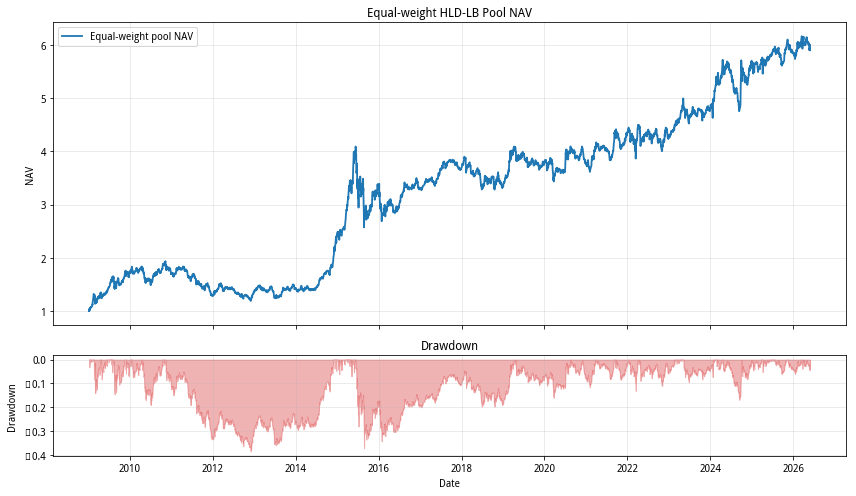

In [12]:
# ============================================================
# 等权买入表现评估：月度调仓，期内等权持有
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def instrument_to_jq(instrument):
    """sh.600000 -> 600000.XSHG; sz.000001 -> 000001.XSHE"""
    market, num = instrument.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return instrument


def load_pool_for_backtest():
    if 'pool' in globals() and isinstance(pool, pd.DataFrame) and not pool.empty:
        return pool.copy()
    if 'OUTPUT_FILE' in globals() and os.path.exists(OUTPUT_FILE):
        return pd.read_csv(OUTPUT_FILE)
    return pd.read_csv('all_a_hldb_monthly_indcap20_pool_20090101_20260601.csv')


def extract_close_frame(price_data, stocks):
    """兼容聚宽 get_price 多标的在不同 pandas 版本下的返回结构。"""
    if price_data is None:
        return pd.DataFrame()

    if isinstance(price_data, dict) and 'close' in price_data:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)

    try:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)
    except Exception:
        pass

    if isinstance(price_data, pd.DataFrame):
        if {'code', 'close'}.issubset(price_data.columns):
            date_col = None
            for candidate in ['time', 'date', 'day']:
                if candidate in price_data.columns:
                    date_col = candidate
                    break
            if date_col is None:
                date_col = price_data.index.name or price_data.index
            if isinstance(date_col, str):
                close = price_data.pivot(index=date_col, columns='code', values='close')
            else:
                tmp = price_data.copy()
                tmp['_date'] = tmp.index
                close = tmp.pivot(index='_date', columns='code', values='close')
            return close.reindex(columns=stocks)

        if set(stocks).issubset(set(price_data.columns)):
            return price_data.reindex(columns=stocks)

        if 'close' in price_data.columns and len(stocks) == 1:
            return price_data[['close']].rename(columns={'close': stocks[0]})

    raise TypeError('无法解析 get_price 返回结构: {}'.format(type(price_data)))


def get_period_relative_nav(stocks, start_date, end_date):
    trade_days = list(get_trade_days(start_date=start_date, end_date=end_date))
    if len(trade_days) < 2 or not stocks:
        return pd.Series(dtype=float)

    start = pd.Timestamp(trade_days[0]).strftime('%Y-%m-%d')
    end = pd.Timestamp(trade_days[-1]).strftime('%Y-%m-%d')
    price_data = get_price(
        stocks,
        start_date=start,
        end_date=end,
        frequency='daily',
        fields=['close'],
        panel=False,
        fill_paused=True,
    )
    close = extract_close_frame(price_data, stocks)
    if close.empty:
        return pd.Series(dtype=float)

    close.index = pd.to_datetime(close.index)
    close = close.sort_index().dropna(axis=1, how='all')
    first_close = close.iloc[0].replace(0, np.nan)
    close = close.loc[:, first_close.notna()]
    first_close = first_close.loc[close.columns]
    if close.empty:
        return pd.Series(dtype=float)

    relative = close.divide(first_close, axis=1)
    return relative.mean(axis=1).dropna()


# ------------------------ 主流程 ------------------------
pool_bt = load_pool_for_backtest()
pool_bt = pool_bt.sort_values(['start_date', 'instrument']).copy()

nav_parts = []
period_stats = []
current_nav = 1.0
period_keys = pool_bt[['start_date', 'end_date']].drop_duplicates().sort_values(['start_date', 'end_date'])

for _, row in period_keys.iterrows():
    start_date = row['start_date']
    end_date = row['end_date']
    period_pool = pool_bt[(pool_bt['start_date'] == start_date) & (pool_bt['end_date'] == end_date)]
    stocks = [instrument_to_jq(x) for x in period_pool['instrument'].tolist()]

    rel_nav = get_period_relative_nav(stocks, start_date, end_date)
    if rel_nav.empty:
        print('skip empty period: {} ~ {}'.format(start_date, end_date))
        continue

    abs_nav = rel_nav * current_nav
    if nav_parts:
        abs_nav = abs_nav.iloc[1:]  # 去掉和上一期衔接处可能重复的首日
    nav_parts.append(abs_nav)

    period_ret = rel_nav.iloc[-1] / rel_nav.iloc[0] - 1
    period_stats.append({
        'start_date': start_date,
        'end_date': end_date,
        'stocks': len(stocks),
        'trade_days': len(rel_nav),
        'period_return': period_ret,
    })
    current_nav = current_nav * rel_nav.iloc[-1] / rel_nav.iloc[0]

nav = pd.concat(nav_parts).sort_index()
nav = nav[~nav.index.duplicated(keep='last')]
drawdown = nav / nav.cummax() - 1
returns = nav.pct_change().dropna()

bt_stats = {
    'start': nav.index.min().strftime('%Y-%m-%d'),
    'end': nav.index.max().strftime('%Y-%m-%d'),
    'trade_days': len(nav),
    'total_return': nav.iloc[-1] / nav.iloc[0] - 1,
    'annual_return': (nav.iloc[-1] / nav.iloc[0]) ** (252.0 / max(len(nav) - 1, 1)) - 1,
    'annual_volatility': returns.std() * np.sqrt(252) if len(returns) else np.nan,
    'max_drawdown': drawdown.min(),
    'final_nav': nav.iloc[-1],
}

bt_stats_df = pd.DataFrame([bt_stats])
period_stats_df = pd.DataFrame(period_stats)

print('等权股票池表现统计')
display(bt_stats_df)
print('分期收益预览')
display(period_stats_df.head())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(nav.index, nav.values, label='Equal-weight pool NAV', color='#1f77b4', linewidth=1.8)
axes[0].set_title('Equal-weight HLD-LB Pool NAV')
axes[0].set_ylabel('NAV')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')

axes[1].fill_between(drawdown.index, drawdown.values, 0, color='#d62728', alpha=0.35)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


市值暴露统计


,end_date,market_cap_max,market_cap_mean,market_cap_median,market_cap_min,market_cap_p25,market_cap_p75,select_date,start_date,stocks,top3_industry_weight,top_industry,top_industry_weight
0,2009-01-31,11824.2673,728.821322,61.89110,7.0880,32.653000,161.503375,2008-12-31,2009-01-01,50,0.50,交通运输I,0.20
1,2009-02-28,12225.0899,772.193362,77.73970,7.8400,36.818775,180.138275,2009-01-23,2009-02-01,50,0.54,交通运输I,0.20
2,2009-03-31,12458.9031,787.309696,69.86950,7.4373,36.453325,189.967575,2009-02-27,2009-03-01,50,0.48,交通运输I,0.20
3,2009-04-30,13160.3427,689.062916,80.63545,8.1260,41.068825,219.221300,2009-03-31,2009-04-01,50,0.52,交通运输I,0.20
4,2009-05-31,13661.3710,708.399722,76.89460,8.0750,41.904175,219.929325,2009-04-30,2009-05-01,50,0.50,交通运输I,0.20
5,2009-06-30,25000.6656,1223.041254,87.06185,10.3535,42.016525,247.274500,2009-05-27,2009-06-01,50,0.42,交通运输I,0.20
6,2009-07-31,26501.4376,1551.333512,91.03710,14.2290,41.452025,238.888425,2009-06-30,2009-07-01,50,0.40,交通运输I,0.18
7,2009-08-31,28789.1998,1626.342884,99.37800,18.0682,44.616000,193.715600,2009-07-31,2009-08-01,50,0.50,交通运输I,0.20
8,2009-09-30,23426.6852,1330.354638,81.98390,15.1810,41.295450,241.950125,2009-08-31,2009-09-01,50,0.48,交通运输I,0.20
9,2009-10-31,23243.6642,1397.449432,84.28835,15.9831,44.372025,240.211800,2009-09-30,2009-10-01,50,0.50,交通运输I,0.20


行业暴露预览


,count,end_date,industry,select_date,start_date,weight
0,10,2009-01-31,交通运输I,2008-12-31,2009-01-01,0.20
1,8,2009-01-31,钢铁I,2008-12-31,2009-01-01,0.16
2,7,2009-01-31,化工I,2008-12-31,2009-01-01,0.14
3,6,2009-01-31,公用事业I,2008-12-31,2009-01-01,0.12
4,5,2009-01-31,金融服务I,2008-12-31,2009-01-01,0.10
5,3,2009-01-31,交运设备I,2008-12-31,2009-01-01,0.06
6,2,2009-01-31,商业贸易I,2008-12-31,2009-01-01,0.04
7,2,2009-01-31,轻工制造I,2008-12-31,2009-01-01,0.04
8,1,2009-01-31,建筑建材I,2008-12-31,2009-01-01,0.02
9,1,2009-01-31,家用电器I,2008-12-31,2009-01-01,0.02


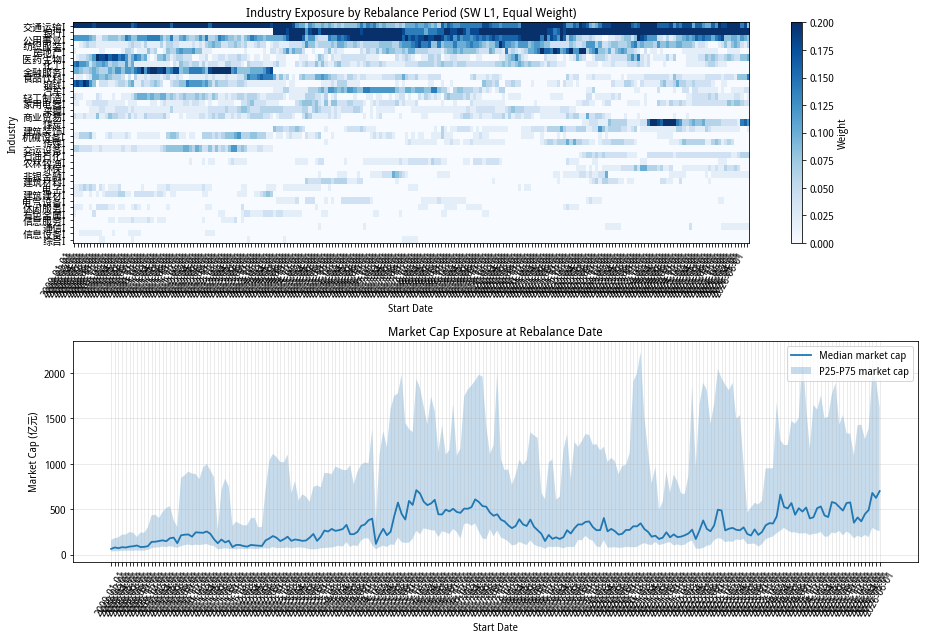

In [13]:
# ============================================================
# 行业与市值暴露分析
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_pool_detail_for_exposure():
    if 'pool_detail' in globals() and isinstance(pool_detail, pd.DataFrame) and not pool_detail.empty:
        return pool_detail.copy()
    if 'DETAIL_FILE' in globals() and os.path.exists(DETAIL_FILE):
        return pd.read_csv(DETAIL_FILE)
    return pd.read_csv('all_a_hldb_monthly_indcap20_pool_detail_20090101_20260601.csv')


def instrument_to_jq(instrument):
    """sh.600000 -> 600000.XSHG; sz.000001 -> 000001.XSHE"""
    market, num = instrument.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return instrument


def get_industry_name(industry_info, code, industry_type='sw_l1'):
    info = industry_info.get(code, {}) if isinstance(industry_info, dict) else {}
    node = info.get(industry_type, {}) if isinstance(info, dict) else {}
    return node.get('industry_name', 'Unknown') if isinstance(node, dict) else 'Unknown'


pool_exp = load_pool_detail_for_exposure()
pool_exp = pool_exp.sort_values(['start_date', 'instrument']).copy()
pool_exp['jq_code'] = pool_exp['instrument'].map(instrument_to_jq)

industry_rows = []
market_cap_rows = []
period_keys = pool_exp[['select_date', 'start_date', 'end_date']].drop_duplicates().sort_values(['start_date'])

for _, period in period_keys.iterrows():
    select_date = period['select_date']
    start_date = period['start_date']
    end_date = period['end_date']
    holdings = pool_exp[(pool_exp['start_date'] == start_date) & (pool_exp['end_date'] == end_date)].copy()
    codes = holdings['jq_code'].tolist()

    industry_info = get_industry(codes, date=select_date)
    holdings['industry'] = [get_industry_name(industry_info, code, industry_type='sw_l1') for code in codes]

    if 'market_cap' not in holdings.columns or holdings['market_cap'].isna().all():
        val = get_valuation(codes, end_date=select_date, count=1, fields=['market_cap'])
        val = val.sort_values(['code', 'day']).groupby('code', as_index=False).tail(1)
        market_cap = val.set_index('code')['market_cap'].astype(float)
        holdings['market_cap'] = holdings['jq_code'].map(market_cap)

    n = len(holdings)
    industry_counts = holdings['industry'].value_counts().sort_values(ascending=False)
    for industry, count in industry_counts.items():
        industry_rows.append({
            'select_date': select_date,
            'start_date': start_date,
            'end_date': end_date,
            'industry': industry,
            'count': int(count),
            'weight': count / n if n else np.nan,
        })

    market_cap_rows.append({
        'select_date': select_date,
        'start_date': start_date,
        'end_date': end_date,
        'stocks': n,
        'market_cap_mean': holdings['market_cap'].mean(),
        'market_cap_median': holdings['market_cap'].median(),
        'market_cap_p25': holdings['market_cap'].quantile(0.25),
        'market_cap_p75': holdings['market_cap'].quantile(0.75),
        'market_cap_min': holdings['market_cap'].min(),
        'market_cap_max': holdings['market_cap'].max(),
        'top_industry': industry_counts.index[0] if len(industry_counts) else 'Unknown',
        'top_industry_weight': industry_counts.iloc[0] / n if n and len(industry_counts) else np.nan,
        'top3_industry_weight': industry_counts.head(3).sum() / n if n else np.nan,
    })

industry_exposure = pd.DataFrame(industry_rows)
market_cap_exposure = pd.DataFrame(market_cap_rows)

print('市值暴露统计')
display(market_cap_exposure)

print('行业暴露预览')
display(industry_exposure.sort_values(['start_date', 'weight'], ascending=[True, False]).head(20))

industry_pivot = industry_exposure.pivot(index='start_date', columns='industry', values='weight').fillna(0)
industry_pivot = industry_pivot.loc[:, industry_pivot.mean().sort_values(ascending=False).index]

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

im = axes[0].imshow(industry_pivot.T.values, aspect='auto', cmap='Blues', vmin=0, vmax=max(0.01, industry_pivot.values.max()))
axes[0].set_title('Industry Exposure by Rebalance Period (SW L1, Equal Weight)')
axes[0].set_yticks(range(len(industry_pivot.columns)))
axes[0].set_yticklabels(industry_pivot.columns)
axes[0].set_xticks(range(len(industry_pivot.index)))
axes[0].set_xticklabels(industry_pivot.index, rotation=60, ha='right')
axes[0].set_xlabel('Start Date')
axes[0].set_ylabel('Industry')
fig.colorbar(im, ax=axes[0], label='Weight')

axes[1].plot(market_cap_exposure['start_date'], market_cap_exposure['market_cap_median'], label='Median market cap', linewidth=1.8)
axes[1].fill_between(
    market_cap_exposure['start_date'],
    market_cap_exposure['market_cap_p25'],
    market_cap_exposure['market_cap_p75'],
    alpha=0.25,
    label='P25-P75 market cap',
)
axes[1].set_title('Market Cap Exposure at Rebalance Date')
axes[1].set_ylabel('Market Cap (亿元)')
axes[1].set_xlabel('Start Date')
axes[1].tick_params(axis='x', rotation=60)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


# 红利质量风格池构建指南

本文定义“红利质量”时点风格股票池的构建方法。该风格池强调：估值不能太贵，盈利和收入增长不能太差，同时具备较高股息率。

该池可作为红利低波的互补子池，也可以作为“红利增强”中的质量/价值分支。

## 一、输出格式

输出 CSV，固定三列：

```csv
instrument,start_date,end_date
sh.600000,2011-01-01,2011-06-30
sz.000001,2011-01-01,2011-06-30
```

字段含义：

- `instrument`：股票代码，使用项目统一格式，例如 `sh.600000`、`sz.000001`。
- `start_date`：该股票进入红利质量池的生效开始日期。
- `end_date`：该股票在该期红利质量池中的生效结束日期。

每个横截面默认选取 `100` 只股票。

## 二、调池频率

建议每月调池一次

## 三、基础股票池

每个调池时点，从当时可交易股票范围出发，先做基础过滤。

基础过滤条件：

```text
1. 剔除上市不满 250 天的股票
2. 剔除科创板，代码 68 开头
3. 剔除北交所，代码 4 或 8 开头
4. 剔除 ST / *ST 股票
5. 剔除调池时点停牌股票
6. 剔除数据缺失严重或无法计算核心指标的股票
```


## 四、红利质量筛选逻辑

红利质量池分两步筛选：

```text
先做财务质量和估值过滤
再做股息率过滤
```

### 1. 财务质量与估值过滤

在基础股票池中，保留满足以下条件的股票：

```text
PE 在 5 到 50 之间
净资产收益率增长 inc_return 在 5% 到 100% 之间
营业收入同比增长 inc_total_revenue_year_on_year 在 5% 到 100% 之间
净利润同比增长 inc_net_profit_year_on_year 在 10% 到 100% 之间
```

对应聚宽策略中的逻辑是：

```python
get_fundamentals(
    query(valuation.code).filter(
        valuation.code.in_(initial_list),
        valuation.pe_ratio.between(5, 50),
        indicator.inc_return.between(5, 100),
        indicator.inc_total_revenue_year_on_year.between(5, 100),
        indicator.inc_net_profit_year_on_year.between(10, 100),
    ),
    date=context.previous_date,
)
```

这些条件的含义：

- `PE 5-50`：剔除亏损、极端低估异常、估值过高股票；
- `ROE 增长 > 5%`：要求盈利能力改善；
- `营收增长 > 5%`：要求收入端不弱；
- `净利增长 > 10%`：要求利润端有增长；
- 上限 `100%` 用于剔除极端异常值。

### 2. 股息率过滤

在通过财务质量和估值过滤后的股票中，计算过去一年股息率：

```text
股息率 = 过去一年现金分红总额 / 调池时点总市值
```

筛选规则：

```text
1. 按股息率从高到低排序
2. 取股息率最高的前 10%
3. 同时要求股息率 > 3%
```

对应聚宽策略中的逻辑是：

```python
get_dividend_ratio_filter_list(
    context,
    stock_list_b,
    False,   # 股息率降序
    0.00,
    0.10,    # 股息率最高前 10%
    0.03     # 股息率 > 3%
)
```

### 3. 最终截面选择

完成“财务质量与估值过滤 + 股息率过滤”后，按股息率从高到低取前 `50` 只。

如果希望更偏质量，可以使用综合分：

```text
score =
  股息率 rank
+ ROE 增长 rank
+ 营收增长 rank
+ 净利增长 rank
- PE rank
```

第一版建议使用更简单、可复现的规则：

```text
满足财务过滤后，按股息率取前 50
```

如果不足 50 只：

```text
保留实际满足条件的股票数量，不强行补齐。
```

如果希望每期严格 50 只，可以放宽条件，但必须记录放宽规则。例如：

```text
先保留股息率 > 3%
若数量不足，再从股息率最高前 20% 内按综合质量分补齐
```

In [2]:
# ============================================================
# 红利质量动态股票池构建 - 聚宽研究环境
# 构建区间: 2009-01-01 ~ 2026-06-01
# 输出: all_a_hq_monthly_indcap20_pool_20090101_20260601.csv
# ============================================================

import math
import time
from datetime import timedelta

import numpy as np
import pandas as pd

try:
    from jqdata import *
    from jqdata import finance
except ImportError:
    pass

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

# ------------------------ 配置 ------------------------
HQ_START_DATE = '2009-01-01'
HQ_END_DATE = '2026-06-01'
HQ_OUTPUT_FILE = 'all_a_hq_monthly_indcap20_pool_20090101_20260601.csv'
HQ_DETAIL_FILE = 'all_a_hq_monthly_indcap20_pool_detail_20090101_20260601.csv'

HQ_MIN_LISTING_TRADE_DAYS = 250
HQ_DIVIDEND_TOP_PCT = 0.10
HQ_DIVIDEND_RELAXED_TOP_PCT = 0.30
HQ_MIN_DIVIDEND_YIELD = 0.03
HQ_FINAL_SELECT_N = 50
HQ_INDUSTRY_CAP = 0.20
HQ_INDUSTRY_TYPE = 'sw_l1'
HQ_DIVIDEND_AMOUNT_TO_YIYUAN = 10000


def hq_log(message):
    print(time.strftime('%H:%M:%S'), message, flush=True)


def hq_progress_iter(iterable, total=None, desc=None):
    if tqdm is not None:
        return tqdm(iterable, total=total, desc=desc)
    return iterable


def hq_jq_to_instrument(code):
    num, exchange = code.split('.')
    if exchange == 'XSHG':
        return 'sh.' + num
    if exchange == 'XSHE':
        return 'sz.' + num
    return code.lower()


def hq_previous_trade_day(date_like):
    day = pd.Timestamp(date_like).date()
    trade_days = get_trade_days(end_date=day, count=1)
    if len(trade_days) == 0:
        raise ValueError('无法找到 {} 之前的交易日'.format(day))
    return pd.Timestamp(trade_days[-1]).date()


def hq_first_day_next_month(day):
    if day.month == 12:
        return pd.Timestamp(year=day.year + 1, month=1, day=1).date()
    return pd.Timestamp(year=day.year, month=day.month + 1, day=1).date()


def hq_make_monthly_periods(start_date=HQ_START_DATE, end_date=HQ_END_DATE):
    start = pd.Timestamp(start_date).date()
    end = pd.Timestamp(end_date).date()
    periods = []
    period_start = start
    while period_start <= end:
        next_start = hq_first_day_next_month(period_start)
        period_end = min(next_start - timedelta(days=1), end)
        select_date = hq_previous_trade_day(period_start - timedelta(days=1))
        periods.append({'select_date': select_date, 'start_date': period_start, 'end_date': period_end})
        period_start = next_start
    return periods


def hq_filter_code_board(stocks):
    result = []
    for code in stocks:
        num, exchange = code.split('.')
        if exchange in ('XBJE', 'XBEI'):
            continue
        if exchange == 'XSHG' and num.startswith('68'):
            continue
        if exchange == 'XSHE' and (num.startswith('30') or num.startswith('4') or num.startswith('8')):
            continue
        if num.startswith('4') or num.startswith('8'):
            continue
        result.append(code)
    return result


def hq_filter_listing_days(stocks, select_date, min_days=HQ_MIN_LISTING_TRADE_DAYS):
    if not stocks:
        return []
    all_sec = get_all_securities(['stock'], date=select_date)
    trade_days = list(get_trade_days(end_date=select_date, count=min_days + 1))
    if len(trade_days) <= min_days:
        raise ValueError('无法取得足够交易日用于上市天数过滤: {}'.format(select_date))
    listing_cutoff = pd.Timestamp(trade_days[0]).date()
    result = []
    for code in stocks:
        if code not in all_sec.index:
            continue
        start_date = pd.Timestamp(all_sec.loc[code, 'start_date']).date()
        if start_date <= listing_cutoff:
            result.append(code)
    return result


def hq_filter_st(stocks, select_date):
    if not stocks:
        return []
    st_df = get_extras('is_st', stocks, start_date=select_date, end_date=select_date, df=True)
    if st_df is None or st_df.empty:
        return stocks
    st_row = st_df.iloc[-1].fillna(True)
    return [code for code in stocks if code in st_row.index and not bool(st_row[code])]


def hq_paused_series_from_price(price_data, stocks):
    if price_data is None:
        return pd.Series(True, index=stocks)
    if isinstance(price_data, pd.DataFrame):
        if {'code', 'paused'}.issubset(price_data.columns):
            return price_data.groupby('code')['paused'].last().reindex(stocks).fillna(1).astype(bool)
        if 'paused' in price_data.columns and len(stocks) == 1:
            return pd.Series({stocks[0]: bool(price_data['paused'].iloc[-1])})
        if set(stocks).issubset(set(price_data.columns)):
            return price_data.iloc[-1].reindex(stocks).fillna(1).astype(bool)
    if isinstance(price_data, dict) and 'paused' in price_data:
        paused = price_data['paused']
        if isinstance(paused, pd.DataFrame):
            return paused.iloc[-1].reindex(stocks).fillna(1).astype(bool)
    try:
        paused = price_data['paused']
        if isinstance(paused, pd.DataFrame):
            return paused.iloc[-1].reindex(stocks).fillna(1).astype(bool)
    except Exception:
        pass
    raise TypeError('无法解析 get_price 返回结构: {}'.format(type(price_data)))


def hq_filter_paused(stocks, select_date):
    if not stocks:
        return []
    price_data = get_price(
        stocks,
        start_date=select_date,
        end_date=select_date,
        frequency='daily',
        fields=['paused'],
        panel=False,
        fill_paused=True,
    )
    paused = hq_paused_series_from_price(price_data, stocks)
    return [code for code in stocks if code in paused.index and not bool(paused.loc[code])]


def hq_get_market_cap(stocks, select_date):
    if not stocks:
        return pd.Series(dtype=float, name='market_cap')
    val = get_valuation(stocks, end_date=select_date, count=1, fields=['market_cap'])
    if val is None or val.empty:
        return pd.Series(dtype=float, name='market_cap')
    val = val.sort_values(['code', 'day']).groupby('code', as_index=False).tail(1)
    return val.set_index('code')['market_cap'].astype(float).rename('market_cap')


def hq_get_dividend_cash(stocks, select_date):
    if not stocks:
        return pd.Series(dtype=float, name='dividend_cash_yiyuan')
    lookback_start = (pd.Timestamp(select_date) - pd.DateOffset(years=1)).date()
    q = query(
        finance.STK_XR_XD.code,
        finance.STK_XR_XD.board_plan_pub_date,
        finance.STK_XR_XD.a_registration_date,
        finance.STK_XR_XD.bonus_amount_rmb,
    ).filter(
        finance.STK_XR_XD.code.in_(stocks),
        finance.STK_XR_XD.board_plan_pub_date <= select_date,
        finance.STK_XR_XD.a_registration_date >= lookback_start,
        finance.STK_XR_XD.a_registration_date <= select_date,
    )
    div = finance.run_query(q)
    if div is None or div.empty:
        return pd.Series(0.0, index=stocks, name='dividend_cash_yiyuan')
    div['bonus_amount_rmb'] = pd.to_numeric(div['bonus_amount_rmb'], errors='coerce').fillna(0.0)
    cash = div.groupby('code')['bonus_amount_rmb'].sum() / HQ_DIVIDEND_AMOUNT_TO_YIYUAN
    return cash.reindex(stocks).fillna(0.0).rename('dividend_cash_yiyuan')


def hq_get_quality_fundamentals(stocks, select_date):
    """取宽财务候选，严格/放宽过滤放到后续分层选择里做。"""
    columns = [
        'pe_ratio', 'inc_return',
        'inc_total_revenue_year_on_year', 'inc_net_profit_year_on_year'
    ]
    if not stocks:
        return pd.DataFrame(columns=columns)
    q = query(
        valuation.code,
        valuation.pe_ratio,
        indicator.inc_return,
        indicator.inc_total_revenue_year_on_year,
        indicator.inc_net_profit_year_on_year,
    ).filter(
        valuation.code.in_(stocks),
    )
    df = get_fundamentals(q, date=select_date)
    if df is None or df.empty:
        return pd.DataFrame(columns=columns)
    df = df.drop_duplicates('code').set_index('code')
    for col in columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[columns]


def hq_get_industry_name(industry_info, code, industry_type=HQ_INDUSTRY_TYPE):
    info = industry_info.get(code, {}) if isinstance(industry_info, dict) else {}
    node = info.get(industry_type, {}) if isinstance(info, dict) else {}
    if isinstance(node, dict) and node.get('industry_name'):
        return node.get('industry_name')
    fallback = info.get('jq_l1', {}) if isinstance(info, dict) else {}
    if isinstance(fallback, dict) and fallback.get('industry_name'):
        return fallback.get('industry_name')
    return 'Unknown'


def hq_get_industry_series(stocks, select_date, industry_type=HQ_INDUSTRY_TYPE):
    if not stocks:
        return pd.Series(dtype=object, name='industry')
    industry_info = get_industry(stocks, date=select_date)
    values = [hq_get_industry_name(industry_info, code, industry_type=industry_type) for code in stocks]
    return pd.Series(values, index=stocks, name='industry')


def hq_build_base_universe(select_date):
    all_sec = get_all_securities(['stock'], date=select_date)
    stocks = list(all_sec.index)
    n0 = len(stocks)
    stocks = hq_filter_code_board(stocks)
    n1 = len(stocks)
    stocks = hq_filter_listing_days(stocks, select_date)
    n2 = len(stocks)
    stocks = hq_filter_st(stocks, select_date)
    n3 = len(stocks)
    stocks = hq_filter_paused(stocks, select_date)
    n4 = len(stocks)
    return stocks, {
        'base_universe': n0,
        'after_board_filter': n1,
        'after_listing_filter': n2,
        'after_st_filter': n3,
        'after_paused_filter': n4,
    }


def hq_industry_cap_count(n=HQ_FINAL_SELECT_N, cap=HQ_INDUSTRY_CAP):
    return max(1, int(math.floor(n * cap + 1e-9)))


def hq_take_unique_with_industry_cap(frames, n=HQ_FINAL_SELECT_N, cap=HQ_INDUSTRY_CAP):
    selected_parts = []
    used = set()
    industry_counts = {}
    cap_n = hq_industry_cap_count(n=n, cap=cap)
    for frame in frames:
        if frame is None or frame.empty:
            continue
        for code in frame.index:
            if code in used:
                continue
            row = frame.loc[[code]].copy()
            industry_name = row['industry'].iloc[0] if 'industry' in row.columns else 'Unknown'
            if industry_counts.get(industry_name, 0) >= cap_n:
                continue
            selected_parts.append(row)
            used.add(code)
            industry_counts[industry_name] = industry_counts.get(industry_name, 0) + 1
            if len(selected_parts) >= n:
                break
        if len(selected_parts) >= n:
            break
    if not selected_parts:
        return pd.DataFrame()
    return pd.concat(selected_parts, axis=0, sort=False).head(n)


def hq_select(frame):
    frame = frame.copy()
    frame['strict_quality_filter'] = (
        frame['pe_ratio'].between(5, 50)
        & frame['inc_return'].between(5, 100)
        & frame['inc_total_revenue_year_on_year'].between(5, 100)
        & frame['inc_net_profit_year_on_year'].between(10, 100)
    )
    frame['relaxed_quality_filter'] = (
        frame['pe_ratio'].between(3, 80)
        & frame['inc_return'].between(0, 150)
        & frame['inc_total_revenue_year_on_year'].between(0, 150)
        & frame['inc_net_profit_year_on_year'].between(0, 200)
    )

    frame['dividend_rank_pct'] = frame['dividend_yield'].rank(ascending=False, pct=True, method='first')
    frame['roe_growth_rank_pct'] = frame['inc_return'].rank(ascending=False, pct=True, method='first')
    frame['revenue_growth_rank_pct'] = frame['inc_total_revenue_year_on_year'].rank(ascending=False, pct=True, method='first')
    frame['profit_growth_rank_pct'] = frame['inc_net_profit_year_on_year'].rank(ascending=False, pct=True, method='first')
    frame['pe_rank_pct'] = frame['pe_ratio'].rank(ascending=True, pct=True, method='first')
    frame['hq_score'] = (
        frame['dividend_rank_pct']
        + frame['roe_growth_rank_pct']
        + frame['revenue_growth_rank_pct']
        + frame['profit_growth_rank_pct']
        + frame['pe_rank_pct']
    )

    strict_quality = frame[frame['strict_quality_filter']].copy()
    strict_n = max(1, int(math.ceil(len(strict_quality) * HQ_DIVIDEND_TOP_PCT))) if len(strict_quality) else 0
    strict = strict_quality.sort_values('dividend_yield', ascending=False).head(strict_n)
    strict = strict[strict['dividend_yield'] > HQ_MIN_DIVIDEND_YIELD].copy()
    strict['selection_tier'] = 'strict_quality_top10_dividend_gt3pct'

    high_dividend = strict_quality[strict_quality['dividend_yield'] > HQ_MIN_DIVIDEND_YIELD].sort_values(
        ['dividend_rank_pct', 'hq_score']
    ).copy()
    high_dividend['selection_tier'] = 'fill_strict_quality_dividend_yield_gt_3pct'

    relaxed_n = max(HQ_FINAL_SELECT_N, int(math.ceil(len(strict_quality) * HQ_DIVIDEND_RELAXED_TOP_PCT))) if len(strict_quality) else 0
    strict_top30 = strict_quality.sort_values('dividend_yield', ascending=False).head(relaxed_n)
    strict_top30 = strict_top30.sort_values(['dividend_rank_pct', 'hq_score']).copy()
    strict_top30['selection_tier'] = 'fill_strict_quality_top30pct_dividend'

    relaxed_quality = frame[frame['relaxed_quality_filter']].sort_values(
        ['dividend_rank_pct', 'hq_score']
    ).copy()
    relaxed_quality['selection_tier'] = 'fill_relaxed_quality_pool'

    full_rank = frame.sort_values(['dividend_rank_pct', 'hq_score']).copy()
    full_rank['selection_tier'] = 'fill_full_financial_pool'

    selected = hq_take_unique_with_industry_cap(
        [strict, high_dividend, strict_top30, relaxed_quality, full_rank],
        HQ_FINAL_SELECT_N,
        HQ_INDUSTRY_CAP,
    )
    return selected, strict, strict_quality, relaxed_quality


def hq_build_one_period(period):
    select_date = period['select_date']
    base_stocks, counts = hq_build_base_universe(select_date)

    quality = hq_get_quality_fundamentals(base_stocks, select_date)
    candidate_stocks = list(quality.index)
    market_cap = hq_get_market_cap(candidate_stocks, select_date)
    dividend_cash = hq_get_dividend_cash(candidate_stocks, select_date)
    industry_series = hq_get_industry_series(candidate_stocks, select_date)

    frame = pd.concat([quality, market_cap, dividend_cash, industry_series], axis=1)
    frame['dividend_yield'] = frame['dividend_cash_yiyuan'] / frame['market_cap']
    frame = frame.replace([float('inf'), float('-inf')], np.nan).dropna(
        subset=['pe_ratio', 'inc_return', 'inc_total_revenue_year_on_year',
                'inc_net_profit_year_on_year', 'market_cap', 'dividend_yield']
    )
    frame = frame[frame['market_cap'] > 0].copy()

    selected, strict, strict_quality, relaxed_quality = hq_select(frame)
    if len(selected) != HQ_FINAL_SELECT_N:
        raise ValueError(
            '调池日 {} 宽候选 {} 只，严格质量 {} 只，放宽质量 {} 只，但只选出 {} 只'.format(
                select_date, len(frame), len(strict_quality), len(relaxed_quality), len(selected)
            )
        )

    selected['instrument'] = [hq_jq_to_instrument(code) for code in selected.index]
    selected['start_date'] = pd.Timestamp(period['start_date']).strftime('%Y-%m-%d')
    selected['end_date'] = pd.Timestamp(period['end_date']).strftime('%Y-%m-%d')
    selected['select_date'] = pd.Timestamp(select_date).strftime('%Y-%m-%d')

    tier_counts = selected['selection_tier'].value_counts().to_dict() if len(selected) else {}
    industry_counts = selected['industry'].value_counts() if len(selected) else pd.Series(dtype=int)
    stats = dict(counts)
    stats.update({
        'select_date': pd.Timestamp(select_date).strftime('%Y-%m-%d'),
        'start_date': pd.Timestamp(period['start_date']).strftime('%Y-%m-%d'),
        'end_date': pd.Timestamp(period['end_date']).strftime('%Y-%m-%d'),
        'candidate_count': len(frame),
        'strict_quality_count': len(strict_quality),
        'relaxed_quality_count': len(relaxed_quality),
        'strict_dividend_stage': len(strict),
        'selected': len(selected),
        'industry_cap_count': hq_industry_cap_count(),
        'max_industry_count': int(industry_counts.max()) if len(industry_counts) else 0,
        'max_industry_weight': industry_counts.max() / float(HQ_FINAL_SELECT_N) if len(industry_counts) else np.nan,
        'top_industry': industry_counts.index[0] if len(industry_counts) else 'Unknown',
        'strict_selected_count': tier_counts.get('strict_quality_top10_dividend_gt3pct', 0),
        'fill_dividend_yield_gt_3pct_count': tier_counts.get('fill_strict_quality_dividend_yield_gt_3pct', 0),
        'fill_top30pct_dividend_count': tier_counts.get('fill_strict_quality_top30pct_dividend', 0),
        'fill_relaxed_quality_pool_count': tier_counts.get('fill_relaxed_quality_pool', 0),
        'fill_full_financial_pool_count': tier_counts.get('fill_full_financial_pool', 0),
        'median_dividend_yield': selected['dividend_yield'].median() if len(selected) else np.nan,
        'median_pe_ratio': selected['pe_ratio'].median() if len(selected) else np.nan,
        'median_inc_return': selected['inc_return'].median() if len(selected) else np.nan,
        'median_inc_total_revenue_yoy': selected['inc_total_revenue_year_on_year'].median() if len(selected) else np.nan,
        'median_inc_net_profit_yoy': selected['inc_net_profit_year_on_year'].median() if len(selected) else np.nan,
    })

    detail_cols = [
        'select_date', 'start_date', 'end_date', 'instrument', 'selection_tier', 'industry',
        'market_cap', 'dividend_cash_yiyuan', 'dividend_yield',
        'pe_ratio', 'inc_return', 'inc_total_revenue_year_on_year', 'inc_net_profit_year_on_year',
        'strict_quality_filter', 'relaxed_quality_filter',
        'dividend_rank_pct', 'roe_growth_rank_pct', 'revenue_growth_rank_pct',
        'profit_growth_rank_pct', 'pe_rank_pct', 'hq_score'
    ]
    return selected[detail_cols], stats


# ------------------------ 主流程 ------------------------
hq_periods = hq_make_monthly_periods(HQ_START_DATE, HQ_END_DATE)
hq_log('periods: {}'.format(len(hq_periods)))

hq_all_details = []
hq_all_stats = []
for period in hq_progress_iter(hq_periods, total=len(hq_periods), desc='monthly hq periods'):
    hq_log('build period: select {} -> {} ~ {}'.format(
        period['select_date'], period['start_date'], period['end_date']
    ))
    detail, stats = hq_build_one_period(period)
    hq_all_details.append(detail)
    hq_all_stats.append(stats)
    hq_log('selected: {selected}, strict: {strict_selected_count}, fill_gt_3pct: {fill_dividend_yield_gt_3pct_count}, fill_top30: {fill_top30pct_dividend_count}, fill_relaxed: {fill_relaxed_quality_pool_count}, fill_full: {fill_full_financial_pool_count}, top_industry: {top_industry} {max_industry_count}'.format(**stats))

hq_pool_detail = pd.concat(hq_all_details, ignore_index=True) if hq_all_details else pd.DataFrame()
hq_stats_df = pd.DataFrame(hq_all_stats)

hq_pool = hq_pool_detail[['instrument', 'start_date', 'end_date']].copy()
hq_pool = hq_pool.sort_values(['start_date', 'instrument']).reset_index(drop=True)
hq_pool_detail = hq_pool_detail.sort_values(['start_date', 'instrument']).reset_index(drop=True)

hq_pool.to_csv(HQ_OUTPUT_FILE, index=False, encoding='utf-8')
hq_pool_detail.to_csv(HQ_DETAIL_FILE, index=False, encoding='utf-8')

print('\n输出文件:')
print('  {}'.format(HQ_OUTPUT_FILE))
print('  {}'.format(HQ_DETAIL_FILE))
print('\n每期数量检查:')
display(hq_stats_df)
print('\n股票池预览:')
display(hq_pool.head(20))

assert not hq_pool.empty, '红利质量股票池为空，请检查财务过滤、分红字段或基础过滤条件。'
assert (pd.to_datetime(hq_pool['start_date']) <= pd.to_datetime(hq_pool['end_date'])).all(), '存在 start_date > end_date。'
assert hq_pool.duplicated(['instrument', 'start_date', 'end_date']).sum() == 0, '存在重复区间记录。'
assert not hq_pool['instrument'].str.startswith(('sh.68', 'sz.30', 'sz.4', 'sz.8')).any(), '存在疑似创业板/科创板/北交所代码。'
assert hq_stats_df['selected'].eq(HQ_FINAL_SELECT_N).all(), '存在未选满 {} 只的调池期。'.format(HQ_FINAL_SELECT_N)
assert hq_stats_df['max_industry_count'].le(hq_industry_cap_count()).all(), '存在单行业超过 {} 只的调池期。'.format(hq_industry_cap_count())

print('\n完成: {} 行，{} 期，{} 只不同股票'.format(
    len(hq_pool), hq_pool['start_date'].nunique(), hq_pool['instrument'].nunique()
))


19:54:14 periods: 210


19:54:14 build period: select 2008-12-31 -> 2009-01-01 ~ 2009-01-31


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:371: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.



19:54:15 selected: 50, strict: 2, fill_gt_3pct: 2, fill_top30: 12, fill_relaxed: 34, fill_full: 0, top_industry: 金融服务I 6
19:54:15 build period: select 2009-01-23 -> 2009-02-01 ~ 2009-02-28


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:371: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.



...

20:00:27 selected: 50, strict: 4, fill_gt_3pct: 8, fill_top30: 22, fill_relaxed: 16, fill_full: 0, top_industry: 食品饮料I 6

输出文件:
  all_a_hq_monthly_indcap20_pool_20090101_20260601.csv
  all_a_hq_monthly_indcap20_pool_detail_20090101_20260601.csv

每期数量检查:


,after_board_filter,after_listing_filter,after_paused_filter,after_st_filter,base_universe,candidate_count,end_date,fill_dividend_yield_gt_3pct_count,fill_full_financial_pool_count,fill_relaxed_quality_pool_count,fill_top30pct_dividend_count,industry_cap_count,max_industry_count,max_industry_weight,median_dividend_yield,median_inc_net_profit_yoy,median_inc_return,median_inc_total_revenue_yoy,median_pe_ratio,relaxed_quality_count,select_date,selected,start_date,strict_dividend_stage,strict_quality_count,strict_selected_count,top_industry
0,1605,1524,1329,1361,1605,338,2009-01-31,2,0,34,12,10,6,0.12,0.020808,47.955,4.520,28.095,16.59015,85,2008-12-31,50,2009-01-01,2,16,2,金融服务I
1,1605,1530,1354,1369,1605,344,2009-02-28,5,0,31,12,10,6,0.12,0.016677,44.810,4.660,28.095,19.34385,84,2009-01-23,50,2009-02-01,2,19,2,钢铁I
2,1605,1544,1360,1384,1605,341,2009-03-31,4,0,32,12,10,6,0.12,0.015411,41.240,4.985,30.665,19.10720,77,2009-02-27,50,2009-03-01,2,18,2,公用事业I
3,1605,1550,1357,1390,1605,341,2009-04-30,0,0,42,7,10,6,0.12,0.010165,48.695,3.675,25.315,29.38685,53,2009-03-31,50,2009-04-01,1,8,1,建筑建材I
4,1605,1552,1340,1380,1605,338,2009-05-31,0,3,39,8,10,10,0.20,0.006332,27.885,3.475,17.405,33.39625,50,2009-04-30,50,2009-05-01,0,8,0,医药生物I
5,1603,1565,1362,1395,1603,354,2009-06-30,0,0,42,8,10,10,0.20,0.006931,27.275,3.225,19.415,34.91445,59,2009-05-27,50,2009-06-01,0,8,0,医药生物I
6,1603,1579,1356,1413,1603,366,2009-07-31,0,0,41,9,10,10,0.20,0.007905,27.275,3.475,21.295,34.54020,64,2009-06-30,50,2009-07-01,0,9,0,医药生物I
7,1608,1589,1386,1424,1608,377,2009-08-31,0,0,41,9,10,9,0.18,0.007818,27.275,3.505,21.405,38.01935,66,2009-07-31,50,2009-08-01,0,9,0,医药生物I
8,1618,1595,1386,1431,1618,378,2009-09-30,0,0,30,20,10,7,0.14,0.011493,38.335,4.950,21.855,26.72105,86,2009-08-31,50,2009-09-01,0,20,0,建筑建材I
9,1630,1600,1409,1437,1630,392,2009-10-31,0,0,30,20,10,6,0.12,0.011187,40.120,4.950,21.855,29.78065,89,2009-09-30,50,2009-10-01,0,20,0,医药生物I



股票池预览:


,instrument,start_date,end_date
0,sh.600005,2009-01-01,2009-01-31
1,sh.600007,2009-01-01,2009-01-31
2,sh.600015,2009-01-01,2009-01-31
3,sh.600016,2009-01-01,2009-01-31
4,sh.600019,2009-01-01,2009-01-31
5,sh.600022,2009-01-01,2009-01-31
6,sh.600033,2009-01-01,2009-01-31
7,sh.600036,2009-01-01,2009-01-31
8,sh.600096,2009-01-01,2009-01-31
9,sh.600143,2009-01-01,2009-01-31



完成: 10500 行，210 期，1044 只不同股票


skip empty period: 2026-06-01 ~ 2026-06-01
红利质量等权股票池表现统计


,annual_return,annual_volatility,end,final_nav,max_drawdown,start,total_return,trade_days
0,0.120937,0.227968,2026-05-29,6.168107,-0.431432,2009-01-05,5.168107,4017


分期收益预览


,end_date,period_return,start_date,stocks,trade_days
0,2009-01-31,0.101676,2009-01-01,50,15
1,2009-02-28,0.040487,2009-02-01,50,20
2,2009-03-31,0.147992,2009-03-01,50,22
3,2009-04-30,0.045365,2009-04-01,50,21
4,2009-05-31,-0.008011,2009-05-01,50,18


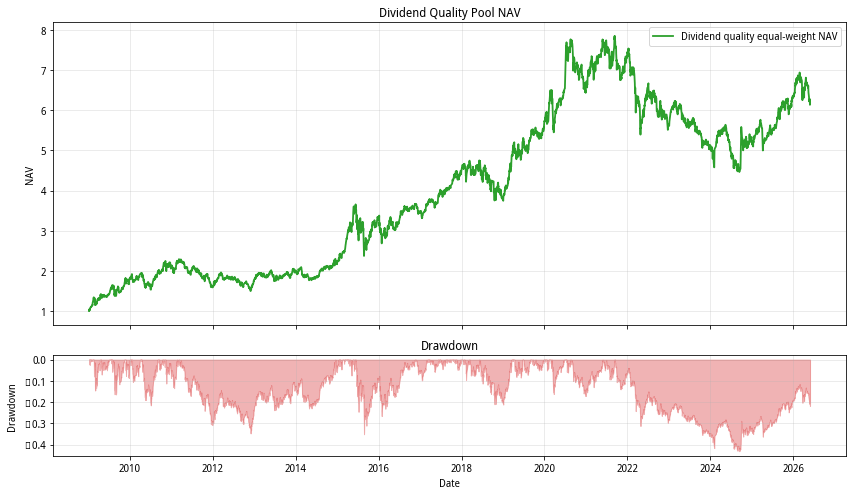

In [3]:
# ============================================================
# 红利质量等权买入表现评估：月度调仓，期内等权持有
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def hq_bt_instrument_to_jq(instrument):
    market, num = instrument.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return instrument


def hq_load_pool_for_backtest():
    if 'hq_pool' in globals() and isinstance(hq_pool, pd.DataFrame) and not hq_pool.empty:
        return hq_pool.copy()
    if 'HQ_OUTPUT_FILE' in globals() and os.path.exists(HQ_OUTPUT_FILE):
        return pd.read_csv(HQ_OUTPUT_FILE)
    return pd.read_csv('all_a_hq_monthly_indcap20_pool_20090101_20260601.csv')


def hq_extract_close_frame(price_data, stocks):
    if price_data is None:
        return pd.DataFrame()
    if isinstance(price_data, dict) and 'close' in price_data:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)
    try:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)
    except Exception:
        pass
    if isinstance(price_data, pd.DataFrame):
        if {'code', 'close'}.issubset(price_data.columns):
            date_col = None
            for candidate in ['time', 'date', 'day']:
                if candidate in price_data.columns:
                    date_col = candidate
                    break
            if isinstance(date_col, str):
                close = price_data.pivot(index=date_col, columns='code', values='close')
            else:
                tmp = price_data.copy()
                tmp['_date'] = tmp.index
                close = tmp.pivot(index='_date', columns='code', values='close')
            return close.reindex(columns=stocks)
        if set(stocks).issubset(set(price_data.columns)):
            return price_data.reindex(columns=stocks)
        if 'close' in price_data.columns and len(stocks) == 1:
            return price_data[['close']].rename(columns={'close': stocks[0]})
    raise TypeError('无法解析 get_price 返回结构: {}'.format(type(price_data)))


def hq_get_period_relative_nav(stocks, start_date, end_date):
    trade_days = list(get_trade_days(start_date=start_date, end_date=end_date))
    if len(trade_days) < 2 or not stocks:
        return pd.Series(dtype=float)
    start = pd.Timestamp(trade_days[0]).strftime('%Y-%m-%d')
    end = pd.Timestamp(trade_days[-1]).strftime('%Y-%m-%d')
    price_data = get_price(
        stocks,
        start_date=start,
        end_date=end,
        frequency='daily',
        fields=['close'],
        panel=False,
        fill_paused=True,
    )
    close = hq_extract_close_frame(price_data, stocks)
    if close.empty:
        return pd.Series(dtype=float)
    close.index = pd.to_datetime(close.index)
    close = close.sort_index().dropna(axis=1, how='all')
    first_close = close.iloc[0].replace(0, np.nan)
    close = close.loc[:, first_close.notna()]
    first_close = first_close.loc[close.columns]
    if close.empty:
        return pd.Series(dtype=float)
    relative = close.divide(first_close, axis=1)
    return relative.mean(axis=1).dropna()


hq_pool_bt = hq_load_pool_for_backtest()
hq_pool_bt = hq_pool_bt.sort_values(['start_date', 'instrument']).copy()

hq_nav_parts = []
hq_period_stats = []
hq_current_nav = 1.0
hq_period_keys = hq_pool_bt[['start_date', 'end_date']].drop_duplicates().sort_values(['start_date', 'end_date'])

for _, row in hq_period_keys.iterrows():
    start_date = row['start_date']
    end_date = row['end_date']
    period_pool = hq_pool_bt[(hq_pool_bt['start_date'] == start_date) & (hq_pool_bt['end_date'] == end_date)]
    stocks = [hq_bt_instrument_to_jq(x) for x in period_pool['instrument'].tolist()]
    rel_nav = hq_get_period_relative_nav(stocks, start_date, end_date)
    if rel_nav.empty:
        print('skip empty period: {} ~ {}'.format(start_date, end_date))
        continue
    abs_nav = rel_nav * hq_current_nav
    if hq_nav_parts:
        abs_nav = abs_nav.iloc[1:]
    hq_nav_parts.append(abs_nav)
    period_ret = rel_nav.iloc[-1] / rel_nav.iloc[0] - 1
    hq_period_stats.append({
        'start_date': start_date,
        'end_date': end_date,
        'stocks': len(stocks),
        'trade_days': len(rel_nav),
        'period_return': period_ret,
    })
    hq_current_nav = hq_current_nav * rel_nav.iloc[-1] / rel_nav.iloc[0]

hq_nav = pd.concat(hq_nav_parts).sort_index()
hq_nav = hq_nav[~hq_nav.index.duplicated(keep='last')]
hq_drawdown = hq_nav / hq_nav.cummax() - 1
hq_returns = hq_nav.pct_change().dropna()

hq_bt_stats = {
    'start': hq_nav.index.min().strftime('%Y-%m-%d'),
    'end': hq_nav.index.max().strftime('%Y-%m-%d'),
    'trade_days': len(hq_nav),
    'total_return': hq_nav.iloc[-1] / hq_nav.iloc[0] - 1,
    'annual_return': (hq_nav.iloc[-1] / hq_nav.iloc[0]) ** (252.0 / max(len(hq_nav) - 1, 1)) - 1,
    'annual_volatility': hq_returns.std() * np.sqrt(252) if len(hq_returns) else np.nan,
    'max_drawdown': hq_drawdown.min(),
    'final_nav': hq_nav.iloc[-1],
}

hq_bt_stats_df = pd.DataFrame([hq_bt_stats])
hq_period_stats_df = pd.DataFrame(hq_period_stats)

print('红利质量等权股票池表现统计')
display(hq_bt_stats_df)
print('分期收益预览')
display(hq_period_stats_df.head())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(hq_nav.index, hq_nav.values, label='Dividend quality equal-weight NAV', color='#2ca02c', linewidth=1.8)
axes[0].set_title('Dividend Quality Pool NAV')
axes[0].set_ylabel('NAV')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')

axes[1].fill_between(hq_drawdown.index, hq_drawdown.values, 0, color='#d62728', alpha=0.35)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].set_xlabel('Date')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


红利质量市值暴露统计


,end_date,market_cap_max,market_cap_mean,market_cap_median,market_cap_min,market_cap_p25,market_cap_p75,select_date,start_date,stocks,top3_industry_weight,top_industry,top_industry_weight
0,2009-01-31,18613.2334,668.188010,66.31780,6.0930,18.355750,233.889750,2008-12-31,2009-01-01,50,0.30,金融服务I,0.12
1,2009-02-28,18979.2754,696.792546,75.59975,8.4780,21.713000,198.976750,2009-01-23,2009-02-01,50,0.30,钢铁I,0.12
2,2009-03-31,19747.9635,686.565258,80.40905,10.0170,23.439375,189.115050,2009-02-27,2009-03-01,50,0.34,钢铁I,0.12
3,2009-04-30,2342.8545,207.062754,80.44730,10.6720,24.906675,155.049325,2009-03-31,2009-04-01,50,0.32,建筑建材I,0.12
4,2009-05-31,4918.7031,297.206308,114.39380,12.7890,41.572725,206.548575,2009-04-30,2009-05-01,50,0.36,医药生物I,0.20
5,2009-06-30,5036.0519,286.003502,64.29825,13.3440,31.376475,177.334600,2009-05-27,2009-06-01,50,0.38,医药生物I,0.20
6,2009-07-31,5948.9855,295.105096,66.53770,13.7840,34.618725,183.534425,2009-06-30,2009-07-01,50,0.38,医药生物I,0.20
7,2009-08-31,7671.4266,356.955124,73.74665,18.7950,37.719650,188.071025,2009-07-31,2009-08-01,50,0.40,医药生物I,0.18
8,2009-09-30,5545.2262,273.592336,64.52450,11.9788,30.502650,156.590100,2009-08-31,2009-09-01,50,0.36,建筑建材I,0.14
9,2009-10-31,6038.4888,295.815552,67.05415,13.3330,31.149700,184.967800,2009-09-30,2009-10-01,50,0.32,医药生物I,0.12


红利质量行业暴露预览


,count,end_date,industry,select_date,start_date,weight
0,6,2009-01-31,金融服务I,2008-12-31,2009-01-01,0.12
1,5,2009-01-31,钢铁I,2008-12-31,2009-01-01,0.10
2,4,2009-01-31,机械设备I,2008-12-31,2009-01-01,0.08
3,4,2009-01-31,交通运输I,2008-12-31,2009-01-01,0.08
4,4,2009-01-31,公用事业I,2008-12-31,2009-01-01,0.08
5,4,2009-01-31,医药生物I,2008-12-31,2009-01-01,0.08
6,4,2009-01-31,商业贸易I,2008-12-31,2009-01-01,0.08
7,3,2009-01-31,化工I,2008-12-31,2009-01-01,0.06
8,3,2009-01-31,采掘I,2008-12-31,2009-01-01,0.06
9,3,2009-01-31,食品饮料I,2008-12-31,2009-01-01,0.06


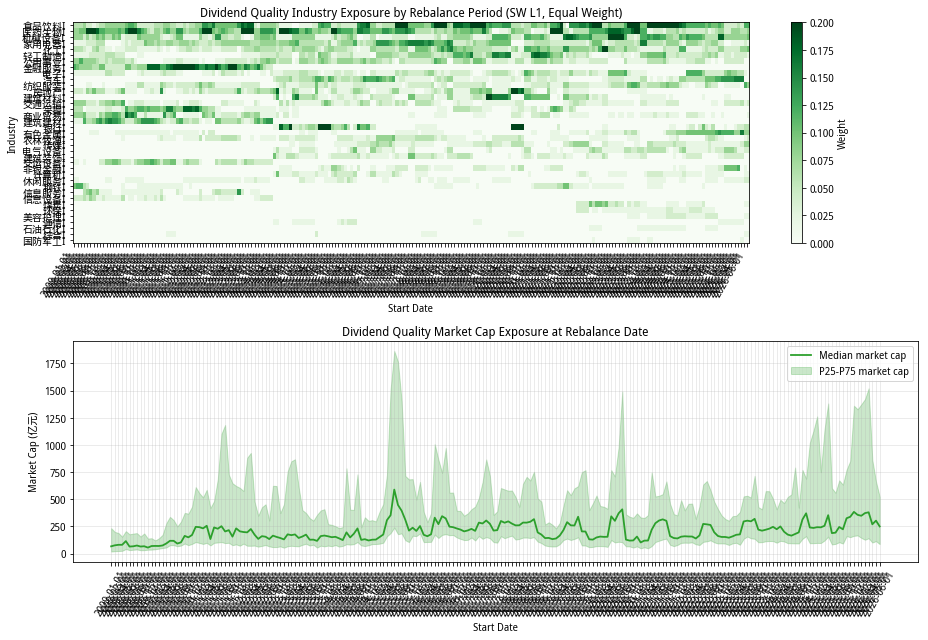

In [4]:
# ============================================================
# 红利质量行业与市值暴露分析
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def hq_load_pool_detail_for_exposure():
    if 'hq_pool_detail' in globals() and isinstance(hq_pool_detail, pd.DataFrame) and not hq_pool_detail.empty:
        return hq_pool_detail.copy()
    if 'HQ_DETAIL_FILE' in globals() and os.path.exists(HQ_DETAIL_FILE):
        return pd.read_csv(HQ_DETAIL_FILE)
    return pd.read_csv('all_a_hq_monthly_indcap20_pool_detail_20090101_20260601.csv')


def hq_exp_instrument_to_jq(instrument):
    market, num = instrument.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return instrument


def hq_exp_get_industry_name(industry_info, code, industry_type='sw_l1'):
    info = industry_info.get(code, {}) if isinstance(industry_info, dict) else {}
    node = info.get(industry_type, {}) if isinstance(info, dict) else {}
    return node.get('industry_name', 'Unknown') if isinstance(node, dict) else 'Unknown'


hq_pool_exp = hq_load_pool_detail_for_exposure()
hq_pool_exp = hq_pool_exp.sort_values(['start_date', 'instrument']).copy()
hq_pool_exp['jq_code'] = hq_pool_exp['instrument'].map(hq_exp_instrument_to_jq)

hq_industry_rows = []
hq_market_cap_rows = []
hq_period_keys = hq_pool_exp[['select_date', 'start_date', 'end_date']].drop_duplicates().sort_values(['start_date'])

for _, period in hq_period_keys.iterrows():
    select_date = period['select_date']
    start_date = period['start_date']
    end_date = period['end_date']
    holdings = hq_pool_exp[(hq_pool_exp['start_date'] == start_date) & (hq_pool_exp['end_date'] == end_date)].copy()
    codes = holdings['jq_code'].tolist()

    if 'industry' not in holdings.columns or holdings['industry'].isna().all():
        industry_info = get_industry(codes, date=select_date)
        holdings['industry'] = [hq_exp_get_industry_name(industry_info, code, industry_type='sw_l1') for code in codes]

    if 'market_cap' not in holdings.columns or holdings['market_cap'].isna().all():
        val = get_valuation(codes, end_date=select_date, count=1, fields=['market_cap'])
        val = val.sort_values(['code', 'day']).groupby('code', as_index=False).tail(1)
        market_cap = val.set_index('code')['market_cap'].astype(float)
        holdings['market_cap'] = holdings['jq_code'].map(market_cap)

    n = len(holdings)
    industry_counts = holdings['industry'].value_counts().sort_values(ascending=False)
    for industry_name, count in industry_counts.items():
        hq_industry_rows.append({
            'select_date': select_date,
            'start_date': start_date,
            'end_date': end_date,
            'industry': industry_name,
            'count': int(count),
            'weight': count / n if n else np.nan,
        })

    hq_market_cap_rows.append({
        'select_date': select_date,
        'start_date': start_date,
        'end_date': end_date,
        'stocks': n,
        'market_cap_mean': holdings['market_cap'].mean(),
        'market_cap_median': holdings['market_cap'].median(),
        'market_cap_p25': holdings['market_cap'].quantile(0.25),
        'market_cap_p75': holdings['market_cap'].quantile(0.75),
        'market_cap_min': holdings['market_cap'].min(),
        'market_cap_max': holdings['market_cap'].max(),
        'top_industry': industry_counts.index[0] if len(industry_counts) else 'Unknown',
        'top_industry_weight': industry_counts.iloc[0] / n if n and len(industry_counts) else np.nan,
        'top3_industry_weight': industry_counts.head(3).sum() / n if n else np.nan,
    })

hq_industry_exposure = pd.DataFrame(hq_industry_rows)
hq_market_cap_exposure = pd.DataFrame(hq_market_cap_rows)

print('红利质量市值暴露统计')
display(hq_market_cap_exposure)

print('红利质量行业暴露预览')
display(hq_industry_exposure.sort_values(['start_date', 'weight'], ascending=[True, False]).head(20))

hq_industry_pivot = hq_industry_exposure.pivot(index='start_date', columns='industry', values='weight').fillna(0)
hq_industry_pivot = hq_industry_pivot.loc[:, hq_industry_pivot.mean().sort_values(ascending=False).index]

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

im = axes[0].imshow(hq_industry_pivot.T.values, aspect='auto', cmap='Greens', vmin=0, vmax=max(0.01, hq_industry_pivot.values.max()))
axes[0].set_title('Dividend Quality Industry Exposure by Rebalance Period (SW L1, Equal Weight)')
axes[0].set_yticks(range(len(hq_industry_pivot.columns)))
axes[0].set_yticklabels(hq_industry_pivot.columns)
axes[0].set_xticks(range(len(hq_industry_pivot.index)))
axes[0].set_xticklabels(hq_industry_pivot.index, rotation=60, ha='right')
axes[0].set_xlabel('Start Date')
axes[0].set_ylabel('Industry')
fig.colorbar(im, ax=axes[0], label='Weight')

axes[1].plot(hq_market_cap_exposure['start_date'], hq_market_cap_exposure['market_cap_median'], label='Median market cap', linewidth=1.8, color='#2ca02c')
axes[1].fill_between(
    hq_market_cap_exposure['start_date'],
    hq_market_cap_exposure['market_cap_p25'],
    hq_market_cap_exposure['market_cap_p75'],
    alpha=0.25,
    label='P25-P75 market cap',
    color='#2ca02c',
)
axes[1].set_title('Dividend Quality Market Cap Exposure at Rebalance Date')
axes[1].set_ylabel('Market Cap (亿元)')
axes[1].set_xlabel('Start Date')
axes[1].tick_params(axis='x', rotation=60)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()


In [2]:
# ============================================================
# 红利低波 x 红利质量混合动态股票池构建 - 聚宽研究环境
# 构建区间: 2009-01-01 ~ 2026-06-01
# 输出: all_a_hybrid_hldb_hq_monthly_indcap20_pool_20090101_20260601.csv
# ============================================================

import math
import time
from datetime import timedelta

import numpy as np
import pandas as pd

try:
    from jqdata import *
    from jqdata import finance
except ImportError:
    pass

try:
    from jqfactor import get_factor_values
except ImportError:
    pass

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

# ------------------------ 配置 ------------------------
HYBRID_START_DATE = '2009-01-01'
HYBRID_END_DATE = '2026-06-01'
HYBRID_OUTPUT_FILE = 'all_a_hybrid_hldb_hq_monthly_indcap20_pool_20090101_20260601.csv'
HYBRID_DETAIL_FILE = 'all_a_hybrid_hldb_hq_monthly_indcap20_pool_detail_20090101_20260601.csv'

HYBRID_MIN_LISTING_TRADE_DAYS = 250
HYBRID_FINAL_SELECT_N = 50
HYBRID_INDUSTRY_CAP = 0.20
HYBRID_INDUSTRY_TYPE = 'sw_l1'
HYBRID_DIVIDEND_AMOUNT_TO_YIYUAN = 10000

# 风格约束：3% 用于核心层，2% 用于补位层；最后兜底仅用于保证每期满 50 只。
HYBRID_CORE_MIN_DIVIDEND_YIELD = 0.03
HYBRID_FLOOR_MIN_DIVIDEND_YIELD = 0.02
HYBRID_LOW_BETA_TOP_PCT = 0.50

# 综合分数权重：数值越低越好。
HYBRID_W_DIVIDEND = 0.35
HYBRID_W_LOW_BETA = 0.25
HYBRID_W_QUALITY = 0.30
HYBRID_W_VALUATION = 0.10


def hybrid_log(message):
    print(time.strftime('%H:%M:%S'), message, flush=True)


def hybrid_progress_iter(iterable, total=None, desc=None):
    if tqdm is not None:
        return tqdm(iterable, total=total, desc=desc)
    return iterable


def hybrid_jq_to_instrument(code):
    num, exchange = code.split('.')
    if exchange == 'XSHG':
        return 'sh.' + num
    if exchange == 'XSHE':
        return 'sz.' + num
    return code.lower()


def hybrid_previous_trade_day(date_like):
    day = pd.Timestamp(date_like).date()
    trade_days = get_trade_days(end_date=day, count=1)
    if len(trade_days) == 0:
        raise ValueError('无法找到 {} 之前的交易日'.format(day))
    return pd.Timestamp(trade_days[-1]).date()


def hybrid_first_day_next_month(day):
    if day.month == 12:
        return pd.Timestamp(year=day.year + 1, month=1, day=1).date()
    return pd.Timestamp(year=day.year, month=day.month + 1, day=1).date()


def hybrid_make_monthly_periods(start_date=HYBRID_START_DATE, end_date=HYBRID_END_DATE):
    start = pd.Timestamp(start_date).date()
    end = pd.Timestamp(end_date).date()
    periods = []
    period_start = start
    while period_start <= end:
        next_start = hybrid_first_day_next_month(period_start)
        period_end = min(next_start - timedelta(days=1), end)
        select_date = hybrid_previous_trade_day(period_start - timedelta(days=1))
        periods.append({'select_date': select_date, 'start_date': period_start, 'end_date': period_end})
        period_start = next_start
    return periods


def hybrid_filter_code_board(stocks):
    result = []
    for code in stocks:
        num, exchange = code.split('.')
        if exchange in ('XBJE', 'XBEI'):
            continue
        if exchange == 'XSHG' and num.startswith('68'):
            continue
        if exchange == 'XSHE' and (num.startswith('30') or num.startswith('4') or num.startswith('8')):
            continue
        if num.startswith('4') or num.startswith('8'):
            continue
        result.append(code)
    return result


def hybrid_filter_listing_days(stocks, select_date, min_days=HYBRID_MIN_LISTING_TRADE_DAYS):
    if not stocks:
        return []
    all_sec = get_all_securities(['stock'], date=select_date)
    trade_days = list(get_trade_days(end_date=select_date, count=min_days + 1))
    if len(trade_days) <= min_days:
        raise ValueError('无法取得足够交易日用于上市天数过滤: {}'.format(select_date))
    listing_cutoff = pd.Timestamp(trade_days[0]).date()
    result = []
    for code in stocks:
        if code not in all_sec.index:
            continue
        start_date = pd.Timestamp(all_sec.loc[code, 'start_date']).date()
        if start_date <= listing_cutoff:
            result.append(code)
    return result


def hybrid_filter_st(stocks, select_date):
    if not stocks:
        return []
    st_df = get_extras('is_st', stocks, start_date=select_date, end_date=select_date, df=True)
    if st_df is None or st_df.empty:
        return stocks
    st_row = st_df.iloc[-1].fillna(True)
    return [code for code in stocks if code in st_row.index and not bool(st_row[code])]


def hybrid_paused_series_from_price(price_data, stocks):
    if price_data is None:
        return pd.Series(True, index=stocks)
    if isinstance(price_data, pd.DataFrame):
        if {'code', 'paused'}.issubset(price_data.columns):
            return price_data.groupby('code')['paused'].last().reindex(stocks).fillna(1).astype(bool)
        if 'paused' in price_data.columns and len(stocks) == 1:
            return pd.Series({stocks[0]: bool(price_data['paused'].iloc[-1])})
        if set(stocks).issubset(set(price_data.columns)):
            return price_data.iloc[-1].reindex(stocks).fillna(1).astype(bool)
    if isinstance(price_data, dict) and 'paused' in price_data:
        paused = price_data['paused']
        if isinstance(paused, pd.DataFrame):
            return paused.iloc[-1].reindex(stocks).fillna(1).astype(bool)
    try:
        paused = price_data['paused']
        if isinstance(paused, pd.DataFrame):
            return paused.iloc[-1].reindex(stocks).fillna(1).astype(bool)
    except Exception:
        pass
    raise TypeError('无法解析 get_price 返回结构: {}'.format(type(price_data)))


def hybrid_filter_paused(stocks, select_date):
    if not stocks:
        return []
    price_data = get_price(
        stocks,
        start_date=select_date,
        end_date=select_date,
        frequency='daily',
        fields=['paused'],
        panel=False,
        fill_paused=True,
    )
    paused = hybrid_paused_series_from_price(price_data, stocks)
    return [code for code in stocks if code in paused.index and not bool(paused.loc[code])]


def hybrid_build_base_universe(select_date):
    all_sec = get_all_securities(['stock'], date=select_date)
    stocks = list(all_sec.index)
    n0 = len(stocks)
    stocks = hybrid_filter_code_board(stocks)
    n1 = len(stocks)
    stocks = hybrid_filter_listing_days(stocks, select_date)
    n2 = len(stocks)
    stocks = hybrid_filter_st(stocks, select_date)
    n3 = len(stocks)
    stocks = hybrid_filter_paused(stocks, select_date)
    n4 = len(stocks)
    return stocks, {
        'base_universe': n0,
        'after_board_filter': n1,
        'after_listing_filter': n2,
        'after_st_filter': n3,
        'after_paused_filter': n4,
    }


def hybrid_get_market_cap(stocks, select_date):
    if not stocks:
        return pd.Series(dtype=float, name='market_cap')
    val = get_valuation(stocks, end_date=select_date, count=1, fields=['market_cap'])
    if val is None or val.empty:
        return pd.Series(dtype=float, name='market_cap')
    val = val.sort_values(['code', 'day']).groupby('code', as_index=False).tail(1)
    return val.set_index('code')['market_cap'].astype(float).rename('market_cap')


def hybrid_get_dividend_cash(stocks, select_date):
    if not stocks:
        return pd.Series(dtype=float, name='dividend_cash_yiyuan')
    lookback_start = (pd.Timestamp(select_date) - pd.DateOffset(years=1)).date()
    q = query(
        finance.STK_XR_XD.code,
        finance.STK_XR_XD.board_plan_pub_date,
        finance.STK_XR_XD.a_registration_date,
        finance.STK_XR_XD.bonus_amount_rmb,
    ).filter(
        finance.STK_XR_XD.code.in_(stocks),
        finance.STK_XR_XD.board_plan_pub_date <= select_date,
        finance.STK_XR_XD.a_registration_date >= lookback_start,
        finance.STK_XR_XD.a_registration_date <= select_date,
    )
    div = finance.run_query(q)
    if div is None or div.empty:
        return pd.Series(0.0, index=stocks, name='dividend_cash_yiyuan')
    div['bonus_amount_rmb'] = pd.to_numeric(div['bonus_amount_rmb'], errors='coerce').fillna(0.0)
    cash = div.groupby('code')['bonus_amount_rmb'].sum() / HYBRID_DIVIDEND_AMOUNT_TO_YIYUAN
    return cash.reindex(stocks).fillna(0.0).rename('dividend_cash_yiyuan')


def hybrid_get_beta(stocks, select_date):
    if not stocks:
        return pd.Series(dtype=float, name='beta')
    factor_data = get_factor_values(
        securities=stocks,
        factors=['beta'],
        start_date=select_date,
        end_date=select_date,
    )
    beta_df = factor_data['beta']
    return beta_df.iloc[-1].reindex(stocks).astype(float).rename('beta')


def hybrid_get_quality_fundamentals(stocks, select_date):
    columns = [
        'pe_ratio', 'inc_return',
        'inc_total_revenue_year_on_year', 'inc_net_profit_year_on_year'
    ]
    if not stocks:
        return pd.DataFrame(columns=columns)
    q = query(
        valuation.code,
        valuation.pe_ratio,
        indicator.inc_return,
        indicator.inc_total_revenue_year_on_year,
        indicator.inc_net_profit_year_on_year,
    ).filter(valuation.code.in_(stocks))
    df = get_fundamentals(q, date=select_date)
    if df is None or df.empty:
        return pd.DataFrame(columns=columns)
    df = df.drop_duplicates('code').set_index('code')
    for col in columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df[columns]


def hybrid_get_industry_name(industry_info, code, industry_type=HYBRID_INDUSTRY_TYPE):
    info = industry_info.get(code, {}) if isinstance(industry_info, dict) else {}
    node = info.get(industry_type, {}) if isinstance(info, dict) else {}
    if isinstance(node, dict) and node.get('industry_name'):
        return node.get('industry_name')
    fallback = info.get('jq_l1', {}) if isinstance(info, dict) else {}
    if isinstance(fallback, dict) and fallback.get('industry_name'):
        return fallback.get('industry_name')
    return 'Unknown'


def hybrid_get_industry_series(stocks, select_date, industry_type=HYBRID_INDUSTRY_TYPE):
    if not stocks:
        return pd.Series(dtype=object, name='industry')
    industry_info = get_industry(stocks, date=select_date)
    values = [hybrid_get_industry_name(industry_info, code, industry_type=industry_type) for code in stocks]
    return pd.Series(values, index=stocks, name='industry')


def hybrid_industry_cap_count(n=HYBRID_FINAL_SELECT_N, cap=HYBRID_INDUSTRY_CAP):
    return max(1, int(math.floor(n * cap + 1e-9)))


def hybrid_take_unique_with_industry_cap(frames, n=HYBRID_FINAL_SELECT_N, cap=HYBRID_INDUSTRY_CAP):
    selected_parts = []
    used = set()
    industry_counts = {}
    cap_n = hybrid_industry_cap_count(n=n, cap=cap)

    for frame in frames:
        if frame is None or frame.empty:
            continue
        for code in frame.index:
            if code in used:
                continue
            row = frame.loc[[code]].copy()
            industry = row['industry'].iloc[0] if 'industry' in row.columns else 'Unknown'
            if industry_counts.get(industry, 0) >= cap_n:
                continue
            selected_parts.append(row)
            used.add(code)
            industry_counts[industry] = industry_counts.get(industry, 0) + 1
            if len(selected_parts) >= n:
                break
        if len(selected_parts) >= n:
            break

    if not selected_parts:
        return pd.DataFrame()
    return pd.concat(selected_parts, axis=0, sort=False).head(n)


def hybrid_add_scores(frame):
    frame = frame.copy()
    frame['strict_quality_filter'] = (
        frame['pe_ratio'].between(5, 50)
        & frame['inc_return'].between(5, 100)
        & frame['inc_total_revenue_year_on_year'].between(5, 100)
        & frame['inc_net_profit_year_on_year'].between(10, 100)
    )
    frame['relaxed_quality_filter'] = (
        frame['pe_ratio'].between(3, 80)
        & frame['inc_return'].between(0, 150)
        & frame['inc_total_revenue_year_on_year'].between(0, 150)
        & frame['inc_net_profit_year_on_year'].between(0, 200)
    )
    frame['dividend_rank_pct'] = frame['dividend_yield'].rank(ascending=False, pct=True, method='first')
    frame['beta_rank_pct'] = frame['beta'].rank(ascending=True, pct=True, method='first')
    frame['roe_growth_rank_pct'] = frame['inc_return'].rank(ascending=False, pct=True, method='first')
    frame['revenue_growth_rank_pct'] = frame['inc_total_revenue_year_on_year'].rank(ascending=False, pct=True, method='first')
    frame['profit_growth_rank_pct'] = frame['inc_net_profit_year_on_year'].rank(ascending=False, pct=True, method='first')
    frame['pe_rank_pct'] = frame['pe_ratio'].rank(ascending=True, pct=True, method='first')
    frame['quality_rank_pct'] = (
        frame['roe_growth_rank_pct'] * 0.40
        + frame['profit_growth_rank_pct'] * 0.35
        + frame['revenue_growth_rank_pct'] * 0.25
    )
    frame['hybrid_score'] = (
        frame['dividend_rank_pct'] * HYBRID_W_DIVIDEND
        + frame['beta_rank_pct'] * HYBRID_W_LOW_BETA
        + frame['quality_rank_pct'] * HYBRID_W_QUALITY
        + frame['pe_rank_pct'] * HYBRID_W_VALUATION
    )
    return frame


def hybrid_select(frame):
    frame = hybrid_add_scores(frame)
    order_cols = ['hybrid_score', 'dividend_rank_pct', 'beta_rank_pct', 'quality_rank_pct', 'pe_rank_pct']

    strict_core = frame[
        (frame['dividend_yield'] >= HYBRID_CORE_MIN_DIVIDEND_YIELD)
        & (frame['beta_rank_pct'] <= HYBRID_LOW_BETA_TOP_PCT)
        & frame['strict_quality_filter']
    ].sort_values(order_cols).copy()
    strict_core['selection_tier'] = 'strict_high_dividend_low_beta_quality'

    style_core = frame[
        (frame['dividend_yield'] >= HYBRID_CORE_MIN_DIVIDEND_YIELD)
        & (frame['beta_rank_pct'] <= HYBRID_LOW_BETA_TOP_PCT)
        & frame['relaxed_quality_filter']
    ].sort_values(order_cols).copy()
    style_core['selection_tier'] = 'fill_high_dividend_low_beta_relaxed_quality'

    high_div_quality = frame[
        (frame['dividend_yield'] >= HYBRID_CORE_MIN_DIVIDEND_YIELD)
        & frame['relaxed_quality_filter']
    ].sort_values(order_cols).copy()
    high_div_quality['selection_tier'] = 'fill_high_dividend_relaxed_quality'

    dividend_floor = frame[
        frame['dividend_yield'] >= HYBRID_FLOOR_MIN_DIVIDEND_YIELD
    ].sort_values(order_cols).copy()
    dividend_floor['selection_tier'] = 'fill_dividend_floor_hybrid_score'

    full_rank = frame.sort_values(order_cols).copy()
    full_rank['selection_tier'] = 'fill_full_hybrid_score'

    selected = hybrid_take_unique_with_industry_cap(
        [strict_core, style_core, high_div_quality, dividend_floor, full_rank],
        HYBRID_FINAL_SELECT_N,
        HYBRID_INDUSTRY_CAP,
    )
    return selected, frame, strict_core, style_core, high_div_quality, dividend_floor


def hybrid_build_one_period(period):
    select_date = period['select_date']
    base_stocks, counts = hybrid_build_base_universe(select_date)

    quality = hybrid_get_quality_fundamentals(base_stocks, select_date)
    candidate_stocks = list(quality.index)
    market_cap = hybrid_get_market_cap(candidate_stocks, select_date)
    dividend_cash = hybrid_get_dividend_cash(candidate_stocks, select_date)
    beta = hybrid_get_beta(candidate_stocks, select_date)
    industry = hybrid_get_industry_series(candidate_stocks, select_date)

    frame = pd.concat([quality, market_cap, dividend_cash, beta, industry], axis=1)
    frame['dividend_yield'] = frame['dividend_cash_yiyuan'] / frame['market_cap']
    frame = frame.replace([float('inf'), float('-inf')], np.nan).dropna(
        subset=[
            'pe_ratio', 'inc_return', 'inc_total_revenue_year_on_year',
            'inc_net_profit_year_on_year', 'market_cap', 'dividend_yield', 'beta'
        ]
    )
    frame = frame[frame['market_cap'] > 0].copy()

    selected, scored, strict_core, style_core, high_div_quality, dividend_floor = hybrid_select(frame)
    if len(selected) != HYBRID_FINAL_SELECT_N:
        raise ValueError(
            '调池日 {} 候选 {} 只，但只选出 {} 只'.format(select_date, len(scored), len(selected))
        )

    selected['instrument'] = [hybrid_jq_to_instrument(code) for code in selected.index]
    selected['start_date'] = pd.Timestamp(period['start_date']).strftime('%Y-%m-%d')
    selected['end_date'] = pd.Timestamp(period['end_date']).strftime('%Y-%m-%d')
    selected['select_date'] = pd.Timestamp(select_date).strftime('%Y-%m-%d')

    tier_counts = selected['selection_tier'].value_counts().to_dict() if len(selected) else {}
    industry_counts = selected['industry'].value_counts() if len(selected) else pd.Series(dtype=int)
    stats = dict(counts)
    stats.update({
        'select_date': pd.Timestamp(select_date).strftime('%Y-%m-%d'),
        'start_date': pd.Timestamp(period['start_date']).strftime('%Y-%m-%d'),
        'end_date': pd.Timestamp(period['end_date']).strftime('%Y-%m-%d'),
        'candidate_count': len(scored),
        'strict_quality_count': int(scored['strict_quality_filter'].sum()) if len(scored) else 0,
        'relaxed_quality_count': int(scored['relaxed_quality_filter'].sum()) if len(scored) else 0,
        'strict_core_stage': len(strict_core),
        'style_core_stage': len(style_core),
        'high_div_quality_stage': len(high_div_quality),
        'dividend_floor_stage': len(dividend_floor),
        'selected': len(selected),
        'industry_cap_count': hybrid_industry_cap_count(),
        'max_industry_count': int(industry_counts.max()) if len(industry_counts) else 0,
        'max_industry_weight': industry_counts.max() / float(HYBRID_FINAL_SELECT_N) if len(industry_counts) else np.nan,
        'top_industry': industry_counts.index[0] if len(industry_counts) else None,
        'median_dividend_yield': selected['dividend_yield'].median() if len(selected) else np.nan,
        'median_beta': selected['beta'].median() if len(selected) else np.nan,
        'median_pe_ratio': selected['pe_ratio'].median() if len(selected) else np.nan,
        'median_inc_return': selected['inc_return'].median() if len(selected) else np.nan,
        'median_inc_total_revenue_yoy': selected['inc_total_revenue_year_on_year'].median() if len(selected) else np.nan,
        'median_inc_net_profit_yoy': selected['inc_net_profit_year_on_year'].median() if len(selected) else np.nan,
        'median_hybrid_score': selected['hybrid_score'].median() if len(selected) else np.nan,
        'gt_3pct_count': int((selected['dividend_yield'] >= HYBRID_CORE_MIN_DIVIDEND_YIELD).sum()) if len(selected) else 0,
        'gt_2pct_count': int((selected['dividend_yield'] >= HYBRID_FLOOR_MIN_DIVIDEND_YIELD).sum()) if len(selected) else 0,
        'low_beta_count': int((selected['beta_rank_pct'] <= HYBRID_LOW_BETA_TOP_PCT).sum()) if len(selected) else 0,
        'strict_quality_selected_count': int(selected['strict_quality_filter'].sum()) if len(selected) else 0,
        'relaxed_quality_selected_count': int(selected['relaxed_quality_filter'].sum()) if len(selected) else 0,
        'strict_high_dividend_low_beta_quality_count': tier_counts.get('strict_high_dividend_low_beta_quality', 0),
        'fill_high_dividend_low_beta_relaxed_quality_count': tier_counts.get('fill_high_dividend_low_beta_relaxed_quality', 0),
        'fill_high_dividend_relaxed_quality_count': tier_counts.get('fill_high_dividend_relaxed_quality', 0),
        'fill_dividend_floor_hybrid_score_count': tier_counts.get('fill_dividend_floor_hybrid_score', 0),
        'fill_full_hybrid_score_count': tier_counts.get('fill_full_hybrid_score', 0),
    })
    return selected, stats


hybrid_periods = hybrid_make_monthly_periods(HYBRID_START_DATE, HYBRID_END_DATE)
hybrid_all_details = []
hybrid_all_stats = []

for period in hybrid_progress_iter(hybrid_periods, total=len(hybrid_periods), desc='构建红利低波x质量混合池'):
    detail, stats = hybrid_build_one_period(period)
    hybrid_all_details.append(detail)
    hybrid_all_stats.append(stats)

hybrid_pool_detail = pd.concat(hybrid_all_details, axis=0).reset_index().rename(columns={'index': 'jq_code'})
hybrid_pool = hybrid_pool_detail[['instrument', 'start_date', 'end_date', 'select_date']].copy()
hybrid_stats_df = pd.DataFrame(hybrid_all_stats)

hybrid_pool.to_csv(HYBRID_OUTPUT_FILE, index=False, encoding='utf-8')
hybrid_pool_detail.to_csv(HYBRID_DETAIL_FILE, index=False, encoding='utf-8')

print('红利低波x质量混合池构建完成')
print('输出文件:')
print('  {}'.format(HYBRID_OUTPUT_FILE))
print('  {}'.format(HYBRID_DETAIL_FILE))
print('总记录数:', len(hybrid_pool))
print('调池期数:', len(hybrid_stats_df))

assert hybrid_stats_df['selected'].eq(HYBRID_FINAL_SELECT_N).all(), '存在未选满 {} 只的调池期。'.format(HYBRID_FINAL_SELECT_N)
assert hybrid_stats_df['max_industry_count'].le(hybrid_industry_cap_count()).all(), '存在行业持仓数超过上限的调池期。'

hybrid_stats_df


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:411: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:411: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:411: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.

/opt/conda/lib/python3

红利低波x质量混合池构建完成
输出文件:
  all_a_hybrid_hldb_hq_monthly_indcap20_pool_20090101_20260601.csv
  all_a_hybrid_hldb_hq_monthly_indcap20_pool_detail_20090101_20260601.csv
总记录数: 10500
调池期数: 210


,after_board_filter,after_listing_filter,after_paused_filter,after_st_filter,base_universe,candidate_count,dividend_floor_stage,end_date,fill_dividend_floor_hybrid_score_count,fill_full_hybrid_score_count,fill_high_dividend_low_beta_relaxed_quality_count,fill_high_dividend_relaxed_quality_count,gt_2pct_count,gt_3pct_count,high_div_quality_stage,industry_cap_count,low_beta_count,max_industry_count,max_industry_weight,median_beta,median_dividend_yield,median_hybrid_score,median_inc_net_profit_yoy,median_inc_return,median_inc_total_revenue_yoy,median_pe_ratio,relaxed_quality_count,relaxed_quality_selected_count,select_date,selected,start_date,strict_core_stage,strict_high_dividend_low_beta_quality_count,strict_quality_count,strict_quality_selected_count,style_core_stage,top_industry
0,1605,1524,1329,1361,1605,338,79,2009-01-31,36,0,7,5,50,30,14,10,36,7,0.14,0.149200,0.037543,0.281775,15.910,2.915,23.975,11.67215,85,24,2008-12-31,50,2009-01-01,2,2,16,7,9,交通运输I
1,1605,1530,1354,1369,1605,344,62,2009-02-28,37,0,5,5,50,33,13,10,31,7,0.14,0.169637,0.031580,0.293089,-8.255,2.650,20.695,14.24650,84,19,2009-01-23,50,2009-02-01,3,3,19,9,8,交通运输I
2,1605,1544,1360,1384,1605,341,56,2009-03-31,39,0,4,4,50,26,11,10,29,7,0.14,0.176760,0.031115,0.287859,-12.265,2.080,19.075,17.33215,77,16,2009-02-27,50,2009-03-01,3,3,18,8,7,交通运输I
3,1605,1550,1357,1390,1605,341,44,2009-04-30,41,6,2,1,44,20,3,10,29,6,0.12,-0.047701,0.027803,0.314054,-18.020,1.405,2.055,22.78675,53,14,2009-03-31,50,2009-04-01,0,0,8,1,2,钢铁I
4,1605,1552,1340,1380,1605,338,35,2009-05-31,33,15,2,0,35,16,2,10,31,7,0.14,-0.301723,0.021818,0.254549,-2.090,2.215,-4.880,24.20305,50,15,2009-04-30,50,2009-05-01,0,0,8,4,2,交通运输I
5,1603,1565,1362,1395,1603,354,34,2009-06-30,33,16,1,0,34,17,1,10,34,5,0.10,-0.303483,0.023556,0.241229,0.380,2.435,-3.860,23.38200,59,13,2009-05-27,50,2009-06-01,0,0,8,3,1,钢铁I
6,1603,1579,1356,1413,1603,366,21,2009-07-31,20,29,1,0,21,8,1,10,40,6,0.12,-0.486662,0.018407,0.238996,6.700,2.695,4.170,27.25490,64,19,2009-06-30,50,2009-07-01,0,0,9,4,1,医药生物I
7,1608,1589,1386,1424,1608,377,13,2009-08-31,12,37,1,0,13,4,1,10,47,9,0.18,-0.635729,0.014229,0.227016,20.140,3.335,6.350,29.25855,66,23,2009-07-31,50,2009-08-01,0,0,9,5,1,医药生物I
8,1618,1595,1386,1431,1618,378,24,2009-09-30,22,26,2,0,24,10,2,10,40,6,0.12,-0.370345,0.018502,0.253671,24.445,3.570,9.075,24.92610,86,29,2009-08-31,50,2009-09-01,0,0,20,10,2,交通运输I
9,1630,1600,1409,1437,1630,392,24,2009-10-31,22,26,2,0,24,9,2,10,41,7,0.14,-0.379908,0.018483,0.246505,25.415,3.570,8.650,27.26060,89,26,2009-09-30,50,2009-10-01,0,0,20,8,2,公用事业I


                   start         end trade_days total_return annual_return annual_volatility max_drawdown final_nav excess_vs_510880
混合池等权         2009-01-05  2026-06-01       4226      7.35964      0.134987          0.200239    -0.377356   8.35964        0.0499143
510880 红利ETF  2009-01-05  2026-06-01       4226      2.93222     0.0850726          0.215044     -0.46564   3.93222                0


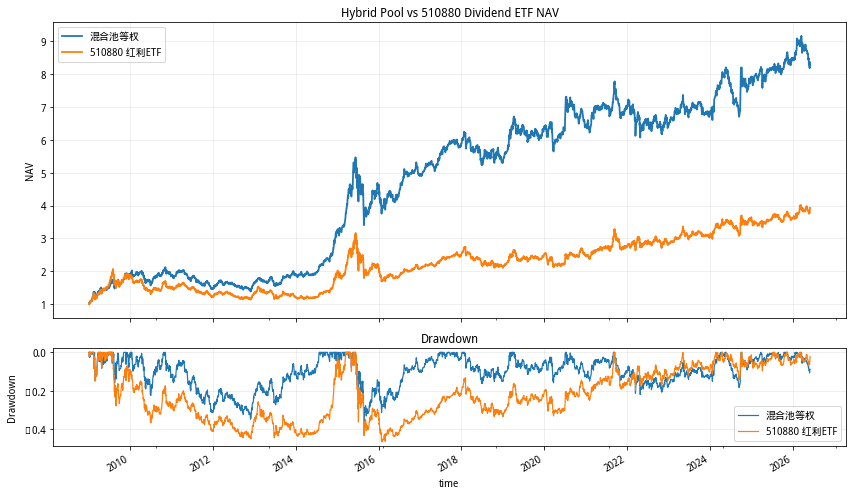

,start,end,trade_days,total_return,annual_return,annual_volatility,max_drawdown,final_nav,excess_vs_510880
混合池等权,2009-01-05,2026-06-01,4226,7.35964,0.134987,0.200239,-0.377356,8.35964,0.0499143
510880 红利ETF,2009-01-05,2026-06-01,4226,2.93222,0.0850726,0.215044,-0.46564,3.93222,0


In [7]:
# ============================================================
# 红利低波 x 红利质量混合池等权买入表现评估：月度调仓，期内等权持有
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def hybrid_bt_instrument_to_jq(instrument):
    market, num = instrument.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return instrument


def hybrid_load_pool_for_backtest():
    if 'hybrid_pool' in globals() and isinstance(hybrid_pool, pd.DataFrame) and not hybrid_pool.empty:
        return hybrid_pool.copy()
    if 'HYBRID_OUTPUT_FILE' in globals() and os.path.exists(HYBRID_OUTPUT_FILE):
        return pd.read_csv(HYBRID_OUTPUT_FILE)
    return pd.read_csv('all_a_hybrid_hldb_hq_monthly_indcap20_pool_20090101_20260601.csv')


def hybrid_extract_close_frame(price_data, stocks):
    if price_data is None:
        return pd.DataFrame()
    if isinstance(price_data, dict) and 'close' in price_data:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)
    try:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)
    except Exception:
        pass
    if isinstance(price_data, pd.DataFrame):
        if {'code', 'close'}.issubset(price_data.columns):
            date_col = None
            for candidate in ['time', 'date', 'day']:
                if candidate in price_data.columns:
                    date_col = candidate
                    break
            if isinstance(date_col, str):
                close = price_data.pivot(index=date_col, columns='code', values='close')
            else:
                tmp = price_data.copy()
                tmp['_date'] = tmp.index
                close = tmp.pivot(index='_date', columns='code', values='close')
            return close.reindex(columns=stocks)
        if set(stocks).issubset(set(price_data.columns)):
            return price_data.reindex(columns=stocks)
    raise TypeError('无法解析 get_price 返回结构: {}'.format(type(price_data)))


def hybrid_period_equal_weight_returns(stocks, start_date, end_date):
    if not stocks:
        return pd.Series(dtype=float)
    price_data = get_price(
        stocks,
        start_date=start_date,
        end_date=end_date,
        frequency='daily',
        fields=['close'],
        panel=False,
        fill_paused=True,
    )
    close = hybrid_extract_close_frame(price_data, stocks)
    if close.empty:
        return pd.Series(dtype=float)
    close.index = pd.to_datetime(close.index)
    close = close.sort_index().dropna(how='all')
    close = close.dropna(axis=1, how='all')
    if close.empty:
        return pd.Series(dtype=float)
    close = close.ffill()
    valid = close.iloc[0].dropna().index.tolist()
    close = close[valid]
    if close.empty:
        return pd.Series(dtype=float)
    stock_nav = close.divide(close.iloc[0])
    portfolio_nav = stock_nav.mean(axis=1)
    return portfolio_nav.pct_change().fillna(0.0)


def hybrid_max_drawdown(nav):
    running_max = nav.cummax()
    drawdown = nav / running_max - 1.0
    return drawdown.min(), drawdown


hybrid_bt_pool = hybrid_load_pool_for_backtest()
hybrid_bt_pool['jq_code'] = hybrid_bt_pool['instrument'].map(hybrid_bt_instrument_to_jq)
hybrid_bt_pool['start_date'] = pd.to_datetime(hybrid_bt_pool['start_date']).dt.strftime('%Y-%m-%d')
hybrid_bt_pool['end_date'] = pd.to_datetime(hybrid_bt_pool['end_date']).dt.strftime('%Y-%m-%d')

hybrid_return_parts = []
hybrid_period_groups = hybrid_bt_pool.groupby(['start_date', 'end_date'], sort=True)

for (start_date, end_date), holdings in hybrid_period_groups:
    stocks = holdings['jq_code'].dropna().unique().tolist()
    period_returns = hybrid_period_equal_weight_returns(stocks, start_date, end_date)
    if period_returns.empty:
        continue
    hybrid_return_parts.append(period_returns)

HYBRID_BENCHMARK_CODE = '510880.XSHG'
HYBRID_BENCHMARK_NAME = '510880 红利ETF'


def hybrid_get_benchmark_nav(code, start_date, end_date):
    price_data = get_price(
        [code],
        start_date=start_date,
        end_date=end_date,
        frequency='daily',
        fields=['close'],
        panel=False,
        fill_paused=True,
    )
    close = hybrid_extract_close_frame(price_data, [code])
    if close.empty:
        return pd.Series(dtype=float)
    close.index = pd.to_datetime(close.index)
    close = close.sort_index()[code].dropna()
    if close.empty:
        return pd.Series(dtype=float)
    return (close / close.iloc[0]).rename(HYBRID_BENCHMARK_NAME)


def hybrid_perf_summary(nav, name):
    nav = nav.dropna()
    returns = nav.pct_change().fillna(0.0)
    mdd, _ = hybrid_max_drawdown(nav)
    years = len(returns) / 252.0
    return pd.Series({
        'start': nav.index.min().strftime('%Y-%m-%d'),
        'end': nav.index.max().strftime('%Y-%m-%d'),
        'trade_days': len(returns),
        'total_return': nav.iloc[-1] - 1.0,
        'annual_return': nav.iloc[-1] ** (1.0 / years) - 1.0,
        'annual_volatility': returns.std() * np.sqrt(252.0),
        'max_drawdown': mdd,
        'final_nav': nav.iloc[-1],
    }, name=name)


hybrid_daily_returns = pd.concat(hybrid_return_parts).sort_index()
hybrid_daily_returns = hybrid_daily_returns[~hybrid_daily_returns.index.duplicated(keep='first')]
hybrid_nav = (1.0 + hybrid_daily_returns).cumprod().rename('混合池等权')

hybrid_benchmark_nav = hybrid_get_benchmark_nav(
    HYBRID_BENCHMARK_CODE,
    hybrid_nav.index.min().strftime('%Y-%m-%d'),
    hybrid_nav.index.max().strftime('%Y-%m-%d'),
)

hybrid_compare_nav = pd.concat([hybrid_nav, hybrid_benchmark_nav], axis=1).dropna()
hybrid_compare_nav = hybrid_compare_nav.divide(hybrid_compare_nav.iloc[0])
hybrid_compare_returns = hybrid_compare_nav.pct_change().fillna(0.0)
hybrid_compare_drawdown = hybrid_compare_nav.divide(hybrid_compare_nav.cummax()) - 1.0

hybrid_perf = pd.concat([
    hybrid_perf_summary(hybrid_compare_nav['混合池等权'], '混合池等权'),
    hybrid_perf_summary(hybrid_compare_nav[HYBRID_BENCHMARK_NAME], HYBRID_BENCHMARK_NAME),
], axis=1).T
hybrid_perf['excess_vs_510880'] = hybrid_perf['annual_return'] - hybrid_perf.loc[HYBRID_BENCHMARK_NAME, 'annual_return']

print(hybrid_perf.to_string())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
hybrid_compare_nav.plot(
    ax=axes[0],
    color=['#1f77b4', '#ff7f0e'],
    lw=1.8,
    title='Hybrid Pool vs 510880 Dividend ETF NAV',
)
axes[0].set_ylabel('NAV')
axes[0].grid(alpha=0.25)
hybrid_compare_drawdown.plot(ax=axes[1], color=['#1f77b4', '#ff7f0e'], lw=1.2, title='Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

hybrid_perf


score source: -hybrid_score proxy
top_n: 20 cost_bps: 10.0
              start         end trade_days rebalance_count total_return annual_return annual_volatility    sharpe max_drawdown final_nav avg_one_way_turnover total_cost avg_signal_age_days avg_holdings
monthly  2009-01-05  2026-06-01       4226             210      16.1745      0.184779          0.196726   0.93927    -0.354363   17.1745             0.323094   0.135699              3.1619           20
weekly   2009-01-05  2026-06-01       4226             891      16.1295      0.184593          0.196714  0.938386    -0.344479   17.1295            0.0828498   0.147638             16.4433           20


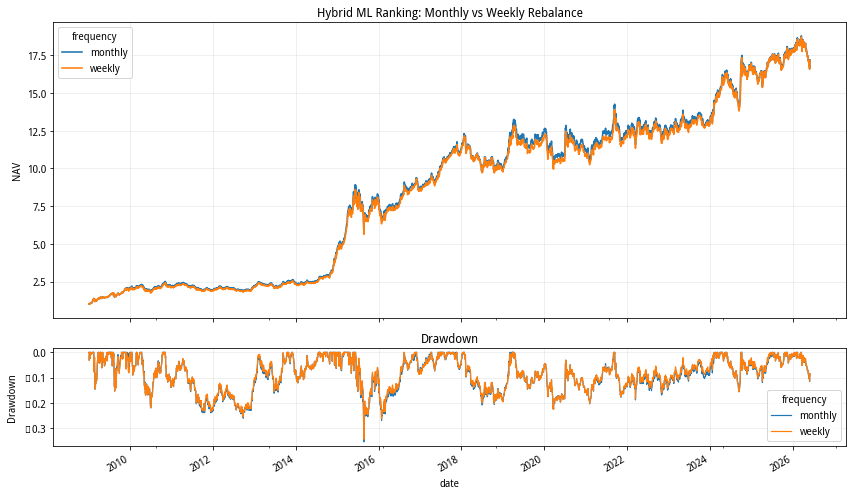

,start,end,trade_days,rebalance_count,total_return,annual_return,annual_volatility,sharpe,max_drawdown,final_nav,avg_one_way_turnover,total_cost,avg_signal_age_days,avg_holdings
monthly,2009-01-05,2026-06-01,4226,210,16.1745,0.184779,0.196726,0.93927,-0.354363,17.1745,0.323094,0.135699,3.1619,20
weekly,2009-01-05,2026-06-01,4226,891,16.1295,0.184593,0.196714,0.938386,-0.344479,17.1295,0.0828498,0.147638,16.4433,20


In [8]:
# ============================================================
# 红利低波 x 红利质量混合池：ML 月频 vs 周频调仓敏感性分析
# ============================================================
# 目的：固定“月频构建的混合池”作为交易 universe，比较 ML 排序在月频/周频交易下的表现。
# 如果环境里存在 hybrid_ml_score_df 或 ml_score_df，则使用真实 ML 分数：
#   必需字段: date, instrument, score
#   date: 信号日期；instrument: sh.600000 / sz.000001 或 600000.XSHG / 000001.XSHE；score 越大越好。
# 如果没有真实 ML 分数，则临时使用上面混合池 detail 里的 -hybrid_score 作为排序代理。

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HYBRID_FREQ_TOP_N = 20
HYBRID_FREQ_COST_BPS = 10.0
HYBRID_FREQ_LIST = ['monthly', 'weekly']
HYBRID_FREQ_MAX_SIGNAL_AGE_DAYS = 45


def hybrid_freq_to_pool_instrument(code):
    code = str(code)
    if code.endswith('.XSHG'):
        return 'sh.' + code[:6]
    if code.endswith('.XSHE'):
        return 'sz.' + code[:6]
    return code


def hybrid_freq_to_jq(code):
    code = str(code)
    if code.endswith(('.XSHG', '.XSHE')):
        return code
    if 'hybrid_bt_instrument_to_jq' in globals():
        return hybrid_bt_instrument_to_jq(code)
    market, num = code.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return code


def hybrid_freq_load_pool_detail():
    if 'hybrid_pool_detail' in globals() and isinstance(hybrid_pool_detail, pd.DataFrame) and not hybrid_pool_detail.empty:
        return hybrid_pool_detail.copy()
    if 'HYBRID_DETAIL_FILE' in globals() and os.path.exists(HYBRID_DETAIL_FILE):
        return pd.read_csv(HYBRID_DETAIL_FILE)
    return pd.read_csv('all_a_hybrid_hldb_hq_monthly_indcap20_pool_detail_20090101_20260601.csv')


def hybrid_freq_prepare_score_df():
    if 'hybrid_ml_score_df' in globals() and isinstance(hybrid_ml_score_df, pd.DataFrame) and not hybrid_ml_score_df.empty:
        score_df = hybrid_ml_score_df.copy()
        score_source = 'hybrid_ml_score_df'
    elif 'ml_score_df' in globals() and isinstance(ml_score_df, pd.DataFrame) and not ml_score_df.empty:
        score_df = ml_score_df.copy()
        score_source = 'ml_score_df'
    else:
        detail = hybrid_freq_load_pool_detail()
        if 'hybrid_score' not in detail.columns:
            raise ValueError('没有找到 ML 分数，也没有 hybrid_score 可作为排序代理。')
        date_col = 'select_date' if 'select_date' in detail.columns else 'start_date'
        score_df = detail[[date_col, 'instrument', 'hybrid_score']].copy()
        score_df = score_df.rename(columns={date_col: 'date'})
        score_df['score'] = -pd.to_numeric(score_df['hybrid_score'], errors='coerce')
        score_df = score_df[['date', 'instrument', 'score']]
        score_source = '-hybrid_score proxy'

    required = {'date', 'instrument', 'score'}
    missing = required.difference(score_df.columns)
    if missing:
        raise ValueError('score_df 缺少字段: {}'.format(sorted(missing)))
    score_df = score_df[['date', 'instrument', 'score']].copy()
    score_df['date'] = pd.to_datetime(score_df['date'])
    score_df['instrument'] = score_df['instrument'].map(hybrid_freq_to_pool_instrument)
    score_df['score'] = pd.to_numeric(score_df['score'], errors='coerce')
    score_df = score_df.dropna(subset=['date', 'instrument', 'score'])
    score_df = score_df.sort_values(['date', 'score', 'instrument'], ascending=[True, False, True])
    return score_df, score_source


def hybrid_freq_make_rebalance_dates(trading_days, frequency):
    days = pd.DatetimeIndex(pd.to_datetime(trading_days)).sort_values()
    frame = pd.DataFrame({'date': days}, index=days)
    if frequency == 'monthly':
        frame['key'] = frame.index.to_period('M').astype(str)
    elif frequency == 'weekly':
        frame['key'] = frame.index.to_period('W-SUN').astype(str)
    else:
        raise ValueError('暂不支持 frequency={}'.format(frequency))
    return pd.DatetimeIndex(frame.groupby('key')['date'].first().sort_values().values)


def hybrid_freq_active_pool(pool_df, date):
    date = pd.Timestamp(date)
    mask = (pool_df['start_date'] <= date) & (pool_df['end_date'] >= date)
    return set(pool_df.loc[mask, 'instrument'])


def hybrid_freq_latest_signal(score_df, rebalance_date, max_age_days=HYBRID_FREQ_MAX_SIGNAL_AGE_DAYS):
    rebalance_date = pd.Timestamp(rebalance_date)
    available = score_df[score_df['date'] < rebalance_date]
    if available.empty:
        return pd.DataFrame(), pd.NaT
    signal_date = available['date'].max()
    if (rebalance_date - signal_date).days > max_age_days:
        return pd.DataFrame(), signal_date
    signal = available[available['date'] == signal_date].copy()
    return signal.sort_values(['score', 'instrument'], ascending=[False, True]), signal_date


def hybrid_freq_build_targets(pool_df, score_df, trading_days, frequency, top_n):
    targets = {}
    logs = []
    rebalance_dates = hybrid_freq_make_rebalance_dates(trading_days, frequency)
    for date in rebalance_dates:
        active = hybrid_freq_active_pool(pool_df, date)
        signal, signal_date = hybrid_freq_latest_signal(score_df, date)
        candidates = signal[signal['instrument'].isin(active)].drop_duplicates('instrument', keep='first')
        selected = candidates.head(top_n)['instrument'].tolist()
        weights = pd.Series(1.0 / len(selected), index=selected) if selected else pd.Series(dtype=float)
        targets[pd.Timestamp(date)] = weights
        logs.append({
            'frequency': frequency,
            'date': pd.Timestamp(date),
            'signal_date': signal_date,
            'signal_age_days': np.nan if pd.isna(signal_date) else (pd.Timestamp(date) - signal_date).days,
            'pool_size': len(active),
            'candidate_size': len(candidates),
            'holdings': len(selected),
        })
    return targets, pd.DataFrame(logs)


def hybrid_freq_fetch_close(jq_codes, start_date, end_date):
    if not jq_codes:
        return pd.DataFrame()
    price_data = get_price(
        sorted(jq_codes),
        start_date=pd.Timestamp(start_date).strftime('%Y-%m-%d'),
        end_date=pd.Timestamp(end_date).strftime('%Y-%m-%d'),
        frequency='daily',
        fields=['close'],
        panel=False,
        fill_paused=True,
    )
    close = hybrid_extract_close_frame(price_data, sorted(jq_codes))
    if close.empty:
        return close
    close.index = pd.to_datetime(close.index)
    close = close.sort_index().dropna(how='all')
    return close.ffill()


def hybrid_freq_backtest_one(pool_df, score_df, trading_days, frequency, top_n, cost_bps):
    targets, rebalance_log = hybrid_freq_build_targets(pool_df, score_df, trading_days, frequency, top_n)
    selected_instruments = sorted(set().union(*[set(w.index) for w in targets.values()])) if targets else []
    instrument_to_jq = {instrument: hybrid_freq_to_jq(instrument) for instrument in selected_instruments}
    jq_to_instrument = {jq: instrument for instrument, jq in instrument_to_jq.items()}

    close = hybrid_freq_fetch_close(
        list(jq_to_instrument.keys()),
        trading_days.min(),
        trading_days.max(),
    )
    if close.empty:
        raise ValueError('{} 无法取得价格数据。'.format(frequency))
    close = close.rename(columns=jq_to_instrument)
    returns = close.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    returns = returns.reindex(trading_days).fillna(0.0)

    cost_rate = cost_bps / 10000.0
    current_weights = pd.Series(dtype=float)
    daily_rows = []
    log_rows = []

    for date in trading_days:
        if current_weights.empty:
            gross_return = 0.0
        else:
            available = current_weights.index.intersection(returns.columns)
            gross_return = float((current_weights.reindex(available).fillna(0.0) * returns.loc[date, available].fillna(0.0)).sum())
            if 1.0 + gross_return != 0:
                current_weights = current_weights.reindex(available).fillna(0.0) * (1.0 + returns.loc[date, available].fillna(0.0)) / (1.0 + gross_return)

        traded_notional = 0.0
        cost = 0.0
        if pd.Timestamp(date) in targets:
            target = targets[pd.Timestamp(date)]
            all_names = current_weights.index.union(target.index)
            old = current_weights.reindex(all_names).fillna(0.0)
            new = target.reindex(all_names).fillna(0.0)
            traded_notional = float((new - old).abs().sum())
            cost = traded_notional * cost_rate
            current_weights = target.copy()
            log_rows.append({
                'frequency': frequency,
                'date': pd.Timestamp(date),
                'traded_notional': traded_notional,
                'one_way_turnover': traded_notional / 2.0,
                'cost': cost,
            })

        net_return = gross_return - cost
        daily_rows.append({
            'frequency': frequency,
            'date': pd.Timestamp(date),
            'gross_return': gross_return,
            'cost': cost,
            'net_return': net_return,
            'nav': np.nan,
        })

    daily = pd.DataFrame(daily_rows).set_index('date')
    daily['nav'] = (1.0 + daily['net_return']).cumprod()
    turnover_log = pd.DataFrame(log_rows)
    if not turnover_log.empty:
        rebalance_log = rebalance_log.merge(turnover_log, on=['frequency', 'date'], how='left')
    else:
        rebalance_log['traded_notional'] = np.nan
        rebalance_log['one_way_turnover'] = np.nan
        rebalance_log['cost'] = np.nan
    rebalance_log[['traded_notional', 'one_way_turnover', 'cost']] = rebalance_log[['traded_notional', 'one_way_turnover', 'cost']].fillna(0.0)
    summary = hybrid_freq_perf_summary(daily['nav'], frequency, rebalance_log)
    return summary, daily.reset_index(), rebalance_log


def hybrid_freq_perf_summary(nav, frequency, rebalance_log):
    nav = nav.dropna()
    returns = nav.pct_change().fillna(0.0)
    mdd, _ = hybrid_max_drawdown(nav)
    years = len(returns) / 252.0
    annual_return = nav.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan
    annual_volatility = returns.std() * np.sqrt(252.0)
    return pd.Series({
        'start': nav.index.min().strftime('%Y-%m-%d'),
        'end': nav.index.max().strftime('%Y-%m-%d'),
        'trade_days': len(returns),
        'rebalance_count': len(rebalance_log),
        'total_return': nav.iloc[-1] - 1.0,
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'sharpe': annual_return / annual_volatility if annual_volatility and annual_volatility > 0 else np.nan,
        'max_drawdown': mdd,
        'final_nav': nav.iloc[-1],
        'avg_one_way_turnover': rebalance_log['one_way_turnover'].mean() if len(rebalance_log) else np.nan,
        'total_cost': rebalance_log['cost'].sum() if len(rebalance_log) else 0.0,
        'avg_signal_age_days': rebalance_log['signal_age_days'].mean() if len(rebalance_log) else np.nan,
        'avg_holdings': rebalance_log['holdings'].mean() if len(rebalance_log) else np.nan,
    }, name=frequency)


hybrid_freq_pool = hybrid_load_pool_for_backtest()[['instrument', 'start_date', 'end_date']].copy()
hybrid_freq_pool['instrument'] = hybrid_freq_pool['instrument'].map(hybrid_freq_to_pool_instrument)
hybrid_freq_pool['start_date'] = pd.to_datetime(hybrid_freq_pool['start_date'])
hybrid_freq_pool['end_date'] = pd.to_datetime(hybrid_freq_pool['end_date'])

hybrid_freq_score_df, hybrid_freq_score_source = hybrid_freq_prepare_score_df()
hybrid_freq_start = hybrid_freq_pool['start_date'].min()
hybrid_freq_end = hybrid_freq_pool['end_date'].max()
hybrid_freq_trading_days = pd.DatetimeIndex(get_trade_days(start_date=hybrid_freq_start, end_date=hybrid_freq_end))

hybrid_freq_summaries = []
hybrid_freq_nav_parts = []
hybrid_freq_log_parts = []

for hybrid_freq in HYBRID_FREQ_LIST:
    summary, daily_nav, rebalance_log = hybrid_freq_backtest_one(
        hybrid_freq_pool,
        hybrid_freq_score_df,
        hybrid_freq_trading_days,
        hybrid_freq,
        HYBRID_FREQ_TOP_N,
        HYBRID_FREQ_COST_BPS,
    )
    hybrid_freq_summaries.append(summary)
    hybrid_freq_nav_parts.append(daily_nav)
    hybrid_freq_log_parts.append(rebalance_log)

hybrid_rebalance_freq_summary = pd.concat(hybrid_freq_summaries, axis=1).T
hybrid_rebalance_freq_nav = pd.concat(hybrid_freq_nav_parts, axis=0, ignore_index=True)
hybrid_rebalance_freq_rebalance_log = pd.concat(hybrid_freq_log_parts, axis=0, ignore_index=True)

print('score source:', hybrid_freq_score_source)
print('top_n:', HYBRID_FREQ_TOP_N, 'cost_bps:', HYBRID_FREQ_COST_BPS)
print(hybrid_rebalance_freq_summary.to_string())

hybrid_freq_nav_pivot = hybrid_rebalance_freq_nav.pivot(index='date', columns='frequency', values='nav').dropna(how='all')
hybrid_freq_nav_pivot = hybrid_freq_nav_pivot.divide(hybrid_freq_nav_pivot.iloc[0])
hybrid_freq_drawdown = hybrid_freq_nav_pivot.divide(hybrid_freq_nav_pivot.cummax()) - 1.0

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
hybrid_freq_nav_pivot.plot(ax=axes[0], lw=1.6, title='Hybrid ML Ranking: Monthly vs Weekly Rebalance')
axes[0].set_ylabel('NAV')
axes[0].grid(alpha=0.25)
hybrid_freq_drawdown.plot(ax=axes[1], lw=1.2, title='Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

hybrid_rebalance_freq_summary



月频混合池成分变动率统计（首期无上一期，已自动跳过均值统计里的 NaN）
       added_count  removed_count  added_rate  removed_rate  retention_rate  one_way_turnover  symmetric_change_rate
count   209.000000     209.000000  209.000000    209.000000      209.000000        209.000000             209.000000
mean     13.712919      13.712919    0.274258      0.274258        0.725742          0.274258               0.408743
std       7.632413       7.632413    0.152648      0.152648        0.152648          0.152648               0.183635
min       1.000000       1.000000    0.020000      0.020000        0.300000          0.020000               0.039216
10%       4.000000       4.000000    0.080000      0.080000        0.516000          0.080000               0.148148
25%       7.000000       7.000000    0.140000      0.140000        0.620000          0.140000               0.245614
50%      13.000000      13.000000    0.260000      0.260000        0.740000          0.260000               0.412698
75%      19.000000      19.

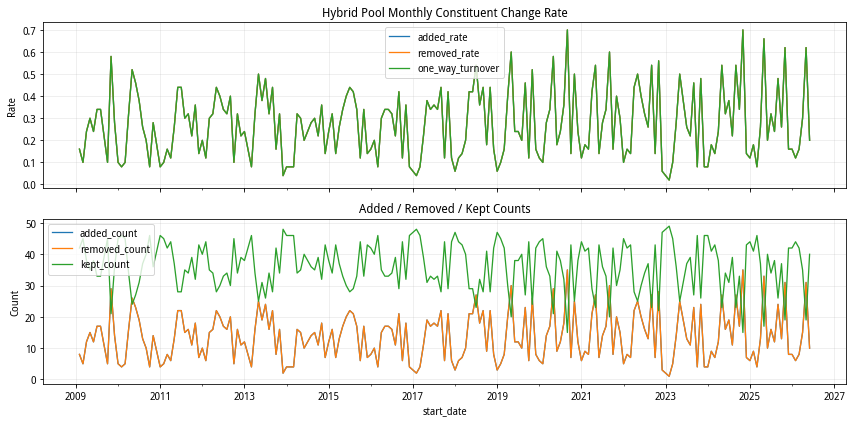

,added_count,added_rate,end_date,holdings_count,kept_count,one_way_turnover,prev_holdings_count,removed_count,removed_rate,retention_rate,start_date,symmetric_change_rate
190,35.0,0.70,2024-11-30,50,15.0,0.70,50.0,35.0,0.70,0.30,2024-11-01,0.823529
191,7.0,0.14,2024-12-31,50,43.0,0.14,50.0,7.0,0.14,0.86,2024-12-01,0.245614
192,6.0,0.12,2025-01-31,50,44.0,0.12,50.0,6.0,0.12,0.88,2025-01-01,0.214286
193,9.0,0.18,2025-02-28,50,41.0,0.18,50.0,9.0,0.18,0.82,2025-02-01,0.305085
194,4.0,0.08,2025-03-31,50,46.0,0.08,50.0,4.0,0.08,0.92,2025-03-01,0.148148
195,13.0,0.26,2025-04-30,50,37.0,0.26,50.0,13.0,0.26,0.74,2025-04-01,0.412698
196,33.0,0.66,2025-05-31,50,17.0,0.66,50.0,33.0,0.66,0.34,2025-05-01,0.795181
197,10.0,0.20,2025-06-30,50,40.0,0.20,50.0,10.0,0.20,0.80,2025-06-01,0.333333
198,16.0,0.32,2025-07-31,50,34.0,0.32,50.0,16.0,0.32,0.68,2025-07-01,0.484848
199,12.0,0.24,2025-08-31,50,38.0,0.24,50.0,12.0,0.24,0.76,2025-08-01,0.387097


In [9]:
# ============================================================
# 红利低波 x 红利质量混合池：月频成分变动率分析
# ============================================================
# 口径：比较相邻两个调池期的混合池成分。
# added_count / removed_count：本期新增 / 上期剔除数量。
# retention_rate：上期成分在本期继续保留的比例。
# one_way_turnover：等权组合从上期调到本期的单边换手率。
# symmetric_change_rate：集合对称差变动率，衡量两期成分集合差异程度。

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def hybrid_turnover_load_pool():
    if 'hybrid_pool' in globals() and isinstance(hybrid_pool, pd.DataFrame) and not hybrid_pool.empty:
        return hybrid_pool.copy()
    if 'HYBRID_OUTPUT_FILE' in globals() and os.path.exists(HYBRID_OUTPUT_FILE):
        return pd.read_csv(HYBRID_OUTPUT_FILE)
    return pd.read_csv('all_a_hybrid_hldb_hq_monthly_indcap20_pool_20090101_20260601.csv')


def hybrid_turnover_one_way(prev_set, curr_set):
    if not prev_set and not curr_set:
        return 0.0
    prev_n = len(prev_set)
    curr_n = len(curr_set)
    names = sorted(prev_set | curr_set)
    prev_w = pd.Series(0.0, index=names)
    curr_w = pd.Series(0.0, index=names)
    if prev_n > 0:
        prev_w.loc[list(prev_set)] = 1.0 / prev_n
    if curr_n > 0:
        curr_w.loc[list(curr_set)] = 1.0 / curr_n
    return float((curr_w - prev_w).abs().sum() / 2.0)


hybrid_turnover_pool = hybrid_turnover_load_pool().copy()
hybrid_turnover_pool['start_date'] = pd.to_datetime(hybrid_turnover_pool['start_date'])
hybrid_turnover_pool['end_date'] = pd.to_datetime(hybrid_turnover_pool['end_date'])
hybrid_turnover_pool = hybrid_turnover_pool.sort_values(['start_date', 'instrument'])

hybrid_period_holdings = []
for (start_date, end_date), group in hybrid_turnover_pool.groupby(['start_date', 'end_date'], sort=True):
    holdings = set(group['instrument'].dropna().astype(str))
    hybrid_period_holdings.append({
        'start_date': pd.Timestamp(start_date),
        'end_date': pd.Timestamp(end_date),
        'holdings_set': holdings,
        'holdings_count': len(holdings),
    })

hybrid_turnover_rows = []
for i, period in enumerate(hybrid_period_holdings):
    curr_set = period['holdings_set']
    if i == 0:
        hybrid_turnover_rows.append({
            'start_date': period['start_date'],
            'end_date': period['end_date'],
            'holdings_count': period['holdings_count'],
            'prev_holdings_count': np.nan,
            'kept_count': np.nan,
            'added_count': np.nan,
            'removed_count': np.nan,
            'added_rate': np.nan,
            'removed_rate': np.nan,
            'retention_rate': np.nan,
            'one_way_turnover': np.nan,
            'symmetric_change_rate': np.nan,
        })
        continue

    prev = hybrid_period_holdings[i - 1]
    prev_set = prev['holdings_set']
    kept = curr_set & prev_set
    added = curr_set - prev_set
    removed = prev_set - curr_set
    union = curr_set | prev_set

    hybrid_turnover_rows.append({
        'start_date': period['start_date'],
        'end_date': period['end_date'],
        'holdings_count': period['holdings_count'],
        'prev_holdings_count': prev['holdings_count'],
        'kept_count': len(kept),
        'added_count': len(added),
        'removed_count': len(removed),
        'added_rate': len(added) / len(curr_set) if curr_set else np.nan,
        'removed_rate': len(removed) / len(prev_set) if prev_set else np.nan,
        'retention_rate': len(kept) / len(prev_set) if prev_set else np.nan,
        'one_way_turnover': hybrid_turnover_one_way(prev_set, curr_set),
        'symmetric_change_rate': (len(added) + len(removed)) / len(union) if union else np.nan,
    })

hybrid_monthly_turnover = pd.DataFrame(hybrid_turnover_rows)

hybrid_monthly_turnover_summary = hybrid_monthly_turnover[[
    'added_count',
    'removed_count',
    'added_rate',
    'removed_rate',
    'retention_rate',
    'one_way_turnover',
    'symmetric_change_rate',
]].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

print('月频混合池成分变动率统计（首期无上一期，已自动跳过均值统计里的 NaN）')
print(hybrid_monthly_turnover_summary.to_string())
print('\n最近 12 期变动：')
print(hybrid_monthly_turnover.tail(12)[[
    'start_date',
    'holdings_count',
    'kept_count',
    'added_count',
    'removed_count',
    'retention_rate',
    'one_way_turnover',
    'symmetric_change_rate',
]].to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
hybrid_monthly_turnover.set_index('start_date')[['added_rate', 'removed_rate', 'one_way_turnover']].plot(
    ax=axes[0], lw=1.3, title='Hybrid Pool Monthly Constituent Change Rate'
)
axes[0].set_ylabel('Rate')
axes[0].grid(alpha=0.25)
hybrid_monthly_turnover.set_index('start_date')[['added_count', 'removed_count', 'kept_count']].plot(
    ax=axes[1], lw=1.3, title='Added / Removed / Kept Counts'
)
axes[1].set_ylabel('Count')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

hybrid_monthly_turnover.tail(20)



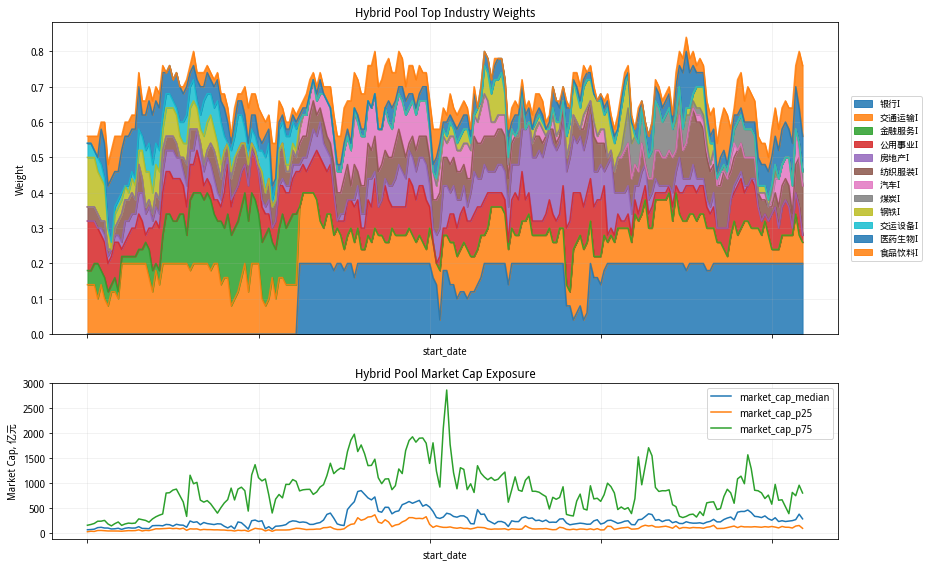

行业暴露均值 Top 12:
industry
银行I      0.184054
交通运输I    0.122952
金融服务I    0.122258
公用事业I    0.083365
房地产I     0.070898
纺织服装I    0.068571
汽车I      0.067579
煤炭I      0.061951
钢铁I      0.055345
交运设备I    0.052542
医药生物I    0.051694
食品饮料I    0.051568
Name: weight, dtype: float64

市值与行业集中度摘要:
       market_cap_median          ...           top3_industry_weight
count         210.000000          ...                     210.000000
mean          267.752065          ...                       0.433333
std           148.928436          ...                       0.051775
min            67.769750          ...                       0.280000
25%           177.315237          ...                       0.400000
50%           231.147175          ...                       0.440000
75%           311.656638          ...                       0.480000
max           849.065900          ...                       0.540000

[8 rows x 5 columns]


,end_date,market_cap_mean,market_cap_median,market_cap_p25,market_cap_p75,select_date,start_date,top3_industry_weight,top_industry,top_industry_weight
205,2026-02-28,713.066440,241.15180,116.913575,388.408950,2026-01-30,2026-02-01,0.36,银行I,0.2
206,2026-03-31,1360.480760,249.51510,102.369150,812.585925,2026-02-27,2026-03-01,0.42,银行I,0.2
207,2026-04-30,1108.694110,270.28630,141.496250,746.848525,2026-03-31,2026-04-01,0.46,银行I,0.2
208,2026-05-31,1340.398470,379.06870,152.757175,957.200775,2026-04-30,2026-05-01,0.50,银行I,0.2
209,2026-06-01,1825.030902,285.38245,96.249700,801.493275,2026-05-29,2026-06-01,0.54,食品饮料I,0.2


In [5]:
# ============================================================
# 红利低波 x 红利质量混合池行业与市值暴露分析
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def hybrid_load_pool_detail_for_exposure():
    if 'hybrid_pool_detail' in globals() and isinstance(hybrid_pool_detail, pd.DataFrame) and not hybrid_pool_detail.empty:
        return hybrid_pool_detail.copy()
    if 'HYBRID_DETAIL_FILE' in globals() and os.path.exists(HYBRID_DETAIL_FILE):
        return pd.read_csv(HYBRID_DETAIL_FILE)
    return pd.read_csv('all_a_hybrid_hldb_hq_monthly_indcap20_pool_detail_20090101_20260601.csv')


def hybrid_exp_instrument_to_jq(instrument):
    market, num = instrument.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return instrument


def hybrid_exp_get_industry_name(industry_info, code, industry_type='sw_l1'):
    info = industry_info.get(code, {}) if isinstance(industry_info, dict) else {}
    node = info.get(industry_type, {}) if isinstance(info, dict) else {}
    return node.get('industry_name', 'Unknown') if isinstance(node, dict) else 'Unknown'


hybrid_pool_exp = hybrid_load_pool_detail_for_exposure()
hybrid_pool_exp = hybrid_pool_exp.sort_values(['start_date', 'instrument']).copy()
hybrid_pool_exp['jq_code'] = hybrid_pool_exp['instrument'].map(hybrid_exp_instrument_to_jq)

hybrid_industry_rows = []
hybrid_market_cap_rows = []
hybrid_period_keys = hybrid_pool_exp[['select_date', 'start_date', 'end_date']].drop_duplicates().sort_values(['start_date'])

for _, period in hybrid_period_keys.iterrows():
    select_date = period['select_date']
    start_date = period['start_date']
    end_date = period['end_date']
    holdings = hybrid_pool_exp[(hybrid_pool_exp['start_date'] == start_date) & (hybrid_pool_exp['end_date'] == end_date)].copy()
    codes = holdings['jq_code'].tolist()

    if 'industry' not in holdings.columns or holdings['industry'].isna().all():
        industry_info = get_industry(codes, date=select_date)
        holdings['industry'] = [hybrid_exp_get_industry_name(industry_info, code) for code in codes]

    if 'market_cap' not in holdings.columns or holdings['market_cap'].isna().all():
        val = get_valuation(codes, end_date=select_date, count=1, fields=['market_cap'])
        val = val.sort_values(['code', 'day']).groupby('code', as_index=False).tail(1)
        cap = val.set_index('code')['market_cap']
        holdings['market_cap'] = holdings['jq_code'].map(cap)

    industry_weight = holdings['industry'].value_counts(normalize=True).sort_values(ascending=False)
    for industry, weight in industry_weight.items():
        hybrid_industry_rows.append({
            'select_date': select_date,
            'start_date': start_date,
            'end_date': end_date,
            'industry': industry,
            'weight': weight,
            'count': int((holdings['industry'] == industry).sum()),
        })

    market_cap = pd.to_numeric(holdings['market_cap'], errors='coerce').dropna()
    hybrid_market_cap_rows.append({
        'select_date': select_date,
        'start_date': start_date,
        'end_date': end_date,
        'market_cap_mean': market_cap.mean(),
        'market_cap_median': market_cap.median(),
        'market_cap_p25': market_cap.quantile(0.25),
        'market_cap_p75': market_cap.quantile(0.75),
        'top_industry': industry_weight.index[0] if len(industry_weight) else None,
        'top_industry_weight': industry_weight.iloc[0] if len(industry_weight) else np.nan,
        'top3_industry_weight': industry_weight.head(3).sum() if len(industry_weight) else np.nan,
    })

hybrid_industry_exposure = pd.DataFrame(hybrid_industry_rows)
hybrid_market_cap_exposure = pd.DataFrame(hybrid_market_cap_rows)

hybrid_industry_pivot = hybrid_industry_exposure.pivot_table(
    index='start_date', columns='industry', values='weight', fill_value=0.0
)
hybrid_top_industries = hybrid_industry_exposure.groupby('industry')['weight'].mean().sort_values(ascending=False).head(12).index

fig, axes = plt.subplots(2, 1, figsize=(13, 8), gridspec_kw={'height_ratios': [2, 1]})
hybrid_industry_pivot[hybrid_top_industries].plot.area(ax=axes[0], stacked=True, alpha=0.85)
axes[0].set_title('Hybrid Pool Top Industry Weights')
axes[0].set_ylabel('Weight')
axes[0].legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
axes[0].grid(alpha=0.2)

hybrid_market_cap_exposure.set_index('start_date')[['market_cap_median', 'market_cap_p25', 'market_cap_p75']].plot(ax=axes[1])
axes[1].set_title('Hybrid Pool Market Cap Exposure')
axes[1].set_ylabel('Market Cap, 亿元')
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.show()

print('行业暴露均值 Top 12:')
print(hybrid_industry_exposure.groupby('industry')['weight'].mean().sort_values(ascending=False).head(12))
print('\n市值与行业集中度摘要:')
print(hybrid_market_cap_exposure[['market_cap_median', 'market_cap_p25', 'market_cap_p75', 'top_industry_weight', 'top3_industry_weight']].describe())

hybrid_market_cap_exposure.tail()


In [6]:
# ============================================================
# 混合池导出为 qlib 股票池时点表格式
# 格式: SYMBOL<TAB>start_date<TAB>end_date，无列头
# 示例: SZ001872    2014-10-31    2015-05-28
# ============================================================

import os
import pandas as pd

HYBRID_QLIB_POOL_FILE = 'all_a_hybrid_hldb_hq_monthly_indcap20_pool_qlib_20090101_20260601.txt'


def hybrid_qlib_load_pool():
    if 'hybrid_pool' in globals() and isinstance(hybrid_pool, pd.DataFrame) and not hybrid_pool.empty:
        return hybrid_pool.copy()
    if 'HYBRID_OUTPUT_FILE' in globals() and os.path.exists(HYBRID_OUTPUT_FILE):
        return pd.read_csv(HYBRID_OUTPUT_FILE)
    return pd.read_csv('all_a_hybrid_hldb_hq_monthly_indcap20_pool_20090101_20260601.csv')


def hybrid_to_qlib_symbol(instrument):
    """sh.600000 -> SH600000; sz.000001 -> SZ000001; 600000.XSHG -> SH600000"""
    code = str(instrument).strip()
    if code.startswith('sh.'):
        return 'SH' + code.split('.')[1]
    if code.startswith('sz.'):
        return 'SZ' + code.split('.')[1]
    if code.endswith('.XSHG'):
        return 'SH' + code.split('.')[0]
    if code.endswith('.XSHE'):
        return 'SZ' + code.split('.')[0]
    return code.replace('.', '').upper()


hybrid_qlib_pool = hybrid_qlib_load_pool().copy()
hybrid_qlib_pool['instrument'] = hybrid_qlib_pool['instrument'].map(hybrid_to_qlib_symbol)
hybrid_qlib_pool['start_date'] = pd.to_datetime(hybrid_qlib_pool['start_date']).dt.strftime('%Y-%m-%d')
hybrid_qlib_pool['end_date'] = pd.to_datetime(hybrid_qlib_pool['end_date']).dt.strftime('%Y-%m-%d')

hybrid_qlib_pool = hybrid_qlib_pool[['instrument', 'start_date', 'end_date']]
hybrid_qlib_pool = hybrid_qlib_pool.sort_values(['start_date', 'instrument']).drop_duplicates()
hybrid_qlib_pool.to_csv(HYBRID_QLIB_POOL_FILE, sep='\t', index=False, header=False, encoding='utf-8')

print('qlib 股票池时点表已导出:', HYBRID_QLIB_POOL_FILE)
print('记录数:', len(hybrid_qlib_pool))
print(hybrid_qlib_pool.head(10).to_string(index=False, header=False))


qlib 股票池时点表已导出: all_a_hybrid_hldb_hq_monthly_indcap20_pool_qlib_20090101_20260601.txt
记录数: 10500
SH600004  2009-01-01  2009-01-31
SH600005  2009-01-01  2009-01-31
SH600010  2009-01-01  2009-01-31
SH600019  2009-01-01  2009-01-31
SH600022  2009-01-01  2009-01-31
SH600033  2009-01-01  2009-01-31
SH600036  2009-01-01  2009-01-31
SH600096  2009-01-01  2009-01-31
SH600098  2009-01-01  2009-01-31
SH600143  2009-01-01  2009-01-31


In [14]:
# ============================================================
# 红利低波 x 红利质量混合池：季度 / 半年调池对比 - 1. 配置与工具函数
# ============================================================
# 后续拆成多个 cell，方便分别运行和调试：
# 1. 配置与工具函数
# 2. 重建或加载季度 / 半年混合池
# 3. 成分变动率对比
# 4. 等权收益表现对比

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

HYBRID_VARIANT_FORCE_REBUILD = False
HYBRID_VARIANT_CONFIGS = [
    {'name': 'quarterly', 'label': '混合池季度调池', 'months': 3},
    {'name': 'semiannual', 'label': '混合池半年调池', 'months': 6},
]


def hybrid_variant_next_period_start(period_start, months):
    return (pd.Timestamp(period_start) + pd.DateOffset(months=months)).date()


def hybrid_make_periods_by_months(start_date=HYBRID_START_DATE, end_date=HYBRID_END_DATE, months=3):
    start = pd.Timestamp(start_date).date()
    end = pd.Timestamp(end_date).date()
    periods = []
    period_start = start
    while period_start <= end:
        next_start = hybrid_variant_next_period_start(period_start, months)
        period_end = min(next_start - timedelta(days=1), end)
        select_date = hybrid_previous_trade_day(period_start - timedelta(days=1))
        periods.append({
            'select_date': select_date,
            'start_date': period_start,
            'end_date': period_end,
        })
        period_start = next_start
    return periods


def hybrid_variant_output_files(name):
    start = pd.Timestamp(HYBRID_START_DATE).strftime('%Y%m%d')
    end = pd.Timestamp(HYBRID_END_DATE).strftime('%Y%m%d')
    return (
        'all_a_hybrid_hldb_hq_{}_indcap20_pool_{}_{}.csv'.format(name, start, end),
        'all_a_hybrid_hldb_hq_{}_indcap20_pool_detail_{}_{}.csv'.format(name, start, end),
        'all_a_hybrid_hldb_hq_{}_indcap20_stats_{}_{}.csv'.format(name, start, end),
    )


def hybrid_variant_one_way_turnover(prev_set, curr_set):
    if not prev_set and not curr_set:
        return 0.0
    names = sorted(prev_set | curr_set)
    prev_w = pd.Series(0.0, index=names)
    curr_w = pd.Series(0.0, index=names)
    if prev_set:
        prev_w.loc[list(prev_set)] = 1.0 / len(prev_set)
    if curr_set:
        curr_w.loc[list(curr_set)] = 1.0 / len(curr_set)
    return float((curr_w - prev_w).abs().sum() / 2.0)


def hybrid_variant_turnover(pool, label):
    work = pool.copy()
    work['start_date'] = pd.to_datetime(work['start_date'])
    work['end_date'] = pd.to_datetime(work['end_date'])
    work = work.sort_values(['start_date', 'instrument'])

    period_sets = []
    for (start_date, end_date), group in work.groupby(['start_date', 'end_date'], sort=True):
        holdings = set(group['instrument'].dropna().astype(str))
        period_sets.append({
            'label': label,
            'start_date': pd.Timestamp(start_date),
            'end_date': pd.Timestamp(end_date),
            'holdings_set': holdings,
            'holdings_count': len(holdings),
        })

    rows = []
    for i, period in enumerate(period_sets):
        curr_set = period['holdings_set']
        if i == 0:
            rows.append({
                'label': label,
                'start_date': period['start_date'],
                'end_date': period['end_date'],
                'holdings_count': period['holdings_count'],
                'prev_holdings_count': np.nan,
                'kept_count': np.nan,
                'added_count': np.nan,
                'removed_count': np.nan,
                'added_rate': np.nan,
                'removed_rate': np.nan,
                'retention_rate': np.nan,
                'one_way_turnover': np.nan,
                'symmetric_change_rate': np.nan,
            })
            continue

        prev_set = period_sets[i - 1]['holdings_set']
        kept = curr_set & prev_set
        added = curr_set - prev_set
        removed = prev_set - curr_set
        union = curr_set | prev_set
        rows.append({
            'label': label,
            'start_date': period['start_date'],
            'end_date': period['end_date'],
            'holdings_count': period['holdings_count'],
            'prev_holdings_count': period_sets[i - 1]['holdings_count'],
            'kept_count': len(kept),
            'added_count': len(added),
            'removed_count': len(removed),
            'added_rate': len(added) / len(curr_set) if curr_set else np.nan,
            'removed_rate': len(removed) / len(prev_set) if prev_set else np.nan,
            'retention_rate': len(kept) / len(prev_set) if prev_set else np.nan,
            'one_way_turnover': hybrid_variant_one_way_turnover(prev_set, curr_set),
            'symmetric_change_rate': (len(added) + len(removed)) / len(union) if union else np.nan,
        })
    return pd.DataFrame(rows)



In [15]:
# ============================================================
# 红利低波 x 红利质量混合池：季度 / 半年调池对比 - 2. 重建或加载股票池
# ============================================================
# 如果 CSV 已存在且 HYBRID_VARIANT_FORCE_REBUILD=False，则直接加载，避免重复跑很久。


def hybrid_build_variant_pool(config):
    periods = hybrid_make_periods_by_months(HYBRID_START_DATE, HYBRID_END_DATE, config['months'])
    details = []
    stats_rows = []

    for period in hybrid_progress_iter(periods, total=len(periods), desc='构建{}'.format(config['label'])):
        detail, stats = hybrid_build_one_period(period)
        details.append(detail)
        stats_rows.append(stats)

    pool_detail = pd.concat(details, axis=0).reset_index().rename(columns={'index': 'jq_code'})
    pool = pool_detail[['instrument', 'start_date', 'end_date', 'select_date']].copy()
    stats_df = pd.DataFrame(stats_rows)

    pool = pool.sort_values(['start_date', 'instrument']).reset_index(drop=True)
    pool_detail = pool_detail.sort_values(['start_date', 'instrument']).reset_index(drop=True)
    stats_df = stats_df.sort_values(['start_date']).reset_index(drop=True)

    output_file, detail_file, stats_file = hybrid_variant_output_files(config['name'])
    pool.to_csv(output_file, index=False, encoding='utf-8')
    pool_detail.to_csv(detail_file, index=False, encoding='utf-8')
    stats_df.to_csv(stats_file, index=False, encoding='utf-8')

    return {
        'config': config,
        'periods': periods,
        'pool': pool,
        'pool_detail': pool_detail,
        'stats': stats_df,
        'output_file': output_file,
        'detail_file': detail_file,
        'stats_file': stats_file,
    }


def hybrid_load_or_build_variant_pool(config, force_rebuild=HYBRID_VARIANT_FORCE_REBUILD):
    output_file, detail_file, stats_file = hybrid_variant_output_files(config['name'])
    if (not force_rebuild) and os.path.exists(output_file) and os.path.exists(detail_file) and os.path.exists(stats_file):
        return {
            'config': config,
            'periods': hybrid_make_periods_by_months(HYBRID_START_DATE, HYBRID_END_DATE, config['months']),
            'pool': pd.read_csv(output_file),
            'pool_detail': pd.read_csv(detail_file),
            'stats': pd.read_csv(stats_file),
            'output_file': output_file,
            'detail_file': detail_file,
            'stats_file': stats_file,
        }
    return hybrid_build_variant_pool(config)


hybrid_variant_results = {}
for config in HYBRID_VARIANT_CONFIGS:
    hybrid_variant_results[config['name']] = hybrid_load_or_build_variant_pool(config)

print('季度 / 半年混合池已准备完成：')
for result in hybrid_variant_results.values():
    print('  {}:'.format(result['config']['label']))
    print('    {}'.format(result['output_file']))
    print('    {}'.format(result['detail_file']))
    print('    {}'.format(result['stats_file']))
    print('    periods:', len(result['stats']), 'records:', len(result['pool']))



季度 / 半年混合池已准备完成：
  混合池季度调池:
    all_a_hybrid_hldb_hq_quarterly_indcap20_pool_20090101_20260601.csv
    all_a_hybrid_hldb_hq_quarterly_indcap20_pool_detail_20090101_20260601.csv
    all_a_hybrid_hldb_hq_quarterly_indcap20_stats_20090101_20260601.csv
    periods: 70 records: 3500
  混合池半年调池:
    all_a_hybrid_hldb_hq_semiannual_indcap20_pool_20090101_20260601.csv
    all_a_hybrid_hldb_hq_semiannual_indcap20_pool_detail_20090101_20260601.csv
    all_a_hybrid_hldb_hq_semiannual_indcap20_stats_20090101_20260601.csv
    periods: 35 records: 1750


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:52: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.



成分变动率对比：
         avg_added_count  avg_one_way_turnover  avg_retention_rate  avg_symmetric_change_rate  max_one_way_turnover  median_added_count  median_one_way_turnover  median_retention_rate  p90_one_way_turnover  periods
label                                                                                                                                                                                                                 
混合池半年调池        31.323529              0.626471            0.373529                   0.765887                  0.84                32.0                     0.64                   0.36                 0.740       35
混合池季度调池        25.188406              0.503768            0.496232                   0.657545                  0.86                25.0                     0.50                   0.50                 0.684       70
混合池月频调池        13.712919              0.274258            0.725742                   0.408743                  0.70                

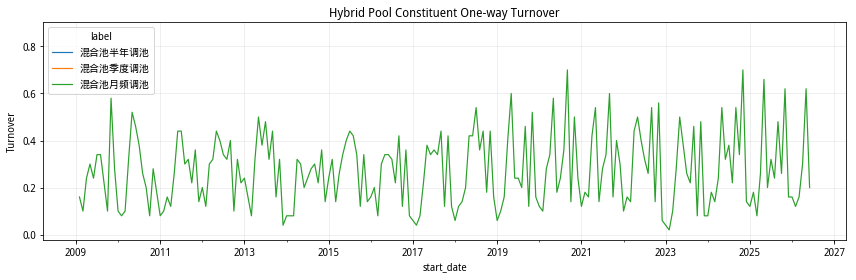

,avg_added_count,avg_one_way_turnover,avg_retention_rate,avg_symmetric_change_rate,max_one_way_turnover,median_added_count,median_one_way_turnover,median_retention_rate,p90_one_way_turnover,periods
label,,,,,,,,,,
混合池半年调池,31.323529,0.626471,0.373529,0.765887,0.84,32.0,0.64,0.36,0.740,35
混合池季度调池,25.188406,0.503768,0.496232,0.657545,0.86,25.0,0.50,0.50,0.684,70
混合池月频调池,13.712919,0.274258,0.725742,0.408743,0.70,13.0,0.26,0.74,0.484,210


In [16]:
# ============================================================
# 红利低波 x 红利质量混合池：季度 / 半年调池对比 - 3. 成分变动率
# ============================================================
# 兼容 pandas 0.23，避免使用较新版本才支持的 named aggregation。


def hybrid_variant_summarize_turnover(turnover_all):
    rows = []
    labels = sorted(turnover_all['label'].dropna().unique())
    for label in labels:
        data = turnover_all[turnover_all['label'] == label]
        row = {'label': label, 'periods': len(data)}
        metric_specs = [
            ('added_count', 'avg_added_count', 'mean'),
            ('added_count', 'median_added_count', 'median'),
            ('retention_rate', 'avg_retention_rate', 'mean'),
            ('retention_rate', 'median_retention_rate', 'median'),
            ('one_way_turnover', 'avg_one_way_turnover', 'mean'),
            ('one_way_turnover', 'median_one_way_turnover', 'median'),
            ('one_way_turnover', 'p90_one_way_turnover', 'p90'),
            ('one_way_turnover', 'max_one_way_turnover', 'max'),
            ('symmetric_change_rate', 'avg_symmetric_change_rate', 'mean'),
        ]
        for source_col, output_col, method in metric_specs:
            series = pd.to_numeric(data[source_col], errors='coerce').dropna()
            if series.empty:
                row[output_col] = np.nan
            elif method == 'mean':
                row[output_col] = series.mean()
            elif method == 'median':
                row[output_col] = series.median()
            elif method == 'p90':
                row[output_col] = series.quantile(0.90)
            elif method == 'max':
                row[output_col] = series.max()
        rows.append(row)
    return pd.DataFrame(rows).set_index('label')


hybrid_variant_turnover_parts = []
if 'hybrid_monthly_turnover' in globals() and isinstance(hybrid_monthly_turnover, pd.DataFrame):
    monthly_turnover_compare = hybrid_monthly_turnover.copy()
    monthly_turnover_compare['label'] = '混合池月频调池'
    hybrid_variant_turnover_parts.append(monthly_turnover_compare)
else:
    monthly_pool_for_compare = hybrid_load_pool_for_backtest()
    hybrid_variant_turnover_parts.append(hybrid_variant_turnover(monthly_pool_for_compare, '混合池月频调池'))

for result in hybrid_variant_results.values():
    hybrid_variant_turnover_parts.append(hybrid_variant_turnover(result['pool'], result['config']['label']))

hybrid_variant_turnover_all = pd.concat(hybrid_variant_turnover_parts, axis=0, ignore_index=True)
hybrid_variant_turnover_summary = hybrid_variant_summarize_turnover(hybrid_variant_turnover_all).sort_index()

print('成分变动率对比：')
print(hybrid_variant_turnover_summary.to_string())

fig, ax = plt.subplots(figsize=(12, 4))
hybrid_variant_turnover_all.pivot_table(
    index='start_date', columns='label', values='one_way_turnover', aggfunc='first'
).plot(ax=ax, lw=1.2, title='Hybrid Pool Constituent One-way Turnover')
ax.set_ylabel('Turnover')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

hybrid_variant_turnover_summary



等权持有收益表现对比：
              start         end trade_days total_return annual_return annual_volatility    sharpe max_drawdown final_nav
混合池月频调池  2009-01-05  2026-06-01       4226      7.35964      0.134987          0.200239  0.674127    -0.377356   8.35964
混合池季度调池  2009-01-05  2026-06-01       4226      10.3409      0.155818          0.207175   0.75211    -0.384913   11.3409
混合池半年调池  2009-01-05  2026-06-01       4226      15.0324      0.179927          0.210324  0.855474    -0.381256   16.0324


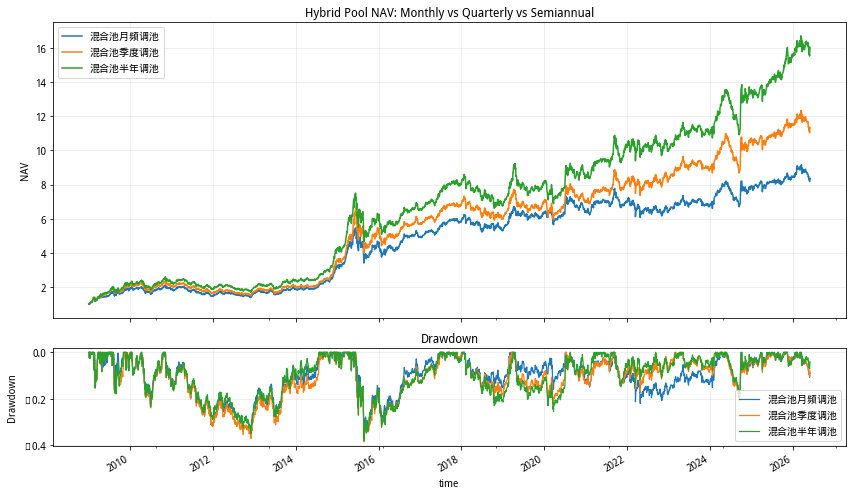

,start,end,trade_days,total_return,annual_return,annual_volatility,sharpe,max_drawdown,final_nav
混合池月频调池,2009-01-05,2026-06-01,4226,7.35964,0.134987,0.200239,0.674127,-0.377356,8.35964
混合池季度调池,2009-01-05,2026-06-01,4226,10.3409,0.155818,0.207175,0.75211,-0.384913,11.3409
混合池半年调池,2009-01-05,2026-06-01,4226,15.0324,0.179927,0.210324,0.855474,-0.381256,16.0324


In [17]:
# ============================================================
# 红利低波 x 红利质量混合池：季度 / 半年调池对比 - 4. 等权收益表现
# ============================================================


def hybrid_variant_equal_weight_nav(pool, name):
    work = pool.copy()
    work['jq_code'] = work['instrument'].map(hybrid_bt_instrument_to_jq)
    work['start_date'] = pd.to_datetime(work['start_date']).dt.strftime('%Y-%m-%d')
    work['end_date'] = pd.to_datetime(work['end_date']).dt.strftime('%Y-%m-%d')

    parts = []
    for (start_date, end_date), holdings in work.groupby(['start_date', 'end_date'], sort=True):
        stocks = holdings['jq_code'].dropna().unique().tolist()
        period_returns = hybrid_period_equal_weight_returns(stocks, start_date, end_date)
        if not period_returns.empty:
            parts.append(period_returns)

    if not parts:
        return pd.Series(dtype=float, name=name)
    daily_returns = pd.concat(parts).sort_index()
    daily_returns = daily_returns[~daily_returns.index.duplicated(keep='first')]
    return (1.0 + daily_returns).cumprod().rename(name)


def hybrid_variant_perf_summary(nav, name):
    nav = nav.dropna()
    returns = nav.pct_change().fillna(0.0)
    mdd, _ = hybrid_max_drawdown(nav)
    years = len(returns) / 252.0
    annual_return = nav.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan
    annual_volatility = returns.std() * np.sqrt(252.0)
    return pd.Series({
        'start': nav.index.min().strftime('%Y-%m-%d'),
        'end': nav.index.max().strftime('%Y-%m-%d'),
        'trade_days': len(returns),
        'total_return': nav.iloc[-1] - 1.0,
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'sharpe': annual_return / annual_volatility if annual_volatility and annual_volatility > 0 else np.nan,
        'max_drawdown': mdd,
        'final_nav': nav.iloc[-1],
    }, name=name)


hybrid_variant_navs = []
if 'hybrid_nav' in globals() and isinstance(hybrid_nav, pd.Series) and not hybrid_nav.empty:
    hybrid_variant_navs.append(hybrid_nav.rename('混合池月频调池'))
else:
    hybrid_variant_navs.append(hybrid_variant_equal_weight_nav(hybrid_load_pool_for_backtest(), '混合池月频调池'))

for result in hybrid_variant_results.values():
    hybrid_variant_navs.append(hybrid_variant_equal_weight_nav(result['pool'], result['config']['label']))

hybrid_variant_nav_compare = pd.concat(hybrid_variant_navs, axis=1).dropna()
hybrid_variant_nav_compare = hybrid_variant_nav_compare.divide(hybrid_variant_nav_compare.iloc[0])
hybrid_variant_perf_compare = pd.concat([
    hybrid_variant_perf_summary(hybrid_variant_nav_compare[col], col)
    for col in hybrid_variant_nav_compare.columns
], axis=1).T

print('等权持有收益表现对比：')
print(hybrid_variant_perf_compare.to_string())

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
hybrid_variant_nav_compare.plot(ax=axes[0], lw=1.5, title='Hybrid Pool NAV: Monthly vs Quarterly vs Semiannual')
axes[0].set_ylabel('NAV')
axes[0].grid(alpha=0.25)

hybrid_variant_nav_compare.divide(hybrid_variant_nav_compare.cummax()).sub(1.0).plot(
    ax=axes[1], lw=1.2, title='Drawdown'
)
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

hybrid_variant_perf_compare



universe: 半年混合池
score source: monthly -hybrid_score proxy
top_n: 20 cost_bps: 10.0
               start         end trade_days rebalance_count total_return annual_return annual_volatility    sharpe max_drawdown final_nav avg_one_way_turnover total_cost avg_signal_age_days avg_holdings
monthly   2009-01-05  2026-06-01       4226             210      16.9798       0.18802          0.198314  0.948093    -0.350654   17.9798             0.305405    0.12827              3.1619      19.0619
biweekly  2009-01-05  2026-06-01       4226             470      17.5287      0.190153          0.197931  0.960701    -0.359967   18.5287             0.142532    0.13398             16.4532      19.0872
weekly    2009-01-05  2026-06-01       4226             891      16.7269      0.187017           0.19796  0.944724    -0.360142   17.7269            0.0791067   0.140968             16.4433      19.0505


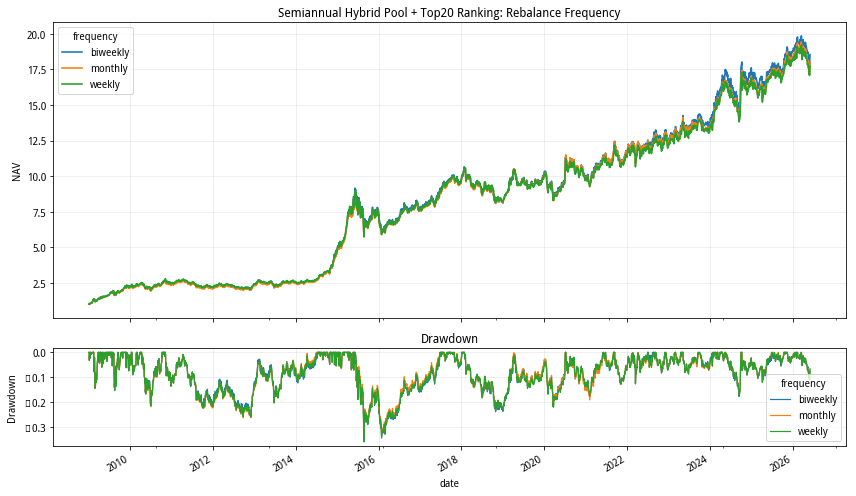

,start,end,trade_days,rebalance_count,total_return,annual_return,annual_volatility,sharpe,max_drawdown,final_nav,avg_one_way_turnover,total_cost,avg_signal_age_days,avg_holdings
monthly,2009-01-05,2026-06-01,4226,210,16.9798,0.18802,0.198314,0.948093,-0.350654,17.9798,0.305405,0.12827,3.1619,19.0619
biweekly,2009-01-05,2026-06-01,4226,470,17.5287,0.190153,0.197931,0.960701,-0.359967,18.5287,0.142532,0.13398,16.4532,19.0872
weekly,2009-01-05,2026-06-01,4226,891,16.7269,0.187017,0.19796,0.944724,-0.360142,17.7269,0.0791067,0.140968,16.4433,19.0505


In [18]:
# ============================================================
# 红利低波 x 红利质量混合池：半年风格池 + Top20 排序交易频率对比
# ============================================================
# 固定“半年调池混合池”作为 universe，再比较排序交易频率：
# monthly / biweekly / weekly。
#
# score 来源优先级：
# 1. hybrid_ml_score_df，字段 date, instrument, score，score 越大越好
# 2. ml_score_df，字段 date, instrument, score，score 越大越好
# 3. 没有真实 ML 分数时，使用月频混合池 detail 的 -hybrid_score 作为代理信号
#
# 这个 cell 回答的是：底层风格池半年稳定后，交易层到底月频/双周/周频哪个更合适。

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HYBRID_SEMI_FREQ_TOP_N = 20
HYBRID_SEMI_FREQ_COST_BPS = 10.0
HYBRID_SEMI_FREQ_LIST = ['monthly', 'biweekly', 'weekly']
HYBRID_SEMI_FREQ_MAX_SIGNAL_AGE_DAYS = 70


def hybrid_semi_freq_to_pool_instrument(code):
    code = str(code)
    if code.endswith('.XSHG'):
        return 'sh.' + code[:6]
    if code.endswith('.XSHE'):
        return 'sz.' + code[:6]
    return code


def hybrid_semi_freq_to_jq(code):
    code = str(code)
    if code.endswith(('.XSHG', '.XSHE')):
        return code
    return hybrid_bt_instrument_to_jq(code)


def hybrid_semi_freq_variant_files(name='semiannual'):
    if 'hybrid_variant_output_files' in globals():
        return hybrid_variant_output_files(name)
    start = pd.Timestamp(HYBRID_START_DATE).strftime('%Y%m%d')
    end = pd.Timestamp(HYBRID_END_DATE).strftime('%Y%m%d')
    return (
        'all_a_hybrid_hldb_hq_{}_indcap20_pool_{}_{}.csv'.format(name, start, end),
        'all_a_hybrid_hldb_hq_{}_indcap20_pool_detail_{}_{}.csv'.format(name, start, end),
        'all_a_hybrid_hldb_hq_{}_indcap20_stats_{}_{}.csv'.format(name, start, end),
    )


def hybrid_semi_freq_load_pool():
    if 'hybrid_variant_results' in globals() and 'semiannual' in hybrid_variant_results:
        return hybrid_variant_results['semiannual']['pool'].copy()
    semi_pool_file, _, _ = hybrid_semi_freq_variant_files('semiannual')
    if os.path.exists(semi_pool_file):
        return pd.read_csv(semi_pool_file)
    raise ValueError('没有找到半年混合池，请先运行“季度 / 半年调池对比 - 2. 重建或加载股票池”cell。')


def hybrid_semi_freq_load_monthly_detail():
    if 'hybrid_pool_detail' in globals() and isinstance(hybrid_pool_detail, pd.DataFrame) and not hybrid_pool_detail.empty:
        return hybrid_pool_detail.copy()
    if 'HYBRID_DETAIL_FILE' in globals() and os.path.exists(HYBRID_DETAIL_FILE):
        return pd.read_csv(HYBRID_DETAIL_FILE)
    return pd.read_csv('all_a_hybrid_hldb_hq_monthly_indcap20_pool_detail_20090101_20260601.csv')


def hybrid_semi_freq_prepare_score_df():
    if 'hybrid_ml_score_df' in globals() and isinstance(hybrid_ml_score_df, pd.DataFrame) and not hybrid_ml_score_df.empty:
        score_df = hybrid_ml_score_df.copy()
        score_source = 'hybrid_ml_score_df'
    elif 'ml_score_df' in globals() and isinstance(ml_score_df, pd.DataFrame) and not ml_score_df.empty:
        score_df = ml_score_df.copy()
        score_source = 'ml_score_df'
    else:
        detail = hybrid_semi_freq_load_monthly_detail()
        if 'hybrid_score' not in detail.columns:
            raise ValueError('没有找到 ML 分数，也没有 hybrid_score 可作为代理信号。')
        date_col = 'select_date' if 'select_date' in detail.columns else 'start_date'
        score_df = detail[[date_col, 'instrument', 'hybrid_score']].copy()
        score_df = score_df.rename(columns={date_col: 'date'})
        score_df['score'] = -pd.to_numeric(score_df['hybrid_score'], errors='coerce')
        score_df = score_df[['date', 'instrument', 'score']]
        score_source = 'monthly -hybrid_score proxy'

    required = {'date', 'instrument', 'score'}
    missing = required.difference(score_df.columns)
    if missing:
        raise ValueError('score_df 缺少字段: {}'.format(sorted(missing)))
    score_df = score_df[['date', 'instrument', 'score']].copy()
    score_df['date'] = pd.to_datetime(score_df['date'])
    score_df['instrument'] = score_df['instrument'].map(hybrid_semi_freq_to_pool_instrument)
    score_df['score'] = pd.to_numeric(score_df['score'], errors='coerce')
    score_df = score_df.dropna(subset=['date', 'instrument', 'score'])
    return score_df.sort_values(['date', 'score', 'instrument'], ascending=[True, False, True]), score_source


def hybrid_semi_freq_make_rebalance_dates(trading_days, frequency):
    days = pd.DatetimeIndex(pd.to_datetime(trading_days)).sort_values()
    frame = pd.DataFrame({'date': days}, index=days)
    if frequency == 'monthly':
        frame['key'] = frame.index.to_period('M').astype(str)
    elif frequency == 'weekly':
        frame['key'] = frame.index.to_period('W-SUN').astype(str)
    elif frequency == 'biweekly':
        keys = []
        for day in frame.index:
            iso = day.date().isocalendar()
            keys.append('{}-{}'.format(iso[0], int(iso[1]) // 2))
        frame['key'] = keys
    else:
        raise ValueError('暂不支持 frequency={}'.format(frequency))
    return pd.DatetimeIndex(frame.groupby('key')['date'].first().sort_values().values)


def hybrid_semi_freq_active_pool(pool_df, date):
    date = pd.Timestamp(date)
    mask = (pool_df['start_date'] <= date) & (pool_df['end_date'] >= date)
    return set(pool_df.loc[mask, 'instrument'])


def hybrid_semi_freq_latest_signal(score_df, rebalance_date, max_age_days=HYBRID_SEMI_FREQ_MAX_SIGNAL_AGE_DAYS):
    rebalance_date = pd.Timestamp(rebalance_date)
    available = score_df[score_df['date'] < rebalance_date]
    if available.empty:
        return pd.DataFrame(), pd.NaT
    signal_date = available['date'].max()
    if (rebalance_date - signal_date).days > max_age_days:
        return pd.DataFrame(), signal_date
    signal = available[available['date'] == signal_date].copy()
    return signal.sort_values(['score', 'instrument'], ascending=[False, True]), signal_date


def hybrid_semi_freq_build_targets(pool_df, score_df, trading_days, frequency, top_n):
    targets = {}
    logs = []
    rebalance_dates = hybrid_semi_freq_make_rebalance_dates(trading_days, frequency)
    for date in rebalance_dates:
        active = hybrid_semi_freq_active_pool(pool_df, date)
        signal, signal_date = hybrid_semi_freq_latest_signal(score_df, date)
        candidates = signal[signal['instrument'].isin(active)].drop_duplicates('instrument', keep='first')
        selected = candidates.head(top_n)['instrument'].tolist()
        weights = pd.Series(1.0 / len(selected), index=selected) if selected else pd.Series(dtype=float)
        targets[pd.Timestamp(date)] = weights
        logs.append({
            'frequency': frequency,
            'date': pd.Timestamp(date),
            'signal_date': signal_date,
            'signal_age_days': np.nan if pd.isnull(signal_date) else (pd.Timestamp(date) - signal_date).days,
            'pool_size': len(active),
            'candidate_size': len(candidates),
            'holdings': len(selected),
        })
    return targets, pd.DataFrame(logs)


def hybrid_semi_freq_fetch_close(jq_codes, start_date, end_date):
    if not jq_codes:
        return pd.DataFrame()
    price_data = get_price(
        sorted(jq_codes),
        start_date=pd.Timestamp(start_date).strftime('%Y-%m-%d'),
        end_date=pd.Timestamp(end_date).strftime('%Y-%m-%d'),
        frequency='daily',
        fields=['close'],
        panel=False,
        fill_paused=True,
    )
    close = hybrid_extract_close_frame(price_data, sorted(jq_codes))
    if close.empty:
        return close
    close.index = pd.to_datetime(close.index)
    close = close.sort_index().dropna(how='all')
    return close.ffill()


def hybrid_semi_freq_backtest_one(pool_df, score_df, trading_days, frequency, top_n, cost_bps):
    targets, rebalance_log = hybrid_semi_freq_build_targets(pool_df, score_df, trading_days, frequency, top_n)
    selected_instruments = sorted(set().union(*[set(w.index) for w in targets.values()])) if targets else []
    instrument_to_jq = {instrument: hybrid_semi_freq_to_jq(instrument) for instrument in selected_instruments}
    jq_to_instrument = {jq: instrument for instrument, jq in instrument_to_jq.items()}

    close = hybrid_semi_freq_fetch_close(list(jq_to_instrument.keys()), trading_days.min(), trading_days.max())
    if close.empty:
        raise ValueError('{} 无法取得价格数据。'.format(frequency))
    close = close.rename(columns=jq_to_instrument)
    returns = close.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    returns = returns.reindex(trading_days).fillna(0.0)

    cost_rate = cost_bps / 10000.0
    current_weights = pd.Series(dtype=float)
    daily_rows = []
    log_rows = []

    for date in trading_days:
        if current_weights.empty:
            gross_return = 0.0
        else:
            available = current_weights.index.intersection(returns.columns)
            gross_return = float((current_weights.reindex(available).fillna(0.0) * returns.loc[date, available].fillna(0.0)).sum())
            if 1.0 + gross_return != 0:
                current_weights = current_weights.reindex(available).fillna(0.0) * (1.0 + returns.loc[date, available].fillna(0.0)) / (1.0 + gross_return)

        traded_notional = 0.0
        cost = 0.0
        if pd.Timestamp(date) in targets:
            target = targets[pd.Timestamp(date)]
            all_names = current_weights.index.union(target.index)
            old = current_weights.reindex(all_names).fillna(0.0)
            new = target.reindex(all_names).fillna(0.0)
            traded_notional = float((new - old).abs().sum())
            cost = traded_notional * cost_rate
            current_weights = target.copy()
            log_rows.append({
                'frequency': frequency,
                'date': pd.Timestamp(date),
                'traded_notional': traded_notional,
                'one_way_turnover': traded_notional / 2.0,
                'cost': cost,
            })

        daily_rows.append({
            'frequency': frequency,
            'date': pd.Timestamp(date),
            'gross_return': gross_return,
            'cost': cost,
            'net_return': gross_return - cost,
        })

    daily = pd.DataFrame(daily_rows).set_index('date')
    daily['nav'] = (1.0 + daily['net_return']).cumprod()
    turnover_log = pd.DataFrame(log_rows)
    if not turnover_log.empty:
        rebalance_log = rebalance_log.merge(turnover_log, on=['frequency', 'date'], how='left')
    else:
        rebalance_log['traded_notional'] = np.nan
        rebalance_log['one_way_turnover'] = np.nan
        rebalance_log['cost'] = np.nan
    rebalance_log[['traded_notional', 'one_way_turnover', 'cost']] = rebalance_log[['traded_notional', 'one_way_turnover', 'cost']].fillna(0.0)
    return hybrid_semi_freq_perf_summary(daily['nav'], frequency, rebalance_log), daily.reset_index(), rebalance_log


def hybrid_semi_freq_perf_summary(nav, frequency, rebalance_log):
    nav = nav.dropna()
    returns = nav.pct_change().fillna(0.0)
    mdd, _ = hybrid_max_drawdown(nav)
    years = len(returns) / 252.0
    annual_return = nav.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan
    annual_volatility = returns.std() * np.sqrt(252.0)
    return pd.Series({
        'start': nav.index.min().strftime('%Y-%m-%d'),
        'end': nav.index.max().strftime('%Y-%m-%d'),
        'trade_days': len(returns),
        'rebalance_count': len(rebalance_log),
        'total_return': nav.iloc[-1] - 1.0,
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'sharpe': annual_return / annual_volatility if annual_volatility and annual_volatility > 0 else np.nan,
        'max_drawdown': mdd,
        'final_nav': nav.iloc[-1],
        'avg_one_way_turnover': rebalance_log['one_way_turnover'].mean() if len(rebalance_log) else np.nan,
        'total_cost': rebalance_log['cost'].sum() if len(rebalance_log) else 0.0,
        'avg_signal_age_days': rebalance_log['signal_age_days'].mean() if len(rebalance_log) else np.nan,
        'avg_holdings': rebalance_log['holdings'].mean() if len(rebalance_log) else np.nan,
    }, name=frequency)


hybrid_semi_freq_pool = hybrid_semi_freq_load_pool()[['instrument', 'start_date', 'end_date']].copy()
hybrid_semi_freq_pool['instrument'] = hybrid_semi_freq_pool['instrument'].map(hybrid_semi_freq_to_pool_instrument)
hybrid_semi_freq_pool['start_date'] = pd.to_datetime(hybrid_semi_freq_pool['start_date'])
hybrid_semi_freq_pool['end_date'] = pd.to_datetime(hybrid_semi_freq_pool['end_date'])

hybrid_semi_freq_score_df, hybrid_semi_freq_score_source = hybrid_semi_freq_prepare_score_df()
hybrid_semi_freq_trading_days = pd.DatetimeIndex(get_trade_days(
    start_date=hybrid_semi_freq_pool['start_date'].min(),
    end_date=hybrid_semi_freq_pool['end_date'].max(),
))

hybrid_semi_freq_summaries = []
hybrid_semi_freq_nav_parts = []
hybrid_semi_freq_log_parts = []

for hybrid_freq in HYBRID_SEMI_FREQ_LIST:
    summary, daily_nav, rebalance_log = hybrid_semi_freq_backtest_one(
        hybrid_semi_freq_pool,
        hybrid_semi_freq_score_df,
        hybrid_semi_freq_trading_days,
        hybrid_freq,
        HYBRID_SEMI_FREQ_TOP_N,
        HYBRID_SEMI_FREQ_COST_BPS,
    )
    hybrid_semi_freq_summaries.append(summary)
    hybrid_semi_freq_nav_parts.append(daily_nav)
    hybrid_semi_freq_log_parts.append(rebalance_log)

hybrid_semiannual_ml_freq_summary = pd.concat(hybrid_semi_freq_summaries, axis=1).T
hybrid_semiannual_ml_freq_nav = pd.concat(hybrid_semi_freq_nav_parts, axis=0, ignore_index=True)
hybrid_semiannual_ml_freq_rebalance_log = pd.concat(hybrid_semi_freq_log_parts, axis=0, ignore_index=True)

print('universe: 半年混合池')
print('score source:', hybrid_semi_freq_score_source)
print('top_n:', HYBRID_SEMI_FREQ_TOP_N, 'cost_bps:', HYBRID_SEMI_FREQ_COST_BPS)
print(hybrid_semiannual_ml_freq_summary.to_string())

hybrid_semi_freq_nav_pivot = hybrid_semiannual_ml_freq_nav.pivot(index='date', columns='frequency', values='nav').dropna(how='all')
hybrid_semi_freq_nav_pivot = hybrid_semi_freq_nav_pivot.divide(hybrid_semi_freq_nav_pivot.iloc[0])
hybrid_semi_freq_drawdown = hybrid_semi_freq_nav_pivot.divide(hybrid_semi_freq_nav_pivot.cummax()) - 1.0

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
hybrid_semi_freq_nav_pivot.plot(ax=axes[0], lw=1.6, title='Semiannual Hybrid Pool + Top20 Ranking: Rebalance Frequency')
axes[0].set_ylabel('NAV')
axes[0].grid(alpha=0.25)
hybrid_semi_freq_drawdown.plot(ax=axes[1], lw=1.2, title='Drawdown')
axes[1].set_ylabel('Drawdown')
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

hybrid_semiannual_ml_freq_summary



building future cache: weekly_5d
  rebalance samples: 890
building future cache: biweekly_10d
  rebalance samples: 469
building future cache: monthly_20d
  rebalance samples: 208
universe: 半年混合池
top_n: 20 cost_bps: 10.0 runs: 10
skill grid: [0.0, 0.03, 0.05, 0.1, 0.15, 0.2]
frequency  horizon_days  mean_annual_return  mean_final_nav  mean_max_drawdown  mean_realized_ic  mean_sharpe  mean_total_cost  mean_turnover  runs      scenario  skill  std_annual_return  std_sharpe
  weekly             5            0.105459        5.458237          -0.431220         -0.000027     0.490098         1.092248       0.613622    10     weekly_5d   0.00           0.012820    0.059860
biweekly            10            0.140483        9.201077          -0.422770          0.001604     0.651081         0.584585       0.623225    10  biweekly_10d   0.00           0.012701    0.058119
 monthly            20            0.158127       12.091802          -0.413498         -0.004097     0.734456         0.270592  

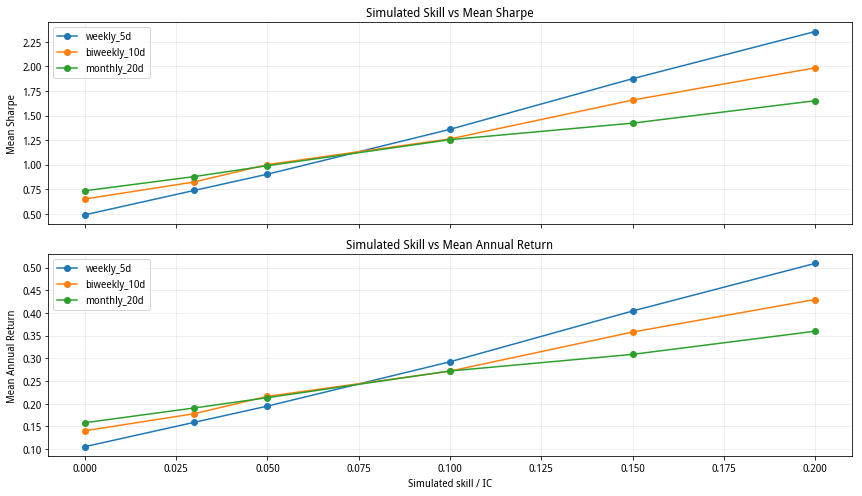

,frequency,horizon_days,mean_annual_return,mean_final_nav,mean_max_drawdown,mean_realized_ic,mean_sharpe,mean_total_cost,mean_turnover,runs,scenario,skill,std_annual_return,std_sharpe
0,weekly,5,0.105459,5.458237,-0.431220,-0.000027,0.490098,1.092248,0.613622,10,weekly_5d,0.00,0.012820,0.059860
1,biweekly,10,0.140483,9.201077,-0.422770,0.001604,0.651081,0.584585,0.623225,10,biweekly_10d,0.00,0.012701,0.058119
2,monthly,20,0.158127,12.091802,-0.413498,-0.004097,0.734456,0.270592,0.650460,10,monthly_20d,0.00,0.018242,0.084512
3,weekly,5,0.159102,12.339377,-0.403634,0.027960,0.738659,1.092980,0.614034,10,weekly_5d,0.03,0.020366,0.094491
4,biweekly,10,0.178099,16.069564,-0.403937,0.025041,0.824582,0.587432,0.626260,10,biweekly_10d,0.03,0.018518,0.085322
5,monthly,20,0.190742,19.242630,-0.397096,0.026383,0.879331,0.270602,0.650485,10,monthly_20d,0.03,0.018680,0.084185
6,weekly,5,0.194753,19.957474,-0.391525,0.042539,0.903272,1.096050,0.615759,10,weekly_5d,0.05,0.010678,0.051412
7,biweekly,10,0.216252,27.430769,-0.387521,0.046642,1.001250,0.584539,0.623176,10,biweekly_10d,0.05,0.018711,0.086816
8,monthly,20,0.213347,26.001802,-0.388194,0.046909,0.989644,0.271927,0.653671,10,monthly_20d,0.05,0.013584,0.064736
9,weekly,5,0.292372,74.499241,-0.378341,0.087361,1.359893,1.093014,0.614053,10,weekly_5d,0.10,0.011926,0.057916


In [2]:
# ============================================================
# 红利低波 x 红利质量混合池：模拟选股能力下的交易频率实验（内存优化版）
# ============================================================
# 内存优化点：
# 1. 默认 Monte Carlo 从 30 降到 10，可按需调高。
# 2. 不一次性保存所有净值样例，只保存汇总结果。
# 3. 价格矩阵转 float32，并只保留半年池出现过的股票列。
# 4. 每个 scenario 只生成一次 future_excess_cache，所有 skill/run 复用。
# 5. 回测只返回 summary，不保留每日日频明细。

import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import time
from datetime import timedelta

import numpy as np
import pandas as pd

try:
    from jqdata import *
    from jqdata import finance
except ImportError:
    pass

try:
    from jqfactor import get_factor_values
except ImportError:
    pass

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

HYBRID_SKILL_SIM_TOP_N = 20
HYBRID_SKILL_SIM_COST_BPS = 10.0
HYBRID_SKILL_SIM_RUNS = 10
HYBRID_SKILL_SIM_SEED = 20260605
HYBRID_SKILL_SIM_SKILLS = [0.00, 0.03, 0.05, 0.10, 0.15, 0.20]
HYBRID_SKILL_SIM_SCENARIOS = [
    {'frequency': 'weekly', 'horizon_days': 5, 'label': 'weekly_5d'},
    {'frequency': 'biweekly', 'horizon_days': 10, 'label': 'biweekly_10d'},
    {'frequency': 'monthly', 'horizon_days': 20, 'label': 'monthly_20d'},
]


HYBRID_SKILL_SIM_POOL_FILE = globals().get(
    'HYBRID_SKILL_SIM_POOL_FILE',
    'all_a_hybrid_hldb_hq_semiannual_indcap20_pool_20090101_20260601.csv',
)


def hybrid_skill_sim_find_existing_file(pattern):
    try:
        import glob
        matches = sorted(glob.glob(pattern))
        return matches[-1] if matches else None
    except Exception:
        return None


def hybrid_skill_sim_extract_close_frame(price_data, stocks):
    if 'hybrid_extract_close_frame' in globals():
        return hybrid_extract_close_frame(price_data, stocks)
    if price_data is None:
        return pd.DataFrame()
    if isinstance(price_data, dict) and 'close' in price_data:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)
    try:
        close = price_data['close']
        if isinstance(close, pd.DataFrame):
            return close.reindex(columns=stocks)
    except Exception:
        pass
    if isinstance(price_data, pd.DataFrame):
        if {'code', 'close'}.issubset(price_data.columns):
            date_col = None
            for candidate in ['time', 'date', 'day']:
                if candidate in price_data.columns:
                    date_col = candidate
                    break
            if isinstance(date_col, str):
                close = price_data.pivot(index=date_col, columns='code', values='close')
            else:
                tmp = price_data.copy()
                tmp['_date'] = tmp.index
                close = tmp.pivot(index='_date', columns='code', values='close')
            return close.reindex(columns=stocks)
        if set(stocks).issubset(set(price_data.columns)):
            return price_data.reindex(columns=stocks)
    raise TypeError('无法解析 get_price 返回结构: {}'.format(type(price_data)))


def hybrid_skill_sim_max_drawdown(nav):
    if 'hybrid_max_drawdown' in globals():
        return hybrid_max_drawdown(nav)
    running_max = nav.cummax()
    drawdown = nav / running_max - 1.0
    return drawdown.min(), drawdown


def hybrid_skill_sim_to_pool_instrument(code):
    code = str(code)
    if code.endswith('.XSHG'):
        return 'sh.' + code[:6]
    if code.endswith('.XSHE'):
        return 'sz.' + code[:6]
    return code


def hybrid_skill_sim_to_jq(code):
    code = str(code)
    if code.endswith(('.XSHG', '.XSHE')):
        return code
    if 'hybrid_bt_instrument_to_jq' in globals():
        return hybrid_bt_instrument_to_jq(code)
    market, num = code.split('.')
    if market == 'sh':
        return num + '.XSHG'
    if market == 'sz':
        return num + '.XSHE'
    return code


def hybrid_skill_sim_variant_files(name='semiannual'):
    if 'hybrid_variant_output_files' in globals():
        return hybrid_variant_output_files(name)
    pool_file = HYBRID_SKILL_SIM_POOL_FILE
    if not os.path.exists(pool_file):
        found = hybrid_skill_sim_find_existing_file('all_a_hybrid_hldb_hq_{}_indcap20_pool_*.csv'.format(name))
        if found is not None:
            pool_file = found
    detail_file = pool_file.replace('_pool_', '_pool_detail_')
    stats_file = pool_file.replace('_pool_', '_stats_')
    return pool_file, detail_file, stats_file


def hybrid_skill_sim_load_pool():
    if 'hybrid_variant_results' in globals() and 'semiannual' in hybrid_variant_results:
        return hybrid_variant_results['semiannual']['pool'].copy()
    semi_pool_file, _, _ = hybrid_skill_sim_variant_files('semiannual')
    if os.path.exists(semi_pool_file):
        return pd.read_csv(semi_pool_file)
    raise ValueError('没有找到半年混合池，请先运行“季度 / 半年调池对比 - 2. 重建或加载股票池”cell。')


def hybrid_skill_sim_make_rebalance_dates(trading_days, frequency):
    days = pd.DatetimeIndex(pd.to_datetime(trading_days)).sort_values()
    frame = pd.DataFrame({'date': days}, index=days)
    if frequency == 'monthly':
        frame['key'] = frame.index.to_period('M').astype(str)
    elif frequency == 'weekly':
        frame['key'] = frame.index.to_period('W-SUN').astype(str)
    elif frequency == 'biweekly':
        keys = []
        for day in frame.index:
            iso = day.date().isocalendar()
            keys.append('{}-{}'.format(iso[0], int(iso[1]) // 2))
        frame['key'] = keys
    else:
        raise ValueError('暂不支持 frequency={}'.format(frequency))
    return pd.DatetimeIndex(frame.groupby('key')['date'].first().sort_values().values)


def hybrid_skill_sim_active_pool(pool_df, date):
    date = pd.Timestamp(date)
    mask = (pool_df['start_date'] <= date) & (pool_df['end_date'] >= date)
    return set(pool_df.loc[mask, 'instrument'])


def hybrid_skill_sim_fetch_close(pool_df):
    instruments = sorted(pool_df['instrument'].dropna().astype(str).unique())
    jq_codes = sorted(set([hybrid_skill_sim_to_jq(code) for code in instruments]))
    price_data = get_price(
        jq_codes,
        start_date=pool_df['start_date'].min().strftime('%Y-%m-%d'),
        end_date=pool_df['end_date'].max().strftime('%Y-%m-%d'),
        frequency='daily',
        fields=['close'],
        panel=False,
        fill_paused=True,
    )
    close = hybrid_skill_sim_extract_close_frame(price_data, jq_codes)
    if close.empty:
        raise ValueError('无法取得半年混合池价格数据。')
    jq_to_instrument = {hybrid_skill_sim_to_jq(code): code for code in instruments}
    close = close.rename(columns=jq_to_instrument)
    close.index = pd.to_datetime(close.index)
    close = close.sort_index().dropna(how='all').ffill()
    close = close.astype('float32')
    return close


def hybrid_skill_sim_zscore_values(values):
    values = values.astype('float64')
    mean = np.nanmean(values)
    std = np.nanstd(values)
    if not np.isfinite(std) or std == 0:
        return np.zeros_like(values, dtype='float64')
    return (values - mean) / std


def hybrid_skill_sim_build_future_cache(pool_df, close, trading_days, scenario):
    frequency = scenario['frequency']
    horizon_days = scenario['horizon_days']
    rebalance_dates = hybrid_skill_sim_make_rebalance_dates(trading_days, frequency)
    date_to_pos = pd.Series(np.arange(len(close.index)), index=close.index)
    cache = []

    for date in rebalance_dates:
        if date not in date_to_pos.index:
            continue
        loc = int(date_to_pos.loc[date])
        entry_loc = loc + 1
        exit_loc = loc + horizon_days
        if exit_loc >= len(close.index):
            continue

        active = hybrid_skill_sim_active_pool(pool_df, date)
        names = sorted(set(active).intersection(set(close.columns)))
        if not names:
            continue

        entry = close.iloc[entry_loc][names]
        exit_ = close.iloc[exit_loc][names]
        future_ret = (exit_ / entry - 1.0).replace([np.inf, -np.inf], np.nan).dropna()
        if future_ret.empty:
            continue

        future_excess = future_ret - future_ret.mean()
        names = future_excess.index.values.astype(object)
        z_future = hybrid_skill_sim_zscore_values(future_excess.values)
        cache.append({
            'date': pd.Timestamp(date),
            'names': names,
            'future_excess': future_excess.values.astype('float32'),
            'z_future': z_future.astype('float32'),
            'pool_size': len(active),
            'candidate_size': len(names),
        })
    return cache


def hybrid_skill_sim_targets_from_cache(cache, scenario, skill, rng, top_n):
    targets = {}
    logs = []
    noise_weight = np.sqrt(max(0.0, 1.0 - skill ** 2))

    for item in cache:
        names = item['names']
        z_future = item['z_future'].astype('float64')
        noise = rng.normal(size=len(names))
        noise = hybrid_skill_sim_zscore_values(noise)
        score = skill * z_future + noise_weight * noise

        if len(score) > top_n:
            selected_pos = np.argpartition(-score, top_n - 1)[:top_n]
            selected_pos = selected_pos[np.argsort(-score[selected_pos])]
        else:
            selected_pos = np.argsort(-score)
        selected = names[selected_pos]
        weights = pd.Series(1.0 / len(selected), index=selected) if len(selected) else pd.Series(dtype=float)

        rank_score = pd.Series(score).rank().values
        rank_future = pd.Series(item['future_excess']).rank().values
        ic = np.corrcoef(rank_score, rank_future)[0, 1] if len(score) > 1 else np.nan

        targets[item['date']] = weights
        logs.append({
            'date': item['date'],
            'frequency': scenario['frequency'],
            'horizon_days': scenario['horizon_days'],
            'pool_size': item['pool_size'],
            'candidate_size': item['candidate_size'],
            'holdings': len(selected),
            'realized_ic': ic,
        })
    return targets, pd.DataFrame(logs)


def hybrid_skill_sim_backtest_summary(close, trading_days, targets, cost_bps):
    returns = close.pct_change().replace([np.inf, -np.inf], np.nan).fillna(0.0).astype('float32')
    returns = returns.reindex(trading_days).fillna(0.0)
    cost_rate = cost_bps / 10000.0
    current_weights = pd.Series(dtype=float)
    nav_values = []
    current_nav = 1.0
    turnover_values = []
    cost_values = []

    for date in trading_days:
        if current_weights.empty:
            gross_return = 0.0
        else:
            available = current_weights.index.intersection(returns.columns)
            day_ret = returns.loc[date, available].astype('float64')
            old_weights = current_weights.reindex(available).fillna(0.0)
            gross_return = float((old_weights * day_ret).sum())
            if 1.0 + gross_return != 0:
                current_weights = old_weights * (1.0 + day_ret) / (1.0 + gross_return)

        cost = 0.0
        if pd.Timestamp(date) in targets:
            target = targets[pd.Timestamp(date)]
            all_names = current_weights.index.union(target.index)
            old = current_weights.reindex(all_names).fillna(0.0)
            new = target.reindex(all_names).fillna(0.0)
            traded_notional = float((new - old).abs().sum())
            cost = traded_notional * cost_rate
            current_weights = target.copy()
            turnover_values.append(traded_notional / 2.0)
            cost_values.append(cost)

        current_nav *= (1.0 + gross_return - cost)
        nav_values.append(current_nav)

    nav = pd.Series(nav_values, index=trading_days)
    ret = nav.pct_change().fillna(0.0)
    mdd, _ = hybrid_skill_sim_max_drawdown(nav)
    years = len(ret) / 252.0
    annual_return = nav.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan
    annual_volatility = ret.std() * np.sqrt(252.0)
    return {
        'total_return': nav.iloc[-1] - 1.0,
        'annual_return': annual_return,
        'annual_volatility': annual_volatility,
        'sharpe': annual_return / annual_volatility if annual_volatility and annual_volatility > 0 else np.nan,
        'max_drawdown': mdd,
        'final_nav': nav.iloc[-1],
        'avg_one_way_turnover': np.mean(turnover_values) if turnover_values else np.nan,
        'total_cost': np.sum(cost_values) if cost_values else 0.0,
        'rebalance_count': len(turnover_values),
    }


def hybrid_skill_sim_summarize(results):
    rows = []
    grouped = results.groupby(['scenario', 'frequency', 'horizon_days', 'skill'])
    for key, group in grouped:
        scenario, frequency, horizon_days, skill = key
        rows.append({
            'scenario': scenario,
            'frequency': frequency,
            'horizon_days': horizon_days,
            'skill': skill,
            'runs': len(group),
            'mean_annual_return': group['annual_return'].mean(),
            'std_annual_return': group['annual_return'].std(),
            'mean_sharpe': group['sharpe'].mean(),
            'std_sharpe': group['sharpe'].std(),
            'mean_max_drawdown': group['max_drawdown'].mean(),
            'mean_final_nav': group['final_nav'].mean(),
            'mean_turnover': group['avg_one_way_turnover'].mean(),
            'mean_total_cost': group['total_cost'].mean(),
            'mean_realized_ic': group['realized_ic'].mean(),
        })
    return pd.DataFrame(rows).sort_values(['skill', 'horizon_days']).reset_index(drop=True)


hybrid_skill_sim_pool = hybrid_skill_sim_load_pool()[['instrument', 'start_date', 'end_date']].copy()
hybrid_skill_sim_pool['instrument'] = hybrid_skill_sim_pool['instrument'].map(hybrid_skill_sim_to_pool_instrument)
hybrid_skill_sim_pool['start_date'] = pd.to_datetime(hybrid_skill_sim_pool['start_date'])
hybrid_skill_sim_pool['end_date'] = pd.to_datetime(hybrid_skill_sim_pool['end_date'])

hybrid_skill_sim_close = hybrid_skill_sim_fetch_close(hybrid_skill_sim_pool)
hybrid_skill_sim_trading_days = pd.DatetimeIndex(get_trade_days(
    start_date=hybrid_skill_sim_pool['start_date'].min(),
    end_date=hybrid_skill_sim_pool['end_date'].max(),
))
hybrid_skill_sim_trading_days = hybrid_skill_sim_trading_days[hybrid_skill_sim_trading_days.isin(hybrid_skill_sim_close.index)]

hybrid_skill_sim_result_rows = []

for scenario in HYBRID_SKILL_SIM_SCENARIOS:
    print('building future cache:', scenario['label'])
    future_cache = hybrid_skill_sim_build_future_cache(
        hybrid_skill_sim_pool,
        hybrid_skill_sim_close,
        hybrid_skill_sim_trading_days,
        scenario,
    )
    print('  rebalance samples:', len(future_cache))

    for skill in HYBRID_SKILL_SIM_SKILLS:
        for run_id in range(HYBRID_SKILL_SIM_RUNS):
            seed = HYBRID_SKILL_SIM_SEED + run_id + int(skill * 10000) + scenario['horizon_days'] * 100000
            rng = np.random.RandomState(seed)
            targets, signal_log = hybrid_skill_sim_targets_from_cache(
                future_cache,
                scenario,
                skill,
                rng,
                HYBRID_SKILL_SIM_TOP_N,
            )
            perf = hybrid_skill_sim_backtest_summary(
                hybrid_skill_sim_close,
                hybrid_skill_sim_trading_days,
                targets,
                HYBRID_SKILL_SIM_COST_BPS,
            )
            perf.update({
                'scenario': scenario['label'],
                'frequency': scenario['frequency'],
                'horizon_days': scenario['horizon_days'],
                'skill': skill,
                'run_id': run_id,
                'realized_ic': signal_log['realized_ic'].mean() if len(signal_log) else np.nan,
            })
            hybrid_skill_sim_result_rows.append(perf)
    del future_cache
    gc.collect()

hybrid_skill_sim_results = pd.DataFrame(hybrid_skill_sim_result_rows)
hybrid_skill_sim_summary = hybrid_skill_sim_summarize(hybrid_skill_sim_results)

print('universe: 半年混合池')
print('top_n:', HYBRID_SKILL_SIM_TOP_N, 'cost_bps:', HYBRID_SKILL_SIM_COST_BPS, 'runs:', HYBRID_SKILL_SIM_RUNS)
print('skill grid:', HYBRID_SKILL_SIM_SKILLS)
print(hybrid_skill_sim_summary.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for scenario in HYBRID_SKILL_SIM_SCENARIOS:
    subset = hybrid_skill_sim_summary[hybrid_skill_sim_summary['scenario'] == scenario['label']]
    axes[0].plot(subset['skill'], subset['mean_sharpe'], marker='o', label=scenario['label'])
    axes[1].plot(subset['skill'], subset['mean_annual_return'], marker='o', label=scenario['label'])
axes[0].set_title('Simulated Skill vs Mean Sharpe')
axes[0].set_ylabel('Mean Sharpe')
axes[0].grid(alpha=0.25)
axes[0].legend()
axes[1].set_title('Simulated Skill vs Mean Annual Return')
axes[1].set_xlabel('Simulated skill / IC')
axes[1].set_ylabel('Mean Annual Return')
axes[1].grid(alpha=0.25)
axes[1].legend()
plt.tight_layout()
plt.show()

hybrid_skill_sim_summary




building future cache: weekly_5d
  rebalance samples: 890
building future cache: biweekly_10d
  rebalance samples: 469
building future cache: monthly_20d
  rebalance samples: 208
universe: 半年混合池
top_n list: [5, 10, 20] runs: 10 cost_bps: 10.0
frequency  horizon_days  mean_annual_return  mean_final_nav  mean_max_drawdown  mean_realized_ic  mean_sharpe  mean_total_cost  mean_turnover  runs      scenario  skill  std_annual_return  std_sharpe  top_n
  weekly             5            0.064149        2.986464          -0.570505         -0.002281     0.263955         1.608310       0.903545    10     weekly_5d   0.00           0.022480    0.092291      5
biweekly            10            0.112276        6.583238          -0.520101         -0.006568     0.461889         0.846306       0.902245    10  biweekly_10d   0.00           0.033296    0.134314      5
 monthly            20            0.154348       12.288239          -0.464629          0.000356     0.629285         0.380142       0.9138

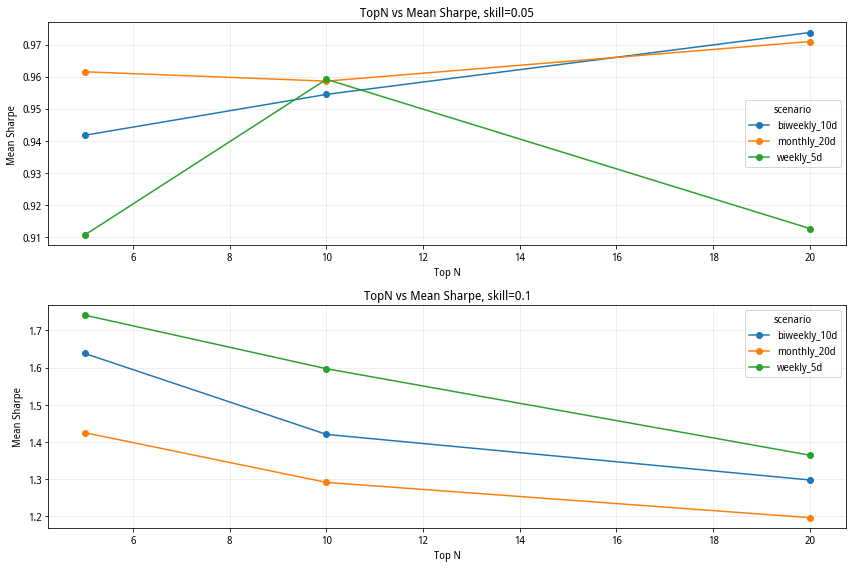

,frequency,horizon_days,mean_annual_return,mean_final_nav,mean_max_drawdown,mean_realized_ic,mean_sharpe,mean_total_cost,mean_turnover,runs,scenario,skill,std_annual_return,std_sharpe,top_n
0,weekly,5,0.064149,2.986464,-0.570505,-0.002281,0.263955,1.608310,0.903545,10,weekly_5d,0.00,0.022480,0.092291,5
1,biweekly,10,0.112276,6.583238,-0.520101,-0.006568,0.461889,0.846306,0.902245,10,biweekly_10d,0.00,0.033296,0.134314,5
2,monthly,20,0.154348,12.288239,-0.464629,0.000356,0.629285,0.380142,0.913803,10,monthly_20d,0.00,0.033284,0.136307,5
3,weekly,5,0.086430,4.345781,-0.513504,-0.001649,0.386872,1.439776,0.808863,10,weekly_5d,0.00,0.029914,0.134192,10
4,biweekly,10,0.131232,8.102695,-0.457011,-0.000991,0.582382,0.761150,0.811461,10,biweekly_10d,0.00,0.016350,0.070966,10
5,monthly,20,0.167406,14.546775,-0.432400,0.006238,0.742847,0.342291,0.822816,10,monthly_20d,0.00,0.030622,0.137880,10
6,weekly,5,0.108724,5.811122,-0.438887,0.000977,0.503672,1.092241,0.613618,10,weekly_5d,0.00,0.016939,0.077951,20
7,biweekly,10,0.129767,7.862659,-0.431780,-0.003179,0.601954,0.583975,0.622575,10,biweekly_10d,0.00,0.013081,0.060428,20
8,monthly,20,0.161143,12.372013,-0.413312,0.000720,0.743420,0.272305,0.654579,10,monthly_20d,0.00,0.010512,0.047123,20
9,weekly,5,0.142985,10.031771,-0.515580,0.024428,0.590713,1.604338,0.901313,10,weekly_5d,0.03,0.027103,0.112396,5


In [3]:
# ============================================================
# 红利低波 x 红利质量混合池：模拟选股能力 Top5 / Top10 / Top20 对比
# ============================================================
# 依赖上一个“模拟选股能力下的交易频率实验（内存优化版）”cell 中定义的函数。
# 如果上个 cell 已经跑过，会复用 hybrid_skill_sim_close / hybrid_skill_sim_pool 等变量。
# 为了节省内存，本 cell 只输出汇总结果，不保存日频净值。

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HYBRID_SKILL_TOPN_LIST = [5, 10, 20]
HYBRID_SKILL_TOPN_RUNS = HYBRID_SKILL_SIM_RUNS if 'HYBRID_SKILL_SIM_RUNS' in globals() else 10
HYBRID_SKILL_TOPN_SKILLS = HYBRID_SKILL_SIM_SKILLS if 'HYBRID_SKILL_SIM_SKILLS' in globals() else [0.00, 0.03, 0.05, 0.10, 0.15, 0.20]
HYBRID_SKILL_TOPN_SCENARIOS = HYBRID_SKILL_SIM_SCENARIOS if 'HYBRID_SKILL_SIM_SCENARIOS' in globals() else [
    {'frequency': 'weekly', 'horizon_days': 5, 'label': 'weekly_5d'},
    {'frequency': 'biweekly', 'horizon_days': 10, 'label': 'biweekly_10d'},
    {'frequency': 'monthly', 'horizon_days': 20, 'label': 'monthly_20d'},
]
HYBRID_SKILL_TOPN_COST_BPS = HYBRID_SKILL_SIM_COST_BPS if 'HYBRID_SKILL_SIM_COST_BPS' in globals() else 10.0
HYBRID_SKILL_TOPN_SEED = HYBRID_SKILL_SIM_SEED if 'HYBRID_SKILL_SIM_SEED' in globals() else 20260605


# 如果上个 cell 没跑完整，这里补齐必要数据。
if 'hybrid_skill_sim_pool' not in globals():
    hybrid_skill_sim_pool = hybrid_skill_sim_load_pool()[['instrument', 'start_date', 'end_date']].copy()
    hybrid_skill_sim_pool['instrument'] = hybrid_skill_sim_pool['instrument'].map(hybrid_skill_sim_to_pool_instrument)
    hybrid_skill_sim_pool['start_date'] = pd.to_datetime(hybrid_skill_sim_pool['start_date'])
    hybrid_skill_sim_pool['end_date'] = pd.to_datetime(hybrid_skill_sim_pool['end_date'])

if 'hybrid_skill_sim_close' not in globals():
    hybrid_skill_sim_close = hybrid_skill_sim_fetch_close(hybrid_skill_sim_pool)

if 'hybrid_skill_sim_trading_days' not in globals():
    hybrid_skill_sim_trading_days = pd.DatetimeIndex(get_trade_days(
        start_date=hybrid_skill_sim_pool['start_date'].min(),
        end_date=hybrid_skill_sim_pool['end_date'].max(),
    ))
    hybrid_skill_sim_trading_days = hybrid_skill_sim_trading_days[hybrid_skill_sim_trading_days.isin(hybrid_skill_sim_close.index)]


hybrid_skill_topn_rows = []

for scenario in HYBRID_SKILL_TOPN_SCENARIOS:
    print('building future cache:', scenario['label'])
    future_cache = hybrid_skill_sim_build_future_cache(
        hybrid_skill_sim_pool,
        hybrid_skill_sim_close,
        hybrid_skill_sim_trading_days,
        scenario,
    )
    print('  rebalance samples:', len(future_cache))

    for top_n in HYBRID_SKILL_TOPN_LIST:
        for skill in HYBRID_SKILL_TOPN_SKILLS:
            for run_id in range(HYBRID_SKILL_TOPN_RUNS):
                seed = HYBRID_SKILL_TOPN_SEED + run_id + int(skill * 10000) + scenario['horizon_days'] * 100000 + top_n * 10000000
                rng = np.random.RandomState(seed)
                targets, signal_log = hybrid_skill_sim_targets_from_cache(
                    future_cache,
                    scenario,
                    skill,
                    rng,
                    top_n,
                )
                perf = hybrid_skill_sim_backtest_summary(
                    hybrid_skill_sim_close,
                    hybrid_skill_sim_trading_days,
                    targets,
                    HYBRID_SKILL_TOPN_COST_BPS,
                )
                perf.update({
                    'scenario': scenario['label'],
                    'frequency': scenario['frequency'],
                    'horizon_days': scenario['horizon_days'],
                    'skill': skill,
                    'top_n': top_n,
                    'run_id': run_id,
                    'realized_ic': signal_log['realized_ic'].mean() if len(signal_log) else np.nan,
                })
                hybrid_skill_topn_rows.append(perf)

    del future_cache
    gc.collect()

hybrid_skill_topn_results = pd.DataFrame(hybrid_skill_topn_rows)

hybrid_skill_topn_summary_rows = []
for key, group in hybrid_skill_topn_results.groupby(['top_n', 'scenario', 'frequency', 'horizon_days', 'skill']):
    top_n, scenario, frequency, horizon_days, skill = key
    hybrid_skill_topn_summary_rows.append({
        'top_n': top_n,
        'scenario': scenario,
        'frequency': frequency,
        'horizon_days': horizon_days,
        'skill': skill,
        'runs': len(group),
        'mean_annual_return': group['annual_return'].mean(),
        'std_annual_return': group['annual_return'].std(),
        'mean_sharpe': group['sharpe'].mean(),
        'std_sharpe': group['sharpe'].std(),
        'mean_max_drawdown': group['max_drawdown'].mean(),
        'mean_final_nav': group['final_nav'].mean(),
        'mean_turnover': group['avg_one_way_turnover'].mean(),
        'mean_total_cost': group['total_cost'].mean(),
        'mean_realized_ic': group['realized_ic'].mean(),
    })

hybrid_skill_topn_summary = pd.DataFrame(hybrid_skill_topn_summary_rows).sort_values(
    ['skill', 'top_n', 'horizon_days']
).reset_index(drop=True)

print('universe: 半年混合池')
print('top_n list:', HYBRID_SKILL_TOPN_LIST, 'runs:', HYBRID_SKILL_TOPN_RUNS, 'cost_bps:', HYBRID_SKILL_TOPN_COST_BPS)
print(hybrid_skill_topn_summary.to_string(index=False))

# 画两个切片：skill=0.05 和 skill=0.10，通常最接近真实模型早期能力区间。
plot_skills = [0.05, 0.10]
fig, axes = plt.subplots(len(plot_skills), 1, figsize=(12, 4 * len(plot_skills)), sharex=False)
if len(plot_skills) == 1:
    axes = [axes]
for ax, skill in zip(axes, plot_skills):
    subset = hybrid_skill_topn_summary[hybrid_skill_topn_summary['skill'] == skill]
    pivot = subset.pivot_table(index='top_n', columns='scenario', values='mean_sharpe', aggfunc='first')
    pivot.plot(ax=ax, marker='o', title='TopN vs Mean Sharpe, skill={}'.format(skill))
    ax.set_xlabel('Top N')
    ax.set_ylabel('Mean Sharpe')
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

hybrid_skill_topn_summary

